In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.13


# Python libraries

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need

from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial
import pygwalker as pyg

0.1.0


In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [5]:
def logistic(x, x0, k, L, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)


def generalized_logistic_model(x, x0, a, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((a - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

def generalized_logistic_model_fixed_upper(x, x0, b, k, v, Q):
    """
    Generalized logistic model function.

    Parameters:
    - x0: Inflection point
    - a: Upper asymptote (right asymptote), default=1
    - b: Lower asymptote (left asymptote)
    - c: Typically takes a value of 1. Otherwise, the upper asymptote is A + (K - A) / C^(1/v).
    - k: Slope
    - v: Shape parameter
    - Q: Exponent
    Returns:
    - Function that computes the generalized logistic model.
    """
    Y = b + ((1 - b) / np.power(1 + Q * np.exp(-k * (x - x0)), 1/v))
    return Y

In [6]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


# Set local path

In [7]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [8]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [9]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
woas23_sst = T_da.isel(depth=0).t_an
woas23_sst

<xarray.DataArray 't_an' (time: 1, lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
    depth    float32 0.0
  * time     (time) float32 1.878e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

# Raw coretop

In [10]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['deltaRI_flip'] = raw_coretop_df['ringIndex'] - raw_coretop_df['TEX_RI']

raw_coretop_df['QC_flag_strict'] = [
    'include' if (
        raw_coretop_df['BIT'].iloc[i] < 0.3 and
        raw_coretop_df['methaneIndex'].iloc[i] < 0.3 and
        raw_coretop_df['gdgtZeroOverZeroCren'].iloc[i] < 0.6
    ) else 'exclude' for i in range(len(raw_coretop_df))
    ]


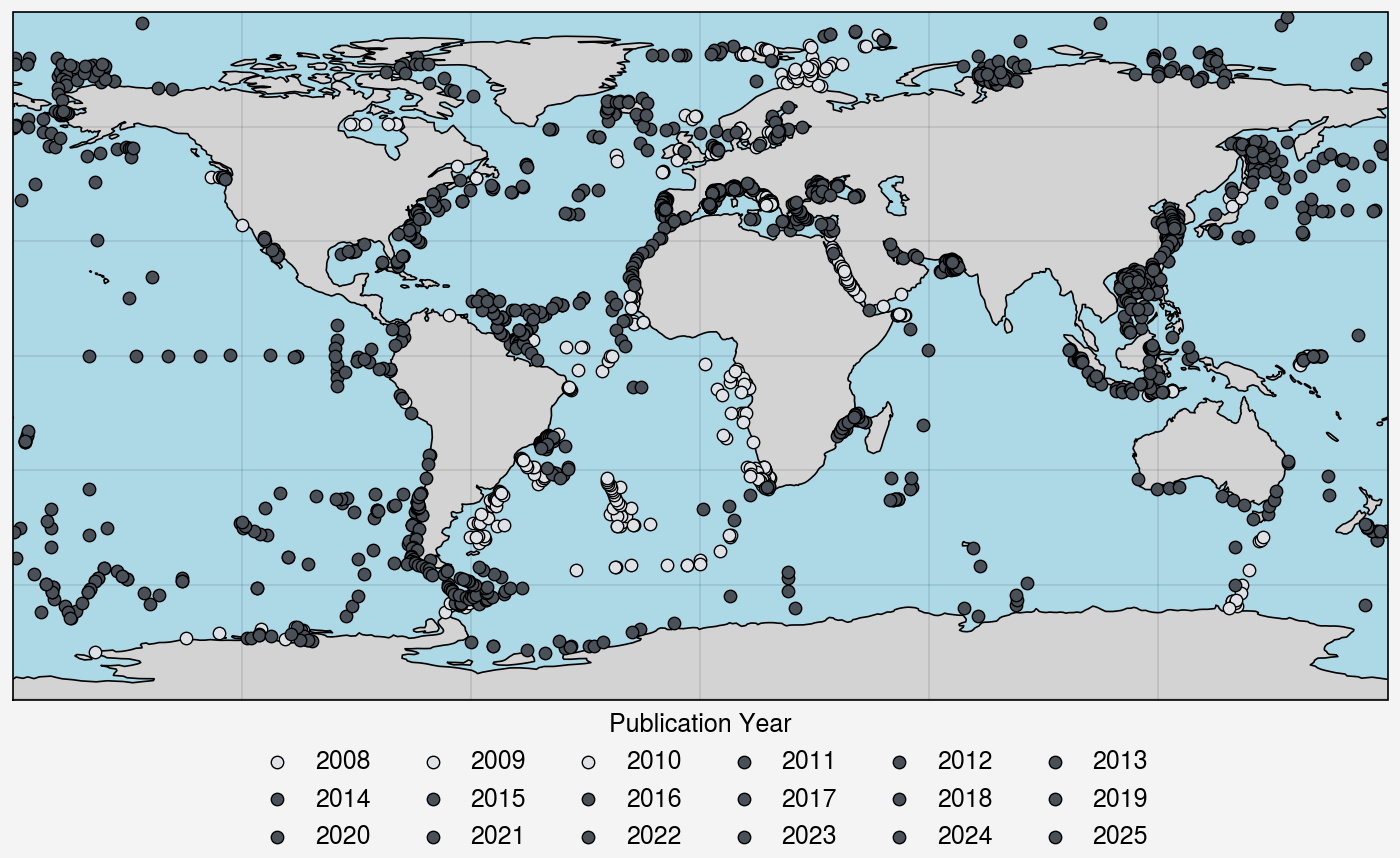

In [11]:
fig, axs = plot.subplots(proj='cyl', width=7)
axs.format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue'
)


grouped = raw_coretop_df.groupby('publicationYear')
for name, group in grouped:
    axs.scatter(group['Longitude'], group['Latitude'], label=int(name), s=20, zorder=2,
                mec='black', mew=0.5,
                c='gray7' if name > 2010 else 'gray3',)
    
axs.legend(loc='b', ncols=6, fontsize=8, frame=False, title='Publication Year')

Linear regression equation: $RI = 3.1517 * TEX86 + 0.5808$
Exponential regression equation: $ln(RI) = 1.4352 * TEX86 + 0.0244$


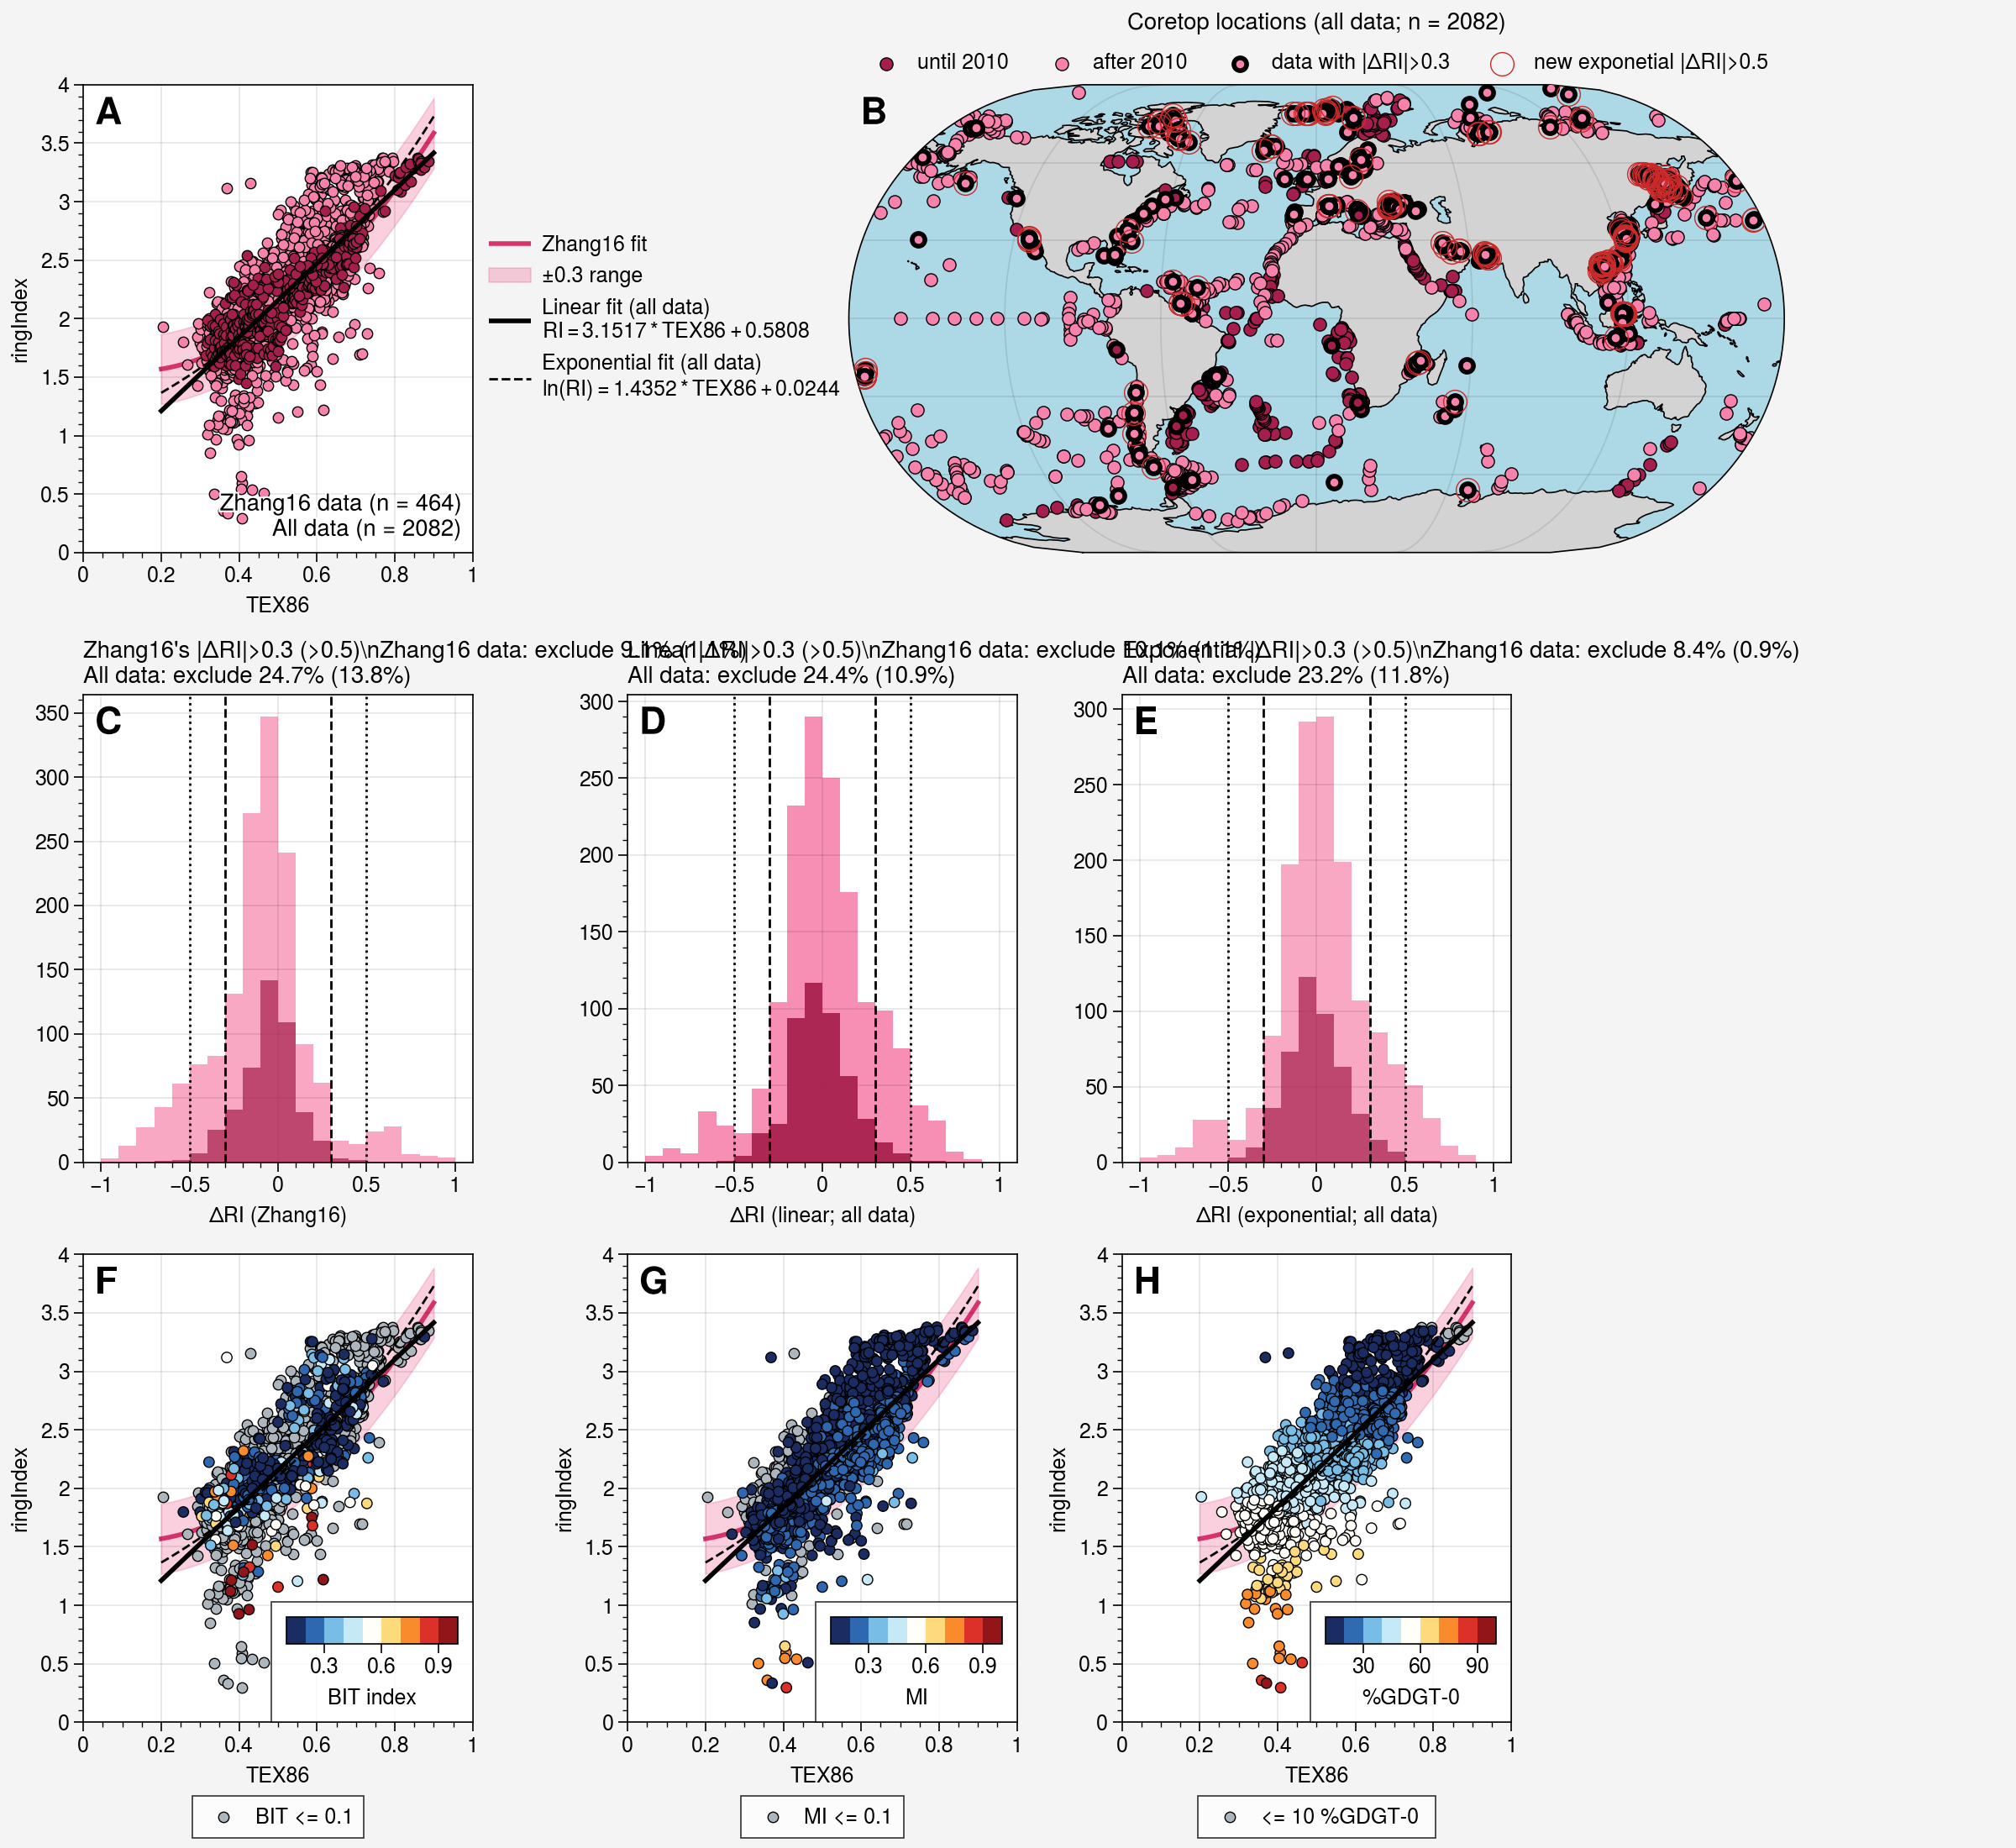

In [12]:
array = [
    [1,2,2,2],
    [3,4,5,0],
    [6,7,8,0],
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),share=0,
                         wspace=5,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)



grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    ax = axs[0]
    ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
               s=20, mec='black', mew=0.5,
               c='pink4' if pubYear > 2010 else 'pink9',
               zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)


xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59

pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
reg_data = raw_coretop_df.dropna(subset=['TEX86', 'ringIndex']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))
axs_idx = [0,5,6,7]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=2, label='Zhang16 fit',zorder=1)
    axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
                   color='pink5', alpha=0.3, label='±0.3 range',
                   zorder=0)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=3,
                lw=2, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, pred_ln_texRI_all,
                color='k', 
                ls='--', lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=2)
    
    axs[idx].format(
    xlim=(0,1),
    ylim=(0, 4),
    )

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Zhang16's |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Linear |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_ln_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_ln_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Exponential |ΔRI|>0.3 (>0.5)\n"
          +f'Zhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.5].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.5'],
    # h,l,
    loc='t', ncols=4, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    [h[i] for i in [0,-1,1,2]],
    [l[i] for i in [0,-1,1,2]],
    # h,l,
    loc='r', ncols=1, frame=False,
)

ax = axs[5]
plot_x = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']<=0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='BIT <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['BIT']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['BIT']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['BIT']>0.1]['BIT']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,

           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='BIT index')
ax.colorbar(m, loc='lr', label='BIT index', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[6]
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']<=0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='MI <= 0.1')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['methaneIndex']>0.1]['methaneIndex']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(0.1, 1.1, 0.1),
           label='MI')
ax.colorbar(m, loc='lr', label='MI', ticks=np.arange(0.1, 1.1, 0.1))

ax = axs[7]
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']<=0.1]['gdgtZeroOverZeroCren']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c='gray5',
           label='<= 10 %GDGT-0 ')
h, l = ax.get_legend_handles_labels()
ax.legend(h[-1],l[-1],loc='b', ncols=1, frame=True)
plot_x = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['TEX86']
plot_y = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['ringIndex']
plot_c = raw_coretop_df[raw_coretop_df['gdgtZeroOverZeroCren']>0.1]['gdgtZeroOverZeroCren']*100
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='coldhot',
           levels=np.arange(10, 101, 10),
           label='%GDGT-0')
ax.colorbar(m, loc='lr', label='%GDGT-0', ticks=np.arange(10, 101, 10))

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

In [13]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Define features
features = ['SST', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2',
            'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime',]

# Replace inf/-inf with NaN, then drop rows with any NaN in selected features
X_clean = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna()
X_array = X_clean.to_numpy(dtype=float)

# Compute mean and covariance matrix
mean_vec = np.mean(X_array, axis=0)
cov_matrix = np.cov(X_array, rowvar=False)
inv_cov_matrix = inv(cov_matrix)

# Calculate Mahalanobis distance
distances = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_array]

# Create mask of valid (non-NaN/inf) rows to assign distances back to original df
valid_idx = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna().index

# Assign distances
raw_coretop_df['mahalanobis_distance'] = np.nan
raw_coretop_df.loc[valid_idx, 'mahalanobis_distance'] = distances
raw_coretop_df['mahalanobis_distance_weights'] = (
    1-((raw_coretop_df['mahalanobis_distance'] - raw_coretop_df['mahalanobis_distance'].min())
    / (raw_coretop_df['mahalanobis_distance'].max() - raw_coretop_df['mahalanobis_distance'].min()))
)   

from scipy.stats import chi2

dof = len(features)  # = 7
confidence = 0.99
threshold = chi2.ppf(confidence, df=dof)
# Square the Mahalanobis distances
squared_distances = np.square(distances)

# Identify which ones exceed the threshold
outlier_flags = squared_distances > threshold
# Assign NaN first
raw_coretop_df['mahalanobis_outlier'] = np.nan

# Assign True/False to valid rows only
raw_coretop_df.loc[valid_idx, 'mahalanobis_outlier'] = outlier_flags

In [14]:
import numpy as np
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv

# Define features
features = ['TEX86','ringIndex']

# Replace inf/-inf with NaN, then drop rows with any NaN in selected features
X_clean = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna()
X_array = X_clean.to_numpy(dtype=float)

# Compute mean and covariance matrix
mean_vec = np.mean(X_array, axis=0)
cov_matrix = np.cov(X_array, rowvar=False)
inv_cov_matrix = inv(cov_matrix)

# Calculate Mahalanobis distance
distances = [mahalanobis(x, mean_vec, inv_cov_matrix) for x in X_array]

# Create mask of valid (non-NaN/inf) rows to assign distances back to original df
valid_idx = raw_coretop_df[features].replace([np.inf, -np.inf], np.nan).dropna().index

# Assign distances
raw_coretop_df['TEX_RI_mahal_dist'] = np.nan
raw_coretop_df.loc[valid_idx, 'TEX_RI_mahal_dist'] = distances
raw_coretop_df['TEX_RI_mahal_dist_weights'] = (
    1-((raw_coretop_df['TEX_RI_mahal_dist'] - raw_coretop_df['TEX_RI_mahal_dist'].min())
    / (raw_coretop_df['TEX_RI_mahal_dist'].max() - raw_coretop_df['TEX_RI_mahal_dist'].min()))
)   

from scipy.stats import chi2

dof = len(features)  # = 7
confidence = 0.99
threshold = chi2.ppf(confidence, df=dof)
# Square the Mahalanobis distances
squared_distances = np.square(distances)

# Identify which ones exceed the threshold
outlier_flags = squared_distances > threshold
# Assign NaN first
raw_coretop_df['TEX_RI_mahal_outlier'] = np.nan

# Assign True/False to valid rows only
raw_coretop_df.loc[valid_idx, 'TEX_RI_mahal_outlier'] = outlier_flags


In [15]:
raw_coretop_df.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'deltaRI_flip',
       'QC_flag_strict', 'pred_new_texRI', 'pred_new_ln_texRI', 'new_deltaRI',
       'new_ln_deltaRI', 'TEX_RI_mahal_dist', 'TEX_RI_mahal_dist_weights',
       'TEX_

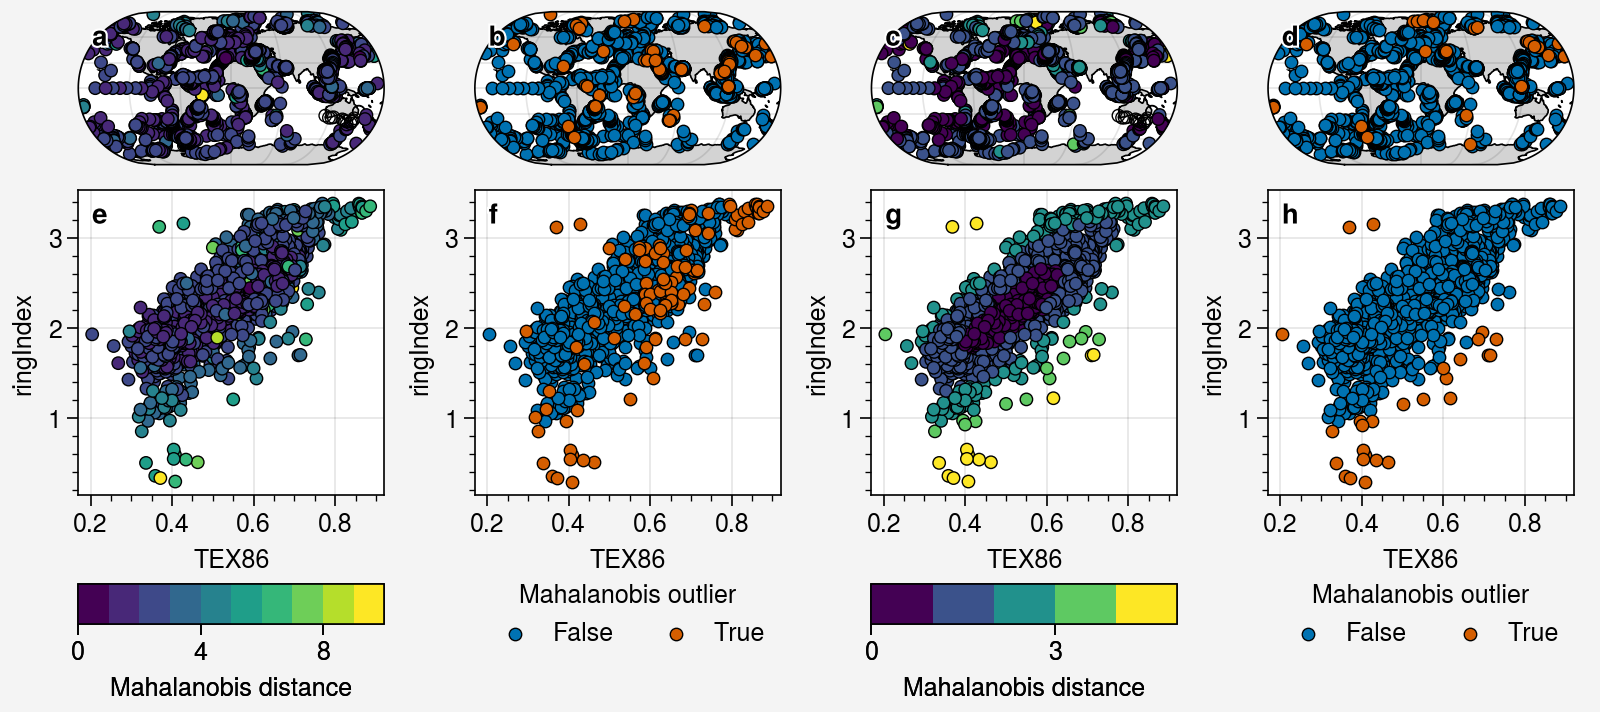

In [16]:
fig, axs = plot.subplots(width=8,ncols=4,nrows=2,
                         proj={1: 'eck3', 2: 'eck3', 3: 'eck3', 4: 'eck3'},
                         hratios=[0.5,1],
                         share=0)
ax = axs[0,0]
axs[0,:].format(
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
)
plot_lat = raw_coretop_df['Latitude']
plot_lon = raw_coretop_df['Longitude']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_lon, plot_lat, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')

ax = axs[1,0]
plot_x = raw_coretop_df['TEX86']
plot_y = raw_coretop_df['ringIndex']
plot_c = raw_coretop_df['mahalanobis_distance']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 11, 1),
           label='Mahalanobis distance')
ax.colorbar(m, loc='b', label='Mahalanobis distance', 
            ticks=np.arange(0, 11, 1))



######################

grouped = raw_coretop_df.groupby('mahalanobis_outlier')
for name, group in grouped:
    axs[0,1].scatter(group['Longitude'], group['Latitude'], label=name,
                   s=20, zorder=2,
                   mec='black', mew=0.5)

    axs[1,1].scatter(group['TEX86'], group['ringIndex'], label=name,
               s=20, zorder=2,
               mec='black', mew=0.5)
    
h, l = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(h, l, loc='b', ncols=2, frame=False, title='Mahalanobis outlier')

######################
ax = axs[0,2]
plot_lat = raw_coretop_df['Latitude']
plot_lon = raw_coretop_df['Longitude']
plot_c = raw_coretop_df['TEX_RI_mahal_dist']
m = ax.scatter(plot_lon, plot_lat, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 6, 1),
           label='Mahalanobis distance')

ax = axs[1,2]
plot_x = raw_coretop_df['TEX86']
plot_y = raw_coretop_df['ringIndex']
plot_c = raw_coretop_df['TEX_RI_mahal_dist']
m = ax.scatter(plot_x, plot_y, s=20, zorder=2,
           mec='black', mew=0.5,
           c=plot_c, cmap='viridis',
           levels=np.arange(0, 6, 1),
           label='Mahalanobis distance')
ax.colorbar(m, loc='b', label='Mahalanobis distance', 
            ticks=np.arange(0, 6, 1))

######################

grouped = raw_coretop_df.groupby('TEX_RI_mahal_outlier')
for name, group in grouped:
    axs[0,3].scatter(group['Longitude'], group['Latitude'], label=name,
                   s=20, zorder=2,
                   mec='black', mew=0.5)

    axs[1,3].scatter(group['TEX86'], group['ringIndex'], label=name,
               s=20, zorder=2,
               mec='black', mew=0.5)
    
h, l = axs[1,3].get_legend_handles_labels()
axs[1,3].legend(h, l, loc='b', ncols=2, frame=False, title='Mahalanobis outlier')
axs.format(
    abcloc='ul'
)

In [17]:
raw_coretop_df['predRI_multiv_g23r'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=raw_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=raw_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']

raw_coretop_df['RIres_multiv_g23r'] = raw_coretop_df['scaledRI'] - raw_coretop_df['predRI_multiv_g23r']
raw_coretop_df

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,QC_flag_strict,pred_new_texRI,pred_new_ln_texRI,new_deltaRI,new_ln_deltaRI,TEX_RI_mahal_dist,TEX_RI_mahal_dist_weights,TEX_RI_mahal_outlier,predRI_multiv_g23r,RIres_multiv_g23r
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0,6.0,31.651700,34.07330,562.0,0.662000,...,include,2.667163,2.649906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0,8.0,-1.532700,-86.78520,2288.0,0.602873,...,include,2.480815,2.434308,-0.139209,-0.092702,0.806920,0.861756,False,0.577169,0.008232
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0,1.0,-3.710500,-81.11530,378.0,0.570000,...,include,2.377211,2.322123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0,1.0,-3.750200,-81.13580,379.0,0.572000,...,include,2.383514,2.328798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0,6.0,-3.969000,-81.31000,1024.0,0.599447,...,include,2.470017,2.422367,0.096508,0.144158,0.701379,0.880683,False,0.603373,0.038258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.600000,-65.40000,267.0,0.400000,...,exclude,1.841430,1.819371,-0.647430,-0.625371,2.479904,0.561736,False,0.455946,-0.157446
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.410000,-64.40000,1054.0,0.322581,...,exclude,1.597431,1.628037,-0.505431,-0.536037,2.384478,0.578849,False,0.439914,-0.166914
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.970000,-59.49000,1012.0,0.375000,...,exclude,1.762639,1.755247,-0.542639,-0.535247,2.241564,0.604478,False,0.455705,-0.150705
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0,3.0,-31.584330,164.44867,2131.0,0.671171,...,include,2.696068,2.685017,-0.205839,-0.194788,1.387600,0.757621,False,0.581090,0.041467


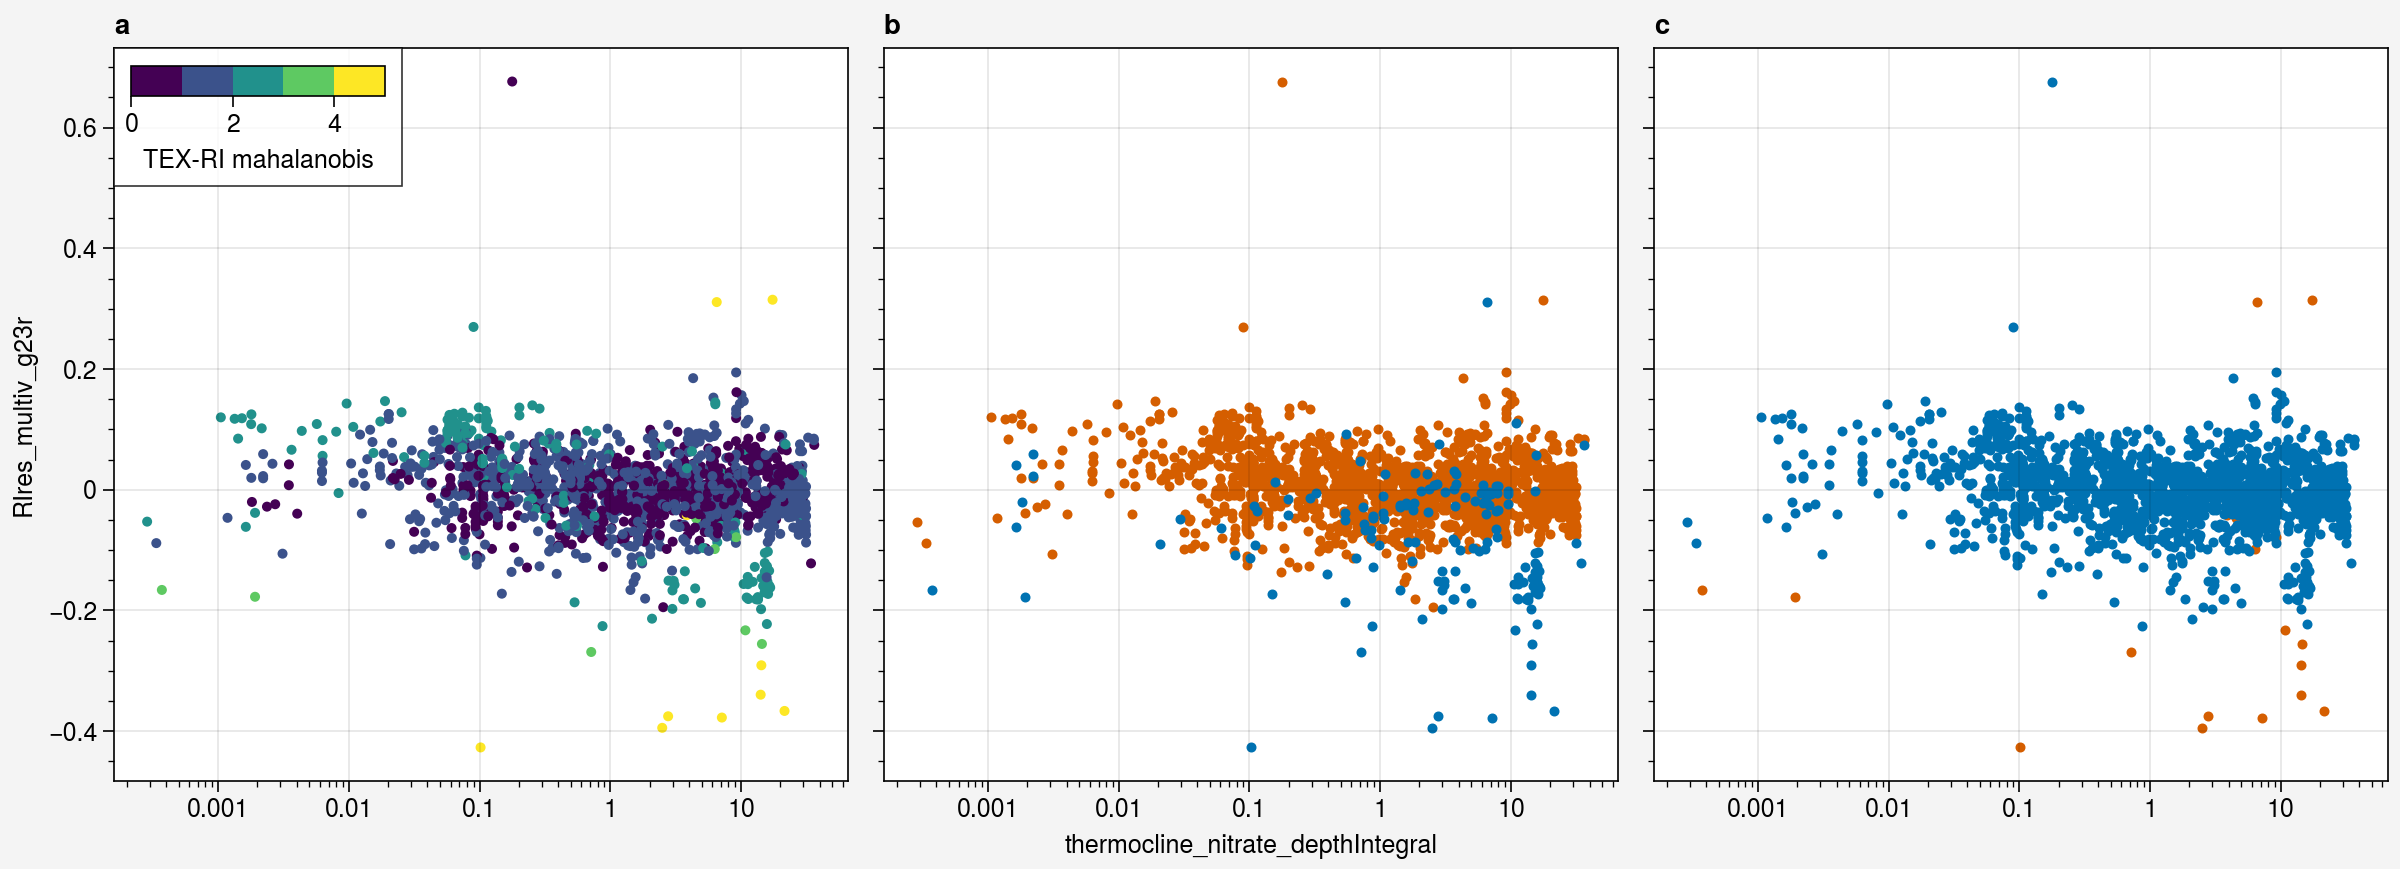

In [18]:
fig, axs = plot.subplots(width=12,ncols=3)

ax = axs[0]
plot_x = raw_coretop_df['thermocline_nitrate_depthIntegral']
plot_y = raw_coretop_df['RIres_multiv_g23r']
plot_c = raw_coretop_df['TEX_RI_mahal_dist']
m = ax.scatter(plot_x,plot_y,m='.',c=plot_c,levels=np.arange(0,6,1),cmap='viridis')
ax.colorbar(m,loc='ul',shrink=10,title='TEX-RI mahalanobis')

ax = axs[1]
grouped = raw_coretop_df.groupby('QC_flag_strict')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    ax.scatter(plot_x,plot_y,m='.',zorder=0 if name=='include' else 1)
    
ax = axs[2]
grouped = raw_coretop_df.groupby('TEX_RI_mahal_outlier')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']
    ax.scatter(plot_x,plot_y,m='.',zorder=0 if name==True else 1)
    
axs.format(xscale='log')

## check weird data

In [19]:
# plot_data.columns

In [20]:
# plot_data = raw_coretop_df[raw_coretop_df['QC_flag']=='include'].copy().reset_index(drop=True)

# sel_post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio')

# plot_data['predRI'] = TEXAS.ensemble.generate_ensemble_auto(
#             post_ds=sel_post_ds,
#             x_vals=plot_data['thermocline_T_depthIntegral'],
#             gdgt23ratio=plot_data['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
#             no3=plot_data['thermocline_nitrate_depthIntegral'], # if 'use_no3' in sel_post_ds.attrs else np.full(len(plot_data),0), 
#             no3_cutoff=1.5,
#             n_draws=500,
#             seed=42
#         )['p50']

# plot_data['RIres'] = plot_data['scaledRI'] - plot_data['predRI']
# plot_data.head()

In [21]:
# features = ['sampleID','reference_name','TEX86','scaledRI','RIres','Latitude','Longitude',
#             'thermocline_T_depthIntegral','thermocline_nitrate_depthIntegral','regionName',
#             'methaneIndex','BIT','gdgtZeroOverZeroCren']
# subset_df = plot_data[features]

# subset_df

# Gridded coretop

In [22]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds_tmp = xr.open_dataset(os.path.join(fpath, fname), engine='h5netcdf')
ocean_properties_ds = xr.merge(
    [ocean_properties_ds_tmp, woas23_sst.rename('sst')],
    compat='override',
    join='override'
)
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
    depth          float32 0.0
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                    (lat: 720, lon: 1440)
Coordinates:
  * lat                        (lat) float32 -89.88 -89.62 ... 89.62 89.88
  * lon                        (lon) float32 -179.9 -179.6 ... 179.6 179.9
Data variables: (12/15)
    region_ID                  (lon, lat) float64 ...
    tex_count                  (lon, lat) float64 ...
    tex_median                 (lon, lat) float64 ...
    tex_mean                   (lon, lat) float64 ...
    tex_std                    (lon, lat) float64 ...
    scaledRI_count             (lon, lat) float64 ...
    ...                         ...
    gdgt23ratio_count          (lon, lat) float64 ...
    gdgt23ratio_median         (lon, lat) float64 ...
    gdgt23ratio_mean           (lon, lat) float64 ...
    gdgt23ratio_std            (lon, lat) float64 ...
    modernWaterDepth_mean      (lon, lat) float64 ...
    mahalanobis_distance_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [23]:
def pred_texRI_fn(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

In [24]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])

coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI_fn(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)
coretop_df

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


In [25]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,depth,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,0.0,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,0.0,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,0.0,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,0.0,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,0.0,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,0.0,-1.48951,1.750199,0.036001
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,0.0,-1.64041,1.654927,0.181673
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,0.0,-1.57180,1.921330,-0.321930
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,0.0,-1.73371,2.100132,-0.367832


In [26]:
culture_data_full.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'fGDGT_0', 'fGDGT_1',
       'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'datatype',
       'methaneIndex', 'gdgtZeroOverZeroCren', 'BIT', 'violin_bins',
       'Strains_edited', 'GTDB_genus_edited'],
      dtype='object')

# PhanSST on TEX-RI relationship

In [27]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanSST_df['pubYear'] = PhanSST_df['LeadAuthor'] + PhanSST_df['Year'].astype(str)

In [28]:
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['pred_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='zhang16')
PhanTEX_df['deltaRI'] = PhanTEX_df['pred_texRI'] - PhanTEX_df['ringIndex']
PhanTEX_df['deltaRI_flip'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_texRI']
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

PhanTEX_df['thermoT_linear'] = (PhanTEX_df['TEX86'] - intercept)/slope
PhanTEX_df['SST_Schouten02'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='schouten02')
PhanTEX_df['SST_Kim10'] = predictSSTfromTEX(PhanTEX_df['TEX86'],method_name='kim2010_tex86H')
PhanTEX_df['pred_new_linear_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='linear_thisStudy')
PhanTEX_df['pred_new_exp_texRI'] = pred_texRI_fn(PhanTEX_df['TEX86'], method_name='exp_thisStudy')
PhanTEX_df['new_linear_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_linear_texRI']
PhanTEX_df['new_exp_deltaRI'] = PhanTEX_df['ringIndex'] - PhanTEX_df['pred_new_exp_texRI']

In [29]:
PhanTEX_df['hothouse_flag'] = [
    1 if PhanTEX_df['Period'][i] in ['Cretaceous'] 
    or PhanTEX_df['Stage'][i] in ['Lutetian', 'Ypresian'] 
    else 0 for i in range(len(PhanTEX_df))
]
PhanTEX_df['hothouse_flag'].unique()

array([1, 0])

Linear regression equation: $RI = 3.1398 * TEX86 + 0.5876$
Weighted linear regression equation: $RI = 3.1008 * TEX86 + 0.6111$
Linear regression equation (mahalanobis < 4): $RI = 3.0884 * TEX86 + 0.6256$
Exponential regression equation: $ln(RI) = 1.4312 * TEX86 + 0.0269$
Weighted exponential regression equation: $ln(RI) = 1.4053 * TEX86 + 0.0445$
Exponential regression equation (mahalanobis < 4): $ln(RI) = 1.3878 * TEX86 + 0.0601$
Log10 regression equation: $log10(RI) = 0.6215 * TEX86 + 0.0117$
Polynomial regression equation: $RI = -11.5641 * TEX86^3 + 0.0000 * TEX86^2 + 2.7901$


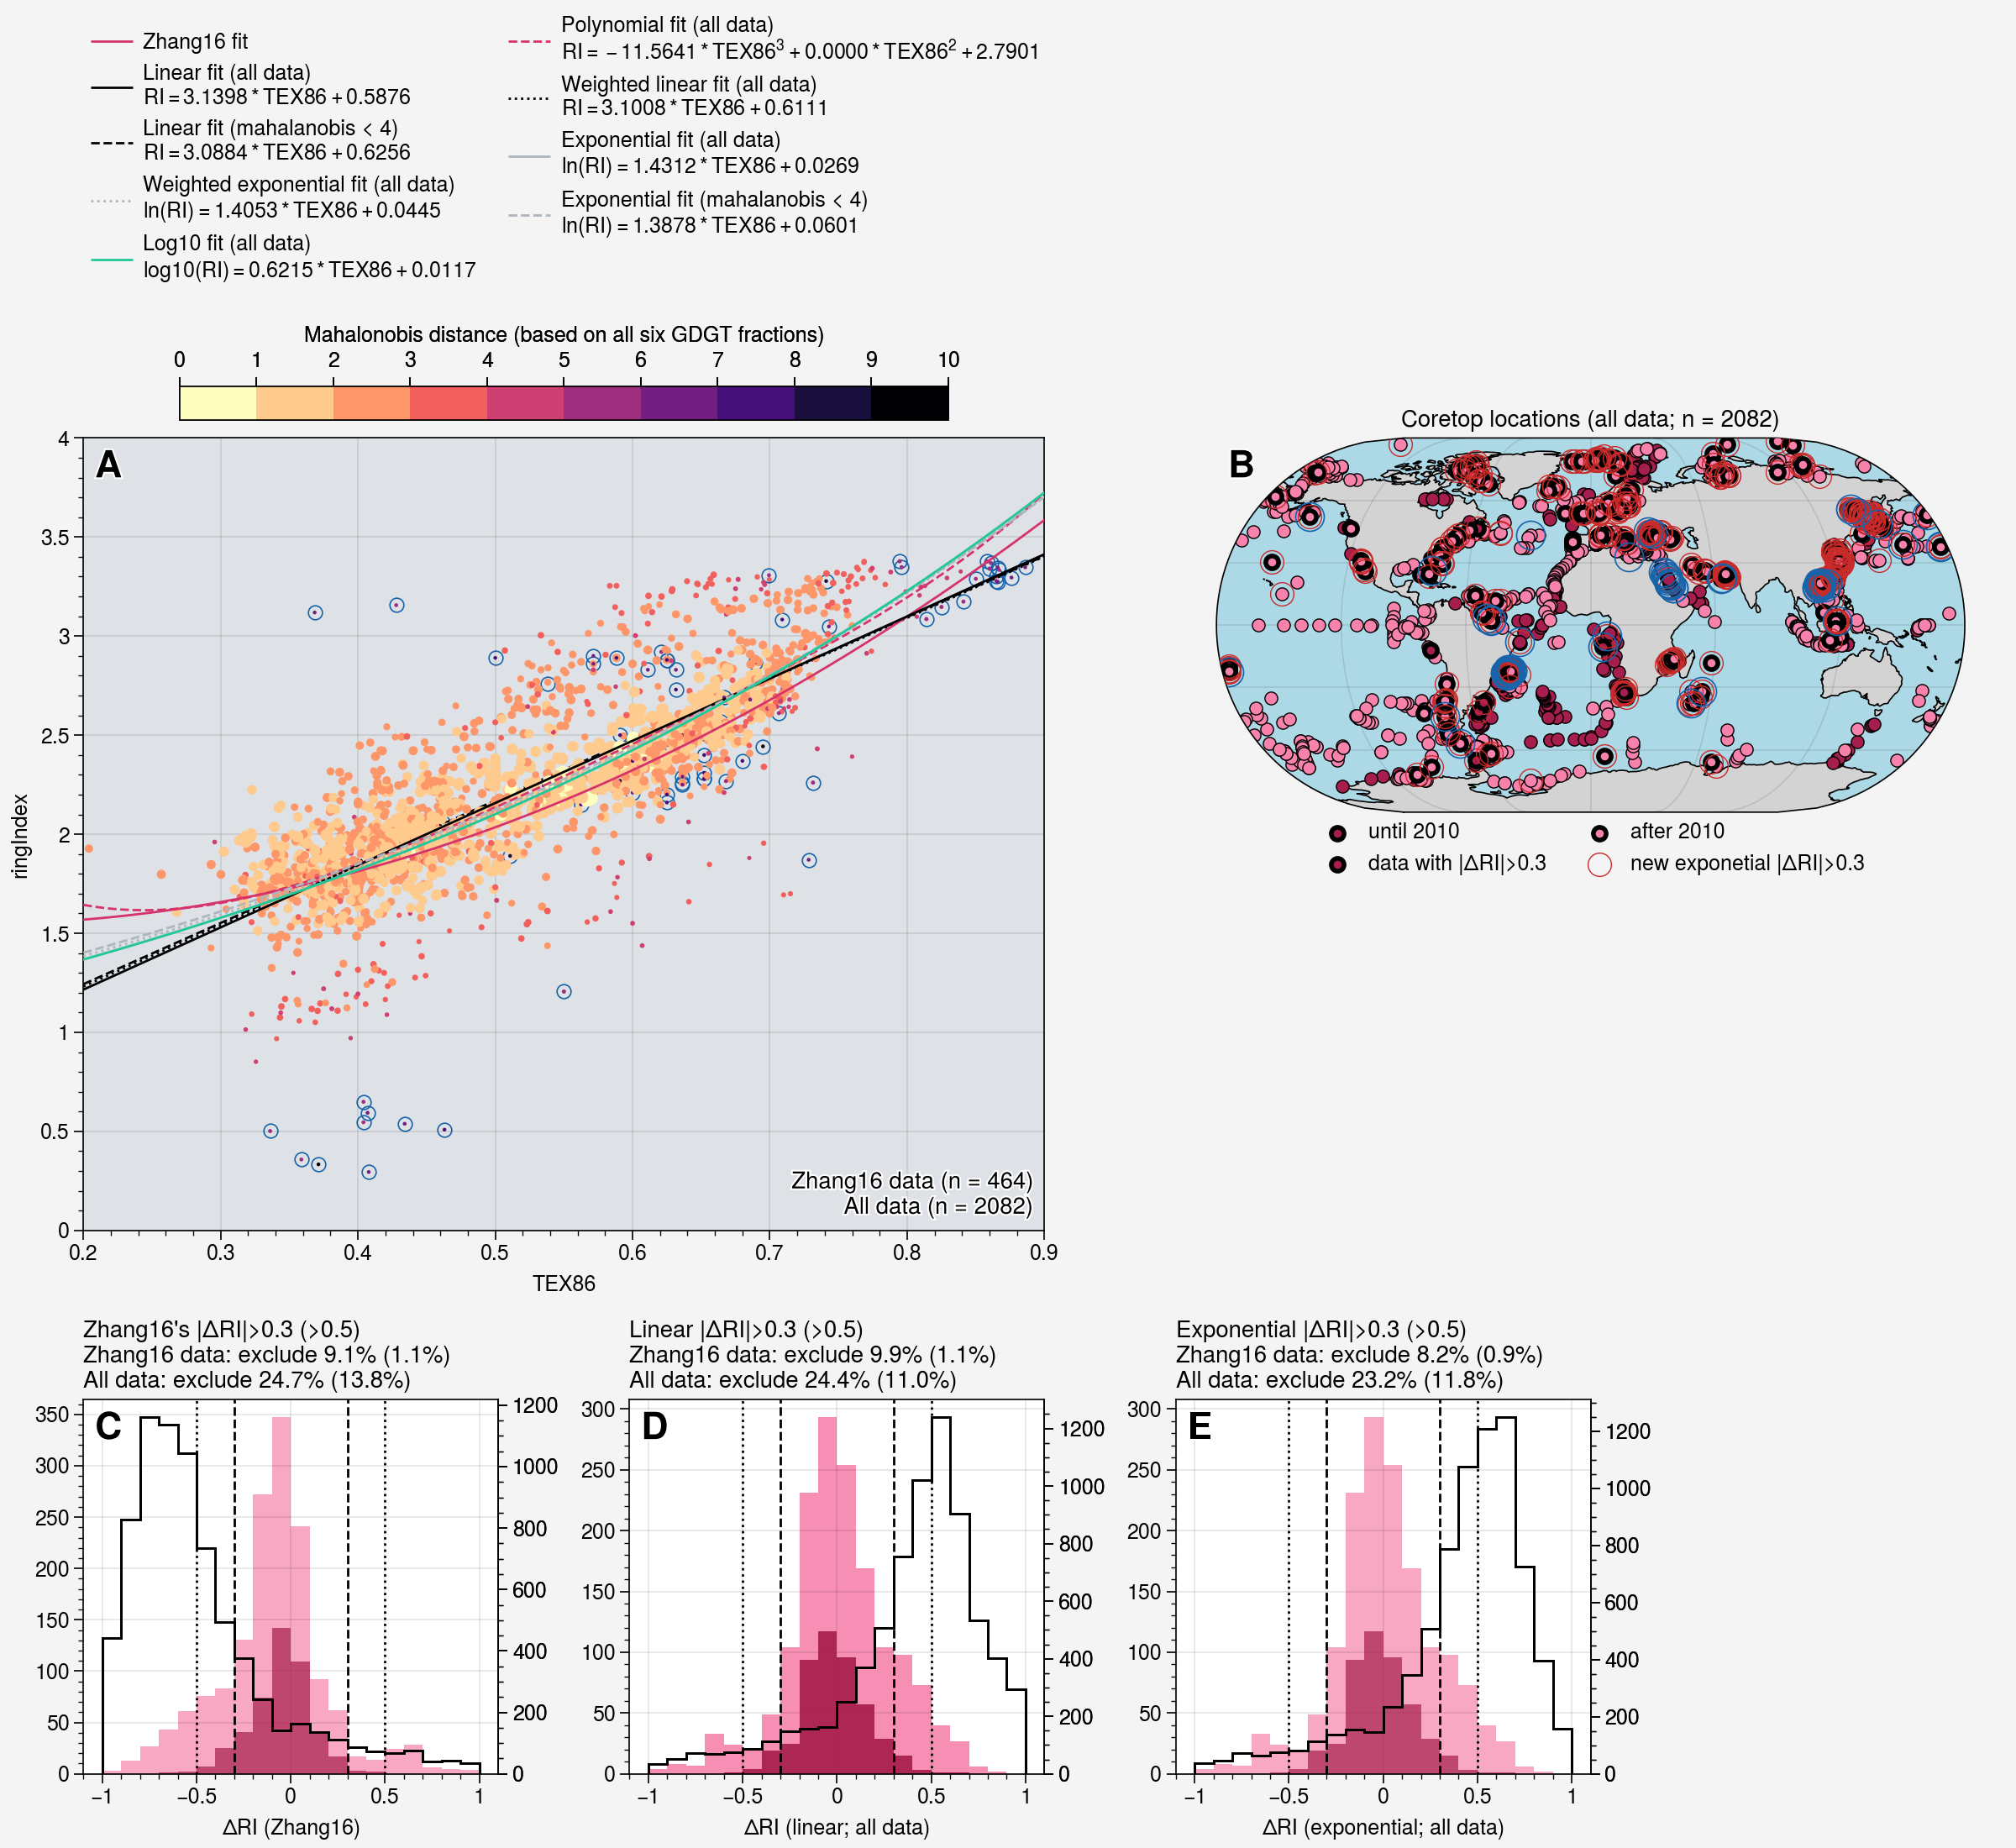

In [30]:
array = [
    [1,1,2,2],
    [1,1,0,0],
    [3,4,5,0]
]
fig, axs = plot.subplots(array,proj=(None,'eck3',None),
                         figsize=(12,11),
                         share=0,
                        #  wspace=8,
                         hratios=(1,1,1),)

ax = axs[1]
ax.format(
    title=f'Coretop locations (all data; n = {len(raw_coretop_df)})',
    land=True,landcolor='lightgray',landzorder=0,
    coast=True,coastcolor='black',coastzorder=1,
    facecolor='lightblue',
)
ax = axs[0]
plot_data = raw_coretop_df
m = ax.scatter(plot_data['TEX86'], plot_data['ringIndex'], label=int(pubYear), 
        # s=10,0
        s=plot_data['mahalanobis_distance_weights']**10, 
        # mec='k', 
        # mew=0.5,
        #    c='pink4' if pubYear > 2010 else 'pink9',
        c=plot_data['mahalanobis_distance'],levels=np.arange(0, 11, 1),
        cmap='magma_r',
        zorder=3)
ax.colorbar(m, loc='t', shrink=0.8, label='Mahalonobis distance (based on all six GDGT fractions)')

_subset_plot = plot_data[plot_data['mahalanobis_distance']>5]
ax.scatter(_subset_plot['TEX86'],_subset_plot['ringIndex'],m='o',facecolor='none',mec='blue9')
axs[1].scatter(_subset_plot['Longitude'],_subset_plot['Latitude'],
               m='o',s=150,facecolor='none',mec='blue9',zorder=10,
               label='Mahal_dist > 5')

grouped = raw_coretop_df.groupby('publicationYear')
for pubYear, group in grouped:

    # ax = axs[0]
    # ax.scatter(group['TEX86'], group['ringIndex'], label=int(pubYear), 
    #         s=10,
    #         #    s=((1/group['mahalanobis_distance'])*10)**2, 
    #         #    mec='black', mew=0.5,
    #         #    c='pink4' if pubYear > 2010 else 'pink9',
    #         c=group['mahalanobis_distance'],
    #         zorder= 2 if pubYear > 2010 else 3,)
    
    ax = axs[1]
    grouped2 = group.groupby('deltaRI_group')
    for deltaRI_group, group2 in grouped2:
        ax.scatter(group2['Longitude'], group2['Latitude'], label=int(pubYear), 
                s=30, 
                mec = 'black', 
                mew = 0.5 if deltaRI_group == '-0.3 to 0.3' else 2,
                zorder = 2 if deltaRI_group == '-0.3 to 0.3' else 3,
                c = 'pink4' if pubYear > 2010 else 'pink9',)

# ### plot PhanTEX data
# paleo_grouped = PhanTEX_df.groupby('hothouse_flag')
# hothouse_flag_dict = {0: 'non-hothouse', 1: 'hothouse'}
# for hothouse_flag, group in paleo_grouped: 
#     ax = axs[0]
#     ax.scatter(group['TEX86'], group['ringIndex'], label=hothouse_flag_dict.get(hothouse_flag), 
#                s=10, 
#             #    mec='black', mew=0.5,
#                c='blue9' if hothouse_flag == 1 else 'blue4',
#                zorder= 1 if hothouse_flag == 1 else 0)

xx = np.linspace(0.2, 0.9, 100)
pred_texRI = -0.77*xx + 3.32*xx**2 + 1.59
pred_texRI_plus03 = pred_texRI + 0.3
pred_texRI_minus03 = pred_texRI - 0.3


### linear fit for all data
lin_reg = LinearRegression()
min_tex_threshold = 0
reg_data = raw_coretop_df[raw_coretop_df['TEX86']>min_tex_threshold].dropna(subset=['TEX86', 'ringIndex','mahalanobis_distance_weights']).reset_index(drop=True)
X = reg_data['TEX86'].values.reshape(-1, 1)
y = reg_data['ringIndex'].values
lin_reg.fit(X, y)
slope = lin_reg.coef_[0]
yintercept = lin_reg.intercept_
equation_text = f'$RI = {slope:.4f} * TEX86 + {yintercept:.4f}$'
print(f'Linear regression equation: {equation_text}')

## weighted linear regression based on mahalanobis distance (higher distance = lower weight)
weights = reg_data['mahalanobis_distance_weights']
lin_reg_weighted = LinearRegression()
lin_reg_weighted.fit(X, y, sample_weight=weights)
slope_weighted = lin_reg_weighted.coef_[0]
yintercept_weighted = lin_reg_weighted.intercept_
equation_text_weighted = f'$RI = {slope_weighted:.4f} * TEX86 + {yintercept_weighted:.4f}$'
print(f'Weighted linear regression equation: {equation_text_weighted}')

### linear fit for only data with mahalanobis distance < 4
lin_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
lin_reg_mahalanobis.fit(X_mahalanobis, y_mahalanobis)
slope_mahalanobis = lin_reg_mahalanobis.coef_[0]
yintercept_mahalanobis = lin_reg_mahalanobis.intercept_
equation_text_mahalanobis = f'$RI = {slope_mahalanobis:.4f} * TEX86 + {yintercept_mahalanobis:.4f}$'
print(f'Linear regression equation (mahalanobis < 4): {equation_text_mahalanobis}')

### exponential fit for all data
ln_y = np.log(y)
exp_reg = LinearRegression()
exp_reg.fit(X, ln_y)
exp_slope = exp_reg.coef_[0]
exp_yintercept = exp_reg.intercept_
exp_equation_text = f'$ln(RI) = {exp_slope:.4f} * TEX86 + {exp_yintercept:.4f}$'
print(f'Exponential regression equation: {exp_equation_text}')

sigma = np.std(y - lin_reg.predict(X))
pred_texRI_all = lin_reg.predict(xx.reshape(-1, 1))
pred_ln_texRI_all = np.exp(exp_reg.predict(xx.reshape(-1, 1)))

### weighted exponential fit based on mahalanobis distance (higher distance = lower weight)
weights_exp = reg_data['mahalanobis_distance_weights']
exp_reg_weighted = LinearRegression()
exp_reg_weighted.fit(X, ln_y, sample_weight=weights_exp)
exp_slope_weighted = exp_reg_weighted.coef_[0]
exp_yintercept_weighted = exp_reg_weighted.intercept_
exp_equation_text_weighted = f'$ln(RI) = {exp_slope_weighted:.4f} * TEX86 + {exp_yintercept_weighted:.4f}$'
print(f'Weighted exponential regression equation: {exp_equation_text_weighted}')

### exp fit for only data with mahalanobis distance < 4
exp_reg_mahalanobis = LinearRegression()
reg_data_mahalanobis = reg_data[reg_data['mahalanobis_distance'] < 4].reset_index(drop=True)
X_mahalanobis = reg_data_mahalanobis['TEX86'].values.reshape(-1, 1)
y_mahalanobis = reg_data_mahalanobis['ringIndex'].values
exp_reg_mahalanobis.fit(X_mahalanobis, np.log(y_mahalanobis))
exp_slope_mahalanobis = exp_reg_mahalanobis.coef_[0]
exp_yintercept_mahalanobis = exp_reg_mahalanobis.intercept_
exp_equation_text_mahalanobis = f'$ln(RI) = {exp_slope_mahalanobis:.4f} * TEX86 + {exp_yintercept_mahalanobis:.4f}$'
print(f'Exponential regression equation (mahalanobis < 4): {exp_equation_text_mahalanobis}')

### np.log10 fit for all data
log10_y = np.log10(y)
log10_reg = LinearRegression()
log10_reg.fit(X, log10_y)
log10_slope = log10_reg.coef_[0]
log10_yintercept = log10_reg.intercept_
log10_equation_text = f'$log10(RI) = {log10_slope:.4f} * TEX86 + {log10_yintercept:.4f}$'
print(f'Log10 regression equation: {log10_equation_text}')

## weighted 3-degree polynomial fit based on mahalanobis distance (higher distance = lower weight)
from sklearn.preprocessing import PolynomialFeatures  # noqa: E402
poly_features = PolynomialFeatures(degree=4)
X_poly = poly_features.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y, sample_weight=weights)
poly_slope = poly_reg.coef_[1]
poly_yintercept = poly_reg.intercept_
poly_equation_text = f'$RI = {poly_slope:.4f} * TEX86^3 + {poly_reg.coef_[0]:.4f} * TEX86^2 + {poly_yintercept:.4f}$'
print(f'Polynomial regression equation: {poly_equation_text}')
axs_idx = [0]
for idx in axs_idx:
    axs[idx].plot(xx, pred_texRI, color='pink7', lw=1, label='Zhang16 fit',zorder=4)
    # axs[idx].fill_between(xx, pred_texRI_plus03, pred_texRI_minus03,
    #                color='pink5', alpha=0.3, label='±0.3 range',
    #                zorder=0)
    
    axs[idx].plot(xx, poly_reg.predict(poly_features.transform(xx.reshape(-1, 1))),
                color='pink7', 
                ls='--', lw=1, label='Polynomial fit (all data)\n'+poly_equation_text,
                zorder=4)
    
    axs[idx].plot(xx, pred_texRI_all, 
                color='k', 
                zorder=5,
                lw=1, label='Linear fit (all data)\n'+equation_text)
    
    axs[idx].plot(xx, lin_reg_weighted.predict(xx.reshape(-1, 1)),
                color='k', 
                ls=':', lw=1, label='Weighted linear fit (all data)\n'+equation_text_weighted)
    
    
    axs[idx].plot(xx, lin_reg_mahalanobis.predict(xx.reshape(-1, 1)),
                color='k', 
                ls='--', lw=1, label='Linear fit (mahalanobis < 4)\n'+equation_text_mahalanobis)

    axs[idx].plot(xx, pred_ln_texRI_all,
                color='gray5', 
                lw=1, label='Exponential fit (all data)\n'+exp_equation_text,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_weighted.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls=':', lw=1, label='Weighted exponential fit (all data)\n'+exp_equation_text_weighted,
                zorder=6)
    
    axs[idx].plot(xx, np.exp(exp_reg_mahalanobis.predict(xx.reshape(-1, 1))),
                color='gray5', 
                ls='--', lw=1, label='Exponential fit (mahalanobis < 4)\n'+exp_equation_text_mahalanobis,
                zorder=7)
    axs[idx].plot(xx, np.power(10, log10_reg.predict(xx.reshape(-1, 1))),
                color='teal5',
                lw=1, label='Log10 fit (all data)\n'+log10_equation_text,
                zorder=8)
    
    

raw_coretop_df['pred_new_texRI'] = lin_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1))
raw_coretop_df['pred_new_ln_texRI'] = np.exp(exp_reg.predict(raw_coretop_df['TEX86'].values.reshape(-1, 1)))

raw_coretop_df['new_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df['new_ln_deltaRI'] = raw_coretop_df['ringIndex'] - raw_coretop_df['pred_new_ln_texRI']

coretop_until2010 = raw_coretop_df[raw_coretop_df['publicationYear']<=2010].reset_index(drop=True)
coretop_after2010 = raw_coretop_df[raw_coretop_df['publicationYear']>2010].reset_index(drop=True)
axs[0].format(
    lrtitle=f'Zhang16 data (n = {len(coretop_until2010)})\nAll data (n = {len(raw_coretop_df)})',
)

ax = axs[2]
data1 = coretop_until2010['deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)


ax.twinx().hist(PhanTEX_df['deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (Zhang16)',
        zorder=3)

ax.format(
    xlabel='ΔRI (Zhang16)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010 = coretop_until2010[np.abs(coretop_until2010['deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all = raw_coretop_df[np.abs(raw_coretop_df['deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Zhang16's |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)
ax.twinx().hist(PhanTEX_df['new_linear_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (linear)',
        zorder=3)

ax.format(
    xlabel='ΔRI (linear; all data)',
)
### calculate how much data outside of ±0.3
inside_abs03_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_linear = coretop_until2010[np.abs(coretop_until2010['new_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_linear = raw_coretop_df[np.abs(raw_coretop_df['new_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Linear |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010_linear)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_linear)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_linear)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_linear)/len(raw_coretop_df)*100):.1f}%)'),)

ax = axs[4]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.twinx().hist(PhanTEX_df['new_exp_deltaRI'],
        bins=np.arange(-1, 1.1, 0.1),
        histtype='step',
        color='k', lw=1, label='PhanTEX (exponential)',
        zorder=3)

ax.format(
    xlabel='ΔRI (exponential; all data)',
)
#### calculate how much data outside of ±0.3
inside_abs03_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_until2010_ln = coretop_until2010[np.abs(coretop_until2010['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
inside_abs03_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.3].reset_index(drop=True)
inside_abs05_all_ln = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])<=0.5].reset_index(drop=True)
ax.axvline(0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(-0.3, color='k', ls='--', lw=1, zorder=3)
ax.axvline(0.5, color='k', ls=':', lw=1, zorder=3)
ax.axvline(-0.5, color='k', ls=':', lw=1, zorder=3)
ax.format(ltitle=(r"Exponential |ΔRI|>0.3 (>0.5)"
          +f'\nZhang16 data: exclude {(100-len(inside_abs03_until2010_ln)/len(coretop_until2010)*100):.1f}% ({(100-len(inside_abs05_until2010_ln)/len(coretop_until2010)*100):.1f}%)\n'
          +f'All data: exclude {(100-len(inside_abs03_all_ln)/len(raw_coretop_df)*100):.1f}% ({(100-len(inside_abs05_all_ln)/len(raw_coretop_df)*100):.1f}%)'),)


ax = axs[3]
data1 = coretop_until2010['new_deltaRI'].dropna().to_numpy()
data2 = coretop_after2010['new_deltaRI'].dropna().to_numpy()

bins = np.arange(-1, 1.1, 0.1)

ax.hist(
    data1,
    bins=bins,
    histtype='stepfilled',
    color='pink9',
    lw=2,
    label='until 2010',
    zorder=2,
    alpha=0.7
)

ax.hist(
    data2,
    bins=bins,
    histtype='stepfilled',
    color='pink4',
    lw=2,
    label='after 2010',
    zorder=1,
    alpha=0.7
)

ax.format(
    xlabel='ΔRI (linear; all data)',
)



plot_data = raw_coretop_df[np.abs(raw_coretop_df['new_ln_deltaRI'])>0.3].reset_index(drop=True)
axs[1].scatter(
    plot_data['Longitude'], plot_data['Latitude'],
    zorder=4,
    s=100, mec='red9', mew=0.5, facecolor='none',
)

h, l = axs[1].get_legend_handles_labels()
axs[1].legend(
    [h[i] for i in [1,10,9,-1]], 
    ['until 2010', 'after 2010', 'data with |ΔRI|>0.3','new exponetial |ΔRI|>0.3'],
    # h,l,
    loc='b', ncols=2, frame=False,
)

h, l = axs[0].get_legend_handles_labels()
axs[0].legend(
    # [h[i] for i in [0,-1,1,2]],
    # [l[i] for i in [0,-1,1,2]],
    h[:-2],l[:-2],
    loc='t', ncols=2, frame=False,
    bbox_to_anchor=(0.5, 1),
)

axs[0].format(facecolor='gray3',
    xlim=(0.2,0.9),
    ylim=(0,4),
    aspect='auto'
)

axs.format(
    abc=True,abcstyle='A',abcloc='ul',
    abcsize=16,abcweight='bold',
)

# Input Data for stan models

In [31]:
culture_data_full.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'fGDGT_0', 'fGDGT_1',
       'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'datatype',
       'methaneIndex', 'gdgtZeroOverZeroCren', 'BIT', 'violin_bins',
       'Strains_edited', 'GTDB_genus_edited'],
      dtype='object')

In [32]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()



In [33]:
## Combined coretop and culture/mesocosm to a single dataframe
sel_cul_data = culture_data_full.reset_index(drop=True)

combined_df = pd.DataFrame({
    't_sf2tc': pd.concat([coretop_df['t_sf2tc_avg'], 
                          sel_cul_data['Temperature'], 
                          meso_data_full['Temperature']]),
    'SST' : pd.concat([coretop_df['sst'], 
                        sel_cul_data['Temperature'], 
                        meso_data_full['Temperature']]),
    'scaledRI': pd.concat([coretop_df['scaledRI_median'], 
                           sel_cul_data['scaledRI'], 
                           meso_data_full['scaledRI']]),
    'TEX86': pd.concat([coretop_df['tex_median'], 
                           sel_cul_data['TEX86'], 
                           meso_data_full['TEX86']]),
    'gdgt23ratio': pd.concat([coretop_df['gdgt23ratio_median'], 
                              sel_cul_data['gdgt23ratio'], 
                              meso_data_full['gdgt23ratio']]),
    'no3_sf2tc': pd.concat([coretop_df['no3_sf2tc_avg'],
                            pd.Series(np.ones(len(sel_cul_data))*50),
                            pd.Series(np.ones(len(meso_data_full))*50)]),
    'datatype': pd.concat(
        [pd.Series(['coretop'] * len(coretop_df)),
         pd.Series(['culture'] * len(sel_cul_data)),
         pd.Series(['mesocosm'] * len(meso_data_full)),]
    )
})

# Add GDGT features
features = ['fGDGT_0', 'fGDGT_1','fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']

# Create NaN values for coretop data (assuming these features don't exist in coretop_df)
coretop_gdgt_features = pd.DataFrame(np.full((len(coretop_df), len(features)), np.nan), 
                                     columns=features)

# Combine GDGT features from all datasets
gdgt_combined = pd.concat([coretop_gdgt_features,
                          culture_data_full[features],
                          meso_data_full[features]], 
                         axis=0)

# Add GDGT features to the combined dataframe
for feature in features:
    combined_df[feature] = gdgt_combined[feature]

# Reset index to ensure clean indexing
combined_df = combined_df.reset_index(drop=True)

# Save to CSV
fpath = f'{local_github_path}/spreadsheets'
fname = 'combined_df_culmesocore_griddedRI.csv'
combined_df.to_csv(os.path.join(fpath, fname), index=False)

In [34]:
gdgt_combined

,fGDGT_0,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
16,0.230496,0.073897,0.035219,0.013396,0.635200,0.011792
17,0.272515,0.051583,0.055801,0.015702,0.564495,0.039904
18,0.125782,0.049939,0.045612,0.019677,0.747221,0.011769
19,0.049583,0.023916,0.054250,0.022633,0.822493,0.027125


# Simple curve-fitting comparison

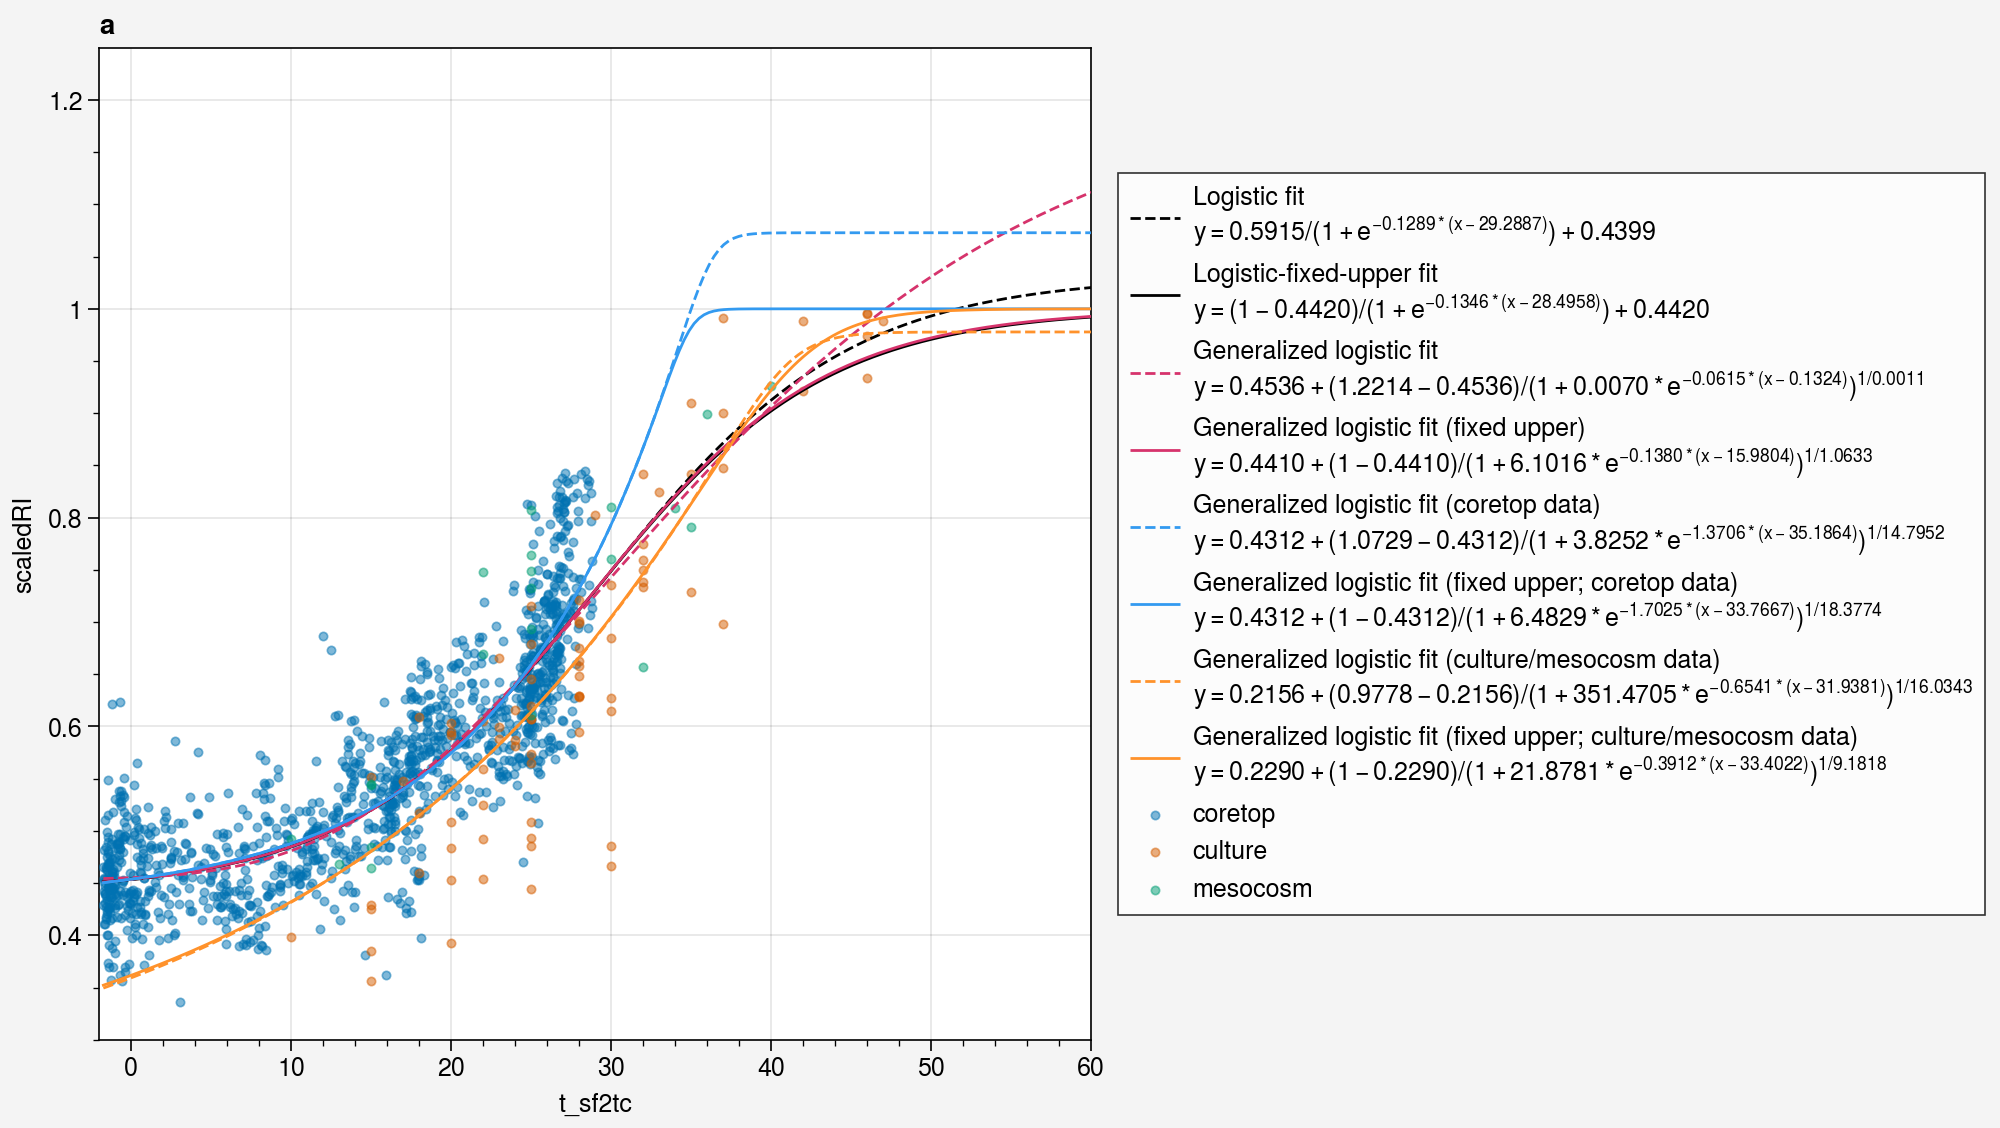

In [35]:
fig, axs = plot.subplots(width=10)

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax = axs[0]
    ax.scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
               m='.',alpha=0.5,zorder=3)

nonnan_idx = combined_df['t_sf2tc'].notna() & combined_df['scaledRI'].notna()
sel_X = combined_df['t_sf2tc'][nonnan_idx].values
sel_Y = combined_df['scaledRI'][nonnan_idx].values
XX = np.linspace(sel_X.min(), 60, 200)

### use logistic function for curve fitting
popt, pcov = curve_fit(
    logistic,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf]))
fitted_x0 = popt[0]
fitted_k = popt[1]
fitted_L = popt[2]
fitted_b = popt[3]
axs[0].plot(XX, logistic(XX, *popt), 
            color='k', lw=1, ls='--',
            label=f'Logistic fit\n$y = {fitted_L:.4f} / (1 + e^{{-{fitted_k:.4f} * (x - {fitted_x0:.4f})}}) + {fitted_b:.4f}$',
            zorder=4)

## define inflection point with differential
def plot_inflection_point(ax, x_vals, y_vals,sel_color='k',sel_linestyle='--'):
    """Plot the inflection point on the given axis."""
    # Compute numerical first and second derivatives
    dy_dx = np.gradient(y_vals, x_vals)
    d2y_dx2 = np.gradient(dy_dx, x_vals)

    # Find zero crossing in second derivative
    sign_change = np.where(np.diff(np.sign(d2y_dx2)))[0]
    
    # Get estimated inflection x value
    if sign_change.size > 0:
        inflection_idx = sign_change[0]
        inflection_x = x_vals[inflection_idx]
        ax.axvline(inflection_x, color=sel_color, ls=sel_linestyle, lw=1,)
        return inflection_x
    else:
        print("No inflection point found")
        return None

# inflection_x = plot_inflection_point(axs[0], XX, logistic(XX, *popt),
#                                     sel_color='pink7', sel_linestyle=':')

### use logistic_fixed_upper function for curve fitting
popt_fixed, pcov_fixed = curve_fit(
    logistic_fixed_upper,
    sel_X,sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf]))
fitted_x0_fixed = popt_fixed[0]
fitted_k_fixed = popt_fixed[1]
fitted_b_fixed = popt_fixed[2]
axs[0].plot(XX, logistic_fixed_upper(XX, *popt_fixed), 
            color='k', lw=1, 
            label=f'Logistic-fixed-upper fit\n$y = (1-{fitted_b_fixed:.4f}) / (1 + e^{{-{fitted_k_fixed:.4f} * (x - {fitted_x0_fixed:.4f})}}) + {fitted_b_fixed:.4f}$',
            zorder=4)

# inflection_x_fixed = plot_inflection_point(axs[0], XX, logistic_fixed_upper(XX, *popt_fixed),
#                                              sel_color='k', sel_linestyle=':')



### use the generalized logistic function for curve fitting
popt_gen, pcov_gen = curve_fit(
    generalized_logistic_model,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen = popt_gen[0]
fitted_a_gen = popt_gen[1]
fitted_b_gen = popt_gen[2]
fitted_k_gen = popt_gen[3]
fitted_v_gen = popt_gen[4]
fitted_Q_gen = popt_gen[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen), 
            color='pink7', lw=1, ls='--',
            label=f'Generalized logistic fit\n$y = {fitted_b_gen:.4f} + ({fitted_a_gen:.4f} - {fitted_b_gen:.4f}) / (1 + {fitted_Q_gen:.4f} * e^{{-{fitted_k_gen:.4f} * (x - {fitted_x0_gen:.4f})}})^{{1/{fitted_v_gen:.4f}}}$',
            zorder=4)

# inflection_x_gen = plot_inflection_point(axs[0], XX, generalized_logistic_model(XX, *popt_gen),
#                                          sel_color='gray5', sel_linestyle=':')

### use the generalized logistic function with fixed upper limit for curve fitting by setting K = 1

popt_gen_fixed, pcov_gen_fixed = curve_fit(
    generalized_logistic_model_fixed_upper,
    sel_X, sel_Y,
    bounds=(0, [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed = popt_gen_fixed[0]
fitted_b_gen_fixed = popt_gen_fixed[1]
fitted_k_gen_fixed = popt_gen_fixed[2]
fitted_v_gen_fixed = popt_gen_fixed[3]
fitted_Q_gen_fixed = popt_gen_fixed[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed), 
            color='pink7', lw=1, 
            label=f'Generalized logistic fit (fixed upper)\n$y = {fitted_b_gen_fixed:.4f} + (1 - {fitted_b_gen_fixed:.4f}) / (1 + {fitted_Q_gen_fixed:.4f} * e^{{-{fitted_k_gen_fixed:.4f} * (x - {fitted_x0_gen_fixed:.4f})}})^{{1/{fitted_v_gen_fixed:.4f}}}$',
            zorder=4)

# inflection_x_gen_fixed = plot_inflection_point(axs[0], XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed),
#                                                sel_color='teal5', sel_linestyle=':')

#### fit data with coretop data only

coretop_data = combined_df[combined_df['datatype'] == 'coretop']
coretop_X = coretop_data['t_sf2tc']
coretop_Y = coretop_data['scaledRI']
coretop_nonnan_idx = coretop_X.notna() & coretop_Y.notna()
coretop_sel_X = coretop_X[coretop_nonnan_idx].values
coretop_sel_Y = coretop_Y[coretop_nonnan_idx].values   

### fit with generalized logistic function
popt_gen_coretop, pcov_gen_coretop = curve_fit(
    generalized_logistic_model,
    coretop_sel_X, coretop_sel_Y,
    bounds=([10, 0, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_coretop = popt_gen_coretop[0]
fitted_a_gen_coretop = popt_gen_coretop[1]
fitted_b_gen_coretop = popt_gen_coretop[2]
fitted_k_gen_coretop = popt_gen_coretop[3]
fitted_v_gen_coretop = popt_gen_coretop[4]
fitted_Q_gen_coretop = popt_gen_coretop[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen_coretop), 
            color='blue5', lw=1, ls='--',
            label=f'Generalized logistic fit (coretop data)\n$y = {fitted_b_gen_coretop:.4f} + ({fitted_a_gen_coretop:.4f} - {fitted_b_gen_coretop:.4f}) / (1 + {fitted_Q_gen_coretop:.4f} * e^{{-{fitted_k_gen_coretop:.4f} * (x - {fitted_x0_gen_coretop:.4f})}})^{{1/{fitted_v_gen_coretop:.4f}}}$',
            zorder=4)
# inflection_x_gen_coretop = plot_inflection_point(axs[0], XX, generalized_logistic_model(XX, *popt_gen_coretop),
#                                                  sel_color='blue5', sel_linestyle=':')

### fit with generalized logistic function with fixed upper limit 
popt_gen_fixed_coretop, pcov_gen_fixed_coretop = curve_fit(
    generalized_logistic_model_fixed_upper,
    coretop_sel_X, coretop_sel_Y,
    bounds=([10, 0, 0, 0, 0,], 
            [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed_coretop = popt_gen_fixed_coretop[0]
fitted_b_gen_fixed_coretop = popt_gen_fixed_coretop[1]
fitted_k_gen_fixed_coretop = popt_gen_fixed_coretop[2]
fitted_v_gen_fixed_coretop = popt_gen_fixed_coretop[3]
fitted_Q_gen_fixed_coretop = popt_gen_fixed_coretop[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_coretop), 
            color='blue5', lw=1, 
            label=f'Generalized logistic fit (fixed upper; coretop data)\n$y = {fitted_b_gen_fixed_coretop:.4f} + (1 - {fitted_b_gen_fixed_coretop:.4f}) / (1 + {fitted_Q_gen_fixed_coretop:.4f} * e^{{-{fitted_k_gen_fixed_coretop:.4f} * (x - {fitted_x0_gen_fixed_coretop:.4f})}})^{{1/{fitted_v_gen_fixed_coretop:.4f}}}$',
            zorder=4)
# inflection_x_gen_fixed_coretop = plot_inflection_point(axs[0], XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_coretop),
#                                                      sel_color='blue5', sel_linestyle=':')

## fit culture and mesocosm data only
culture_mesocosm_data = combined_df[combined_df['datatype'].isin(['culture', 'mesocosm'])]
culture_mesocosm_X = culture_mesocosm_data['t_sf2tc']
culture_mesocosm_Y = culture_mesocosm_data['scaledRI']
culture_mesocosm_nonnan_idx = culture_mesocosm_X.notna() & culture_mesocosm_Y.notna()
culture_mesocosm_sel_X = culture_mesocosm_X[culture_mesocosm_nonnan_idx].values
culture_mesocosm_sel_Y = culture_mesocosm_Y[culture_mesocosm_nonnan_idx].values

### fit with generalized logistic function
popt_gen_culture_mesocosm, pcov_gen_culture_mesocosm = curve_fit(
    generalized_logistic_model,
    culture_mesocosm_sel_X, culture_mesocosm_sel_Y,
    bounds=([10, 0, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_culture_mesocosm = popt_gen_culture_mesocosm[0]
fitted_a_gen_culture_mesocosm = popt_gen_culture_mesocosm[1]
fitted_b_gen_culture_mesocosm = popt_gen_culture_mesocosm[2]
fitted_k_gen_culture_mesocosm = popt_gen_culture_mesocosm[3]
fitted_v_gen_culture_mesocosm = popt_gen_culture_mesocosm[4]
fitted_Q_gen_culture_mesocosm = popt_gen_culture_mesocosm[5]
axs[0].plot(XX, generalized_logistic_model(XX, *popt_gen_culture_mesocosm), 
            color='orange5', lw=1, ls='--',
            label=f'Generalized logistic fit (culture/mesocosm data)\n$y = {fitted_b_gen_culture_mesocosm:.4f} + ({fitted_a_gen_culture_mesocosm:.4f} - {fitted_b_gen_culture_mesocosm:.4f}) / (1 + {fitted_Q_gen_culture_mesocosm:.4f} * e^{{-{fitted_k_gen_culture_mesocosm:.4f} * (x - {fitted_x0_gen_culture_mesocosm:.4f})}})^{{1/{fitted_v_gen_culture_mesocosm:.4f}}}$',
            zorder=4)

### fit with generalized logistic function with fixed upper limit
popt_gen_fixed_culture_mesocosm, pcov_gen_fixed_culture_mesocosm = curve_fit(
    generalized_logistic_model_fixed_upper,
    culture_mesocosm_sel_X, culture_mesocosm_sel_Y,
    bounds=([10, 0, 0, 0, 0],
            [np.inf, np.inf, np.inf, np.inf, np.inf]))
fitted_x0_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[0]
fitted_b_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[1]
fitted_k_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[2]
fitted_v_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[3]
fitted_Q_gen_fixed_culture_mesocosm = popt_gen_fixed_culture_mesocosm[4]
axs[0].plot(XX, generalized_logistic_model_fixed_upper(XX, *popt_gen_fixed_culture_mesocosm), 
            color='orange5', lw=1, 
            label=f'Generalized logistic fit (fixed upper; culture/mesocosm data)\n$y = {fitted_b_gen_fixed_culture_mesocosm:.4f} + (1 - {fitted_b_gen_fixed_culture_mesocosm:.4f}) / (1 + {fitted_Q_gen_fixed_culture_mesocosm:.4f} * e^{{-{fitted_k_gen_fixed_culture_mesocosm:.4f} * (x - {fitted_x0_gen_fixed_culture_mesocosm:.4f})}})^{{1/{fitted_v_gen_fixed_culture_mesocosm:.4f}}}$',
            zorder=4)


axs.format(
    xlim=(-2,60),
    ylim=(0.3,1.25)
)

# print(f'Inflection point (logistic): {inflection_x:.4f}')
# print(f'Inflection point (logistic-fixed-upper): {inflection_x_fixed:.4f}')
# print(f'Inflection point (generalized logistic): {inflection_x_gen:.4f}')
# print(f'Inflection point (generalized logistic-fixed-upper): {inflection_x_gen_fixed:.4f}')

ax.legend(loc='r',ncols=1)

# Calibration posteriors

## 1. Models with only culture-mesocosm data

In [36]:
# 2) Build your data dict exactly as before
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = "gen_logi_free_culmeso"

# 3a) Functional style
gen_logi_free_cul_meso_post_ds, diag = get_posterior(
    data=data,
    stan_file=stan_file_name,
    temptype="cultureT",
    chains=4,
    iter_warmup=500,
    iter_sampling=1000,
    recompile=True
)


display(gen_logi_free_cul_meso_post_ds)
# 4) Persist the result
save_posterior(gen_logi_free_cul_meso_post_ds)


00:06:17 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_free_culmeso.stan
✅ Compiled: gen_logi_free_culmeso.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:06:19 - cmdstanpy - INFO - CmdStan done processing.
00:06:19 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 1.03862, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'gen_logi_free_culmeso.stan', line 42, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 25.6258, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
	Exception: beta_lpdf: Random variable is 1.49393, but must be in the interval [0, 1] (in 'gen_logi_free_culmeso.stan', line 30, column 2 to column 30)
Excepti

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_culmeso              (chain, draw) float64 38.1 31.4 ... 33.19 33.18
    k_culmeso               (chain, draw) float64 0.6758 0.4784 ... 0.2892
    Q_culmeso               (chain, draw) float64 3.851 68.31 ... 6.28 21.7
    v_culmeso               (chain, draw) float64 11.23 13.5 ... 7.706 9.804
    b_culmeso               (chain, draw) float64 0.3482 0.09395 ... 0.04271
    a_culmeso               (chain, draw) float64 0.9784 0.9813 ... 0.9877 1.043
    sigma_scaledRI_cul      (chain, draw) float64 0.07717 0.078 ... 0.08156
    sigma_scaledRI_meso     (chain, draw) float64 0.08863 0.09998 ... 0.1025
    sigma_scaledRI_culmeso  (chain, draw) float64 0.07971 0.0831 ... 0.08638
    inflection_point        (chain, draw) float64 41.68 36.84 ... 40.51 41.08
Attributes: (12/36)
    stan_version:                 2.36.0
    model:                        gen_logi_free_culmeso_model
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_free_culmeso
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00525
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       952.021
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_free_culmeso_cultureT.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_free_culmeso_cultureT.nc')

In [37]:

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,

}

stan_file_name = 'gen_logi_fixed_culmeso'
gen_logi_fixed_cul_meso_post_ds, diag = get_posterior(data=data, 
                                        stan_file=stan_file_name,
                                        temptype='cultureT')


# Save posteriors
save_posterior(gen_logi_fixed_cul_meso_post_ds)

00:06:42 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_fixed_culmeso.stan
✅ Compiled: gen_logi_fixed_culmeso.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:06:44 - cmdstanpy - INFO - CmdStan done processing.
00:06:44 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 1.2853, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_fixed_culmeso.stan', line 40, column 2 to column 62)
	Exception: beta_lpdf: Random variable is 3.1722, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 4.84977, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to column 30)
Exception: beta_lpdf: Random variable is 1.81471, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmeso.stan', line 29, column 2 to colu


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmeso_cultureT.nc')

In [38]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()

# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = 'jnt_cul_meso'
jnt_cul_meso_post_ds, diag = get_posterior(data=data, 
                                    stan_file=stan_file_name,
                                    temptype='cultureT')


# Save posteriors
save_posterior(jnt_cul_meso_post_ds)

🔧 Compiling Stan model: jnt_cul_meso.stan
✅ Compiled: jnt_cul_meso.stan


00:06:44 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:06:44 - cmdstanpy - INFO - CmdStan done processing.
00:06:44 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.20948, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 234.467, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 1.03503, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 2.42449, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: Random variable is 2.1373, but must be in the interval [0, 1] (in 'jnt_cul_meso.stan', line 28, column 2 to column 29)
	Exception: beta_lpdf: 


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/jnt_cul_meso_cultureT.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/jnt_cul_meso_cultureT.nc')

In [39]:
# Create x-axis (temperature or predictor) values
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit
# Sample 500 draws from posterior
post_ds = gen_logi_free_cul_meso_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmeso', 'a_culmeso', 'b_culmeso', 'k_culmeso', 'v_culmeso', 'Q_culmeso']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

ensemble = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble[i, :] = generalized_logistic_model(
        x_vals,
        x0=row['t0_culmeso'],
        a=row['a_culmeso'],
        b=row['b_culmeso'],
        k=row['k_culmeso'],
        v=row['v_culmeso'],
        Q=row['Q_culmeso']
    )
##
lower_bound_free = np.percentile(ensemble, 5, axis=0)
upper_bound_free = np.percentile(ensemble, 95, axis=0)
median_curve_free = np.percentile(ensemble, 50, axis=0)


## CASE 2: Generalized logistic model with fixed upper limit
# Sample 500 draws from posterior
post_ds = gen_logi_fixed_cul_meso_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmeso', 'b_culmeso', 'k_culmeso', 'v_culmeso', 'Q_culmeso']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)



# Initialize matrix for storing ensemble predictions
ensemble = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_culmeso'],
        b=row['b_culmeso'],
        k=row['k_culmeso'],
        v=row['v_culmeso'],
        Q=row['Q_culmeso']
    )
    
# Compute percentiles
lower_bound = np.percentile(ensemble, 5, axis=0)
upper_bound = np.percentile(ensemble, 95, axis=0)
median_curve = np.percentile(ensemble, 50, axis=0)

## CASE 3: Joint model with fixed upper limit
### jnt_cul_meso_post_ds
post_ds_jnt = jnt_cul_meso_post_ds
n_draws_jnt = 500
posterior_df_jnt = post_ds_jnt[['t0_culmeso','k_culmeso','b_culmeso']].to_dataframe().reset_index()
sampled_draws_jnt = posterior_df_jnt.sample(n=n_draws_jnt, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_jnt = np.zeros((n_draws_jnt, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws_jnt):
    row = sampled_draws_jnt.loc[i]
    ensemble_jnt[i, :] = logistic_fixed_upper(
        x_vals,
        x0=row['t0_culmeso'],
        k=row['k_culmeso'],
        b=row['b_culmeso']
    )

# Compute percentiles
lower_bound_jnt = np.percentile(ensemble_jnt, 5, axis=0)
upper_bound_jnt = np.percentile(ensemble_jnt, 95, axis=0)
median_curve_jnt = np.percentile(ensemble_jnt, 50, axis=0)


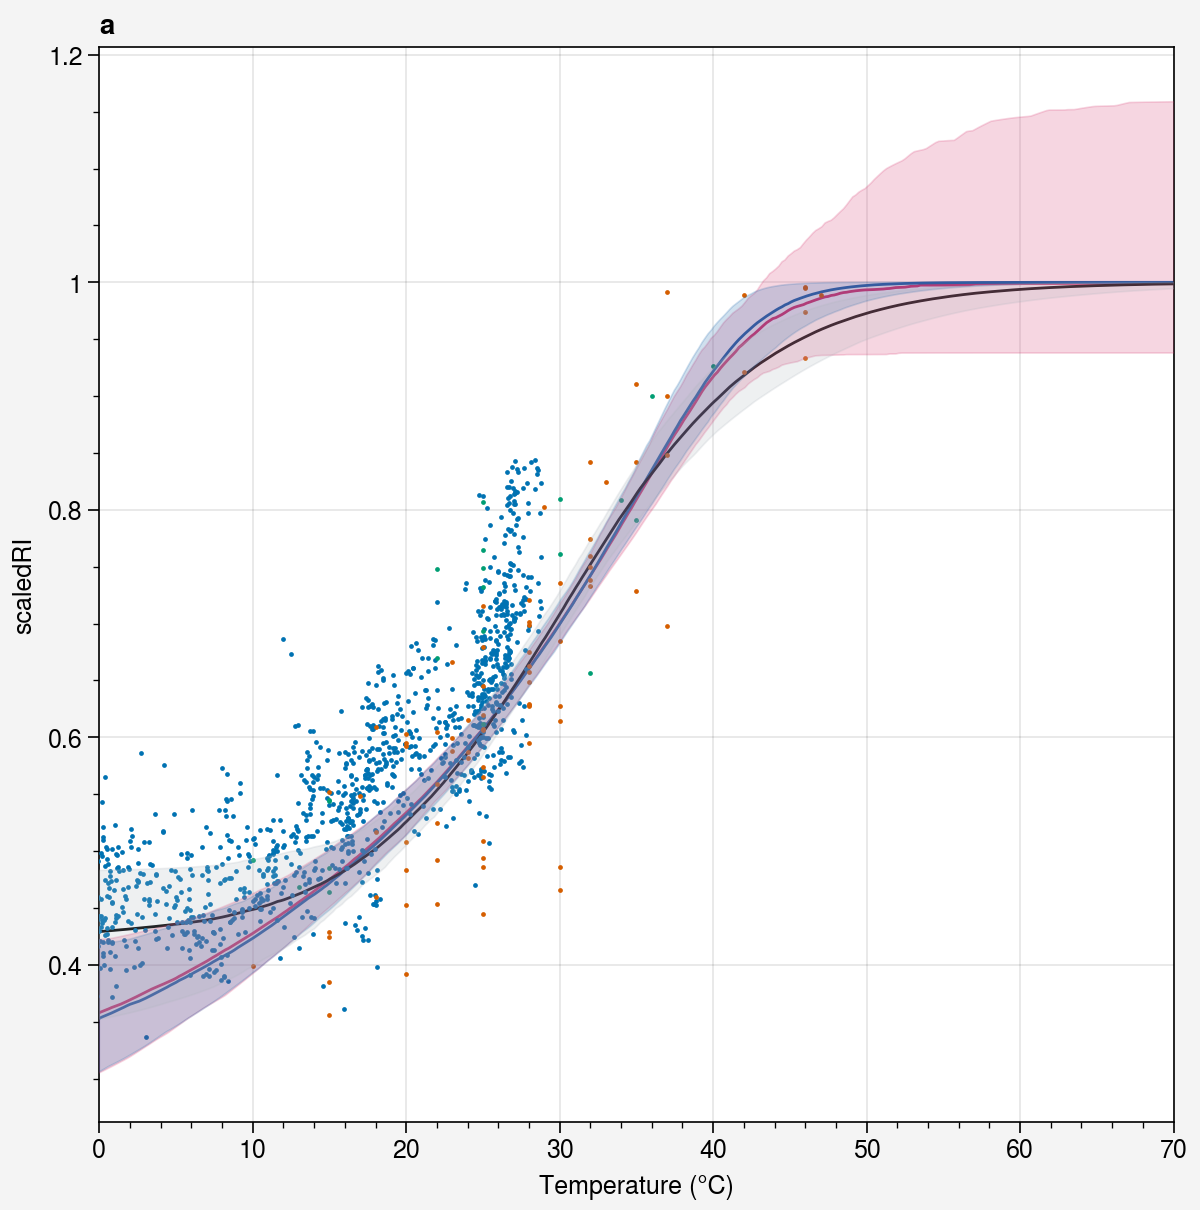

In [40]:

# Plot
fig, axs = plot.subplots(width=6)

axs[0].plot(x_vals, median_curve_free, color='pink7', lw=1, label='Fitted model (free upper limit)')
axs[0].fill_between(x_vals, lower_bound_free, upper_bound_free,
                   color='pink7', alpha=0.2, label='95% CI (free upper limit)',
                   zorder=5)

axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)
axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)
axs.format(
    xlim=(0,70)
)

## 2. Models with coretop data

### 2.1 hier_crtp | prior approximation

In [41]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='thermoT'
)
save_posterior(gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,filename_suffix="test01_cln_crtp")


00:06:54 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:07:14 - cmdstanpy - INFO - CmdStan done processing.
00:07:14 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pr


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp.nc')

In [42]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds['t0_culmeso'].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_univ_priorApprox'
gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='sst'
)
save_posterior(gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst,filename_suffix="test01_cln_crtp")


00:07:14 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:07:38 - cmdstanpy - INFO - CmdStan done processing.
00:07:38 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_priorApprox.stan', line 42, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_univ_pr


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc')

In [43]:
# Drop NaNs from coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

# Get posterior-based priors from generalized logistic fit
prior_mean_t0 = gen_logi_free_cul_meso_post_ds['t0_culmeso'].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_free_cul_meso_post_ds['t0_culmeso'].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_free_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_free_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_free_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_free_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_a = gen_logi_free_cul_meso_post_ds["a_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_a = gen_logi_free_cul_meso_post_ds["a_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_free_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_free_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_free_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_free_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_a": prior_mean_a,
    "prior_sd_a": prior_sd_a,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_free_hier_crtp_univ_priorApprox'
gen_logi_free_hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(
    data_normal_prior,
    stan_file=stan_file_name,
    temptype='thermoT'
)
save_posterior(gen_logi_free_hier_crtp_univ_prior_approx_post_ds,filename_suffix="test01_cln_crtp")


00:07:38 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_free_hier_crtp_univ_priorApprox.stan
✅ Compiled: gen_logi_free_hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:08:06 - cmdstanpy - INFO - CmdStan done processing.
00:08:06 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'gen_logi_free_hier_crtp_univ_priorApprox.stan', line 46, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_free_hier_crtp_u


Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_free_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_free_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp.nc')

In [44]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

data_normal_prior = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_univ_prior_approx_post_ds, diag = get_posterior(data=data_normal_prior, 
                                                                 stan_file=stan_file_name,
                                                                 temptype='thermoT',)
# Save posteriors
save_posterior(hier_crtp_univ_prior_approx_post_ds,filename_suffix="test01_cln_crtp")

###################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

data_normal_prior = {
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_univ_priorApprox'
hier_crtp_sst_univ_prior_approx_post_ds, diag = get_posterior(data=data_normal_prior, 
                                                                 stan_file=stan_file_name,
                                                                 temptype='sst',)
# Save posteriors
save_posterior(hier_crtp_sst_univ_prior_approx_post_ds,filename_suffix="test01_cln_crtp")

00:08:06 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: hier_crtp_univ_priorApprox.stan
✅ Compiled: hier_crtp_univ_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:08:09 - cmdstanpy - INFO - CmdStan done processing.
00:08:09 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ_priorApprox.stan', line 28, column 2 to column 64)
Consider re-running with show_console=True if the above output is unclear!



Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc')

In [45]:
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit for coretop
post_ds = gen_logi_free_hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp', 'a_crtp', 'b_crtp', 'k_crtp', 'v_crtp', 'Q_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)
ensemble_free_crtp = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_free_crtp[i, :] = generalized_logistic_model(
        x_vals,
        x0=row['t0_crtp'],
        a=row['a_crtp'],
        b=row['b_crtp'],
        k=row['k_crtp'],
        v=row['v_crtp'],
        Q=row['Q_crtp']
    )
    
median_curve_free_crtp = np.percentile(ensemble_free_crtp, 50, axis=0)
lower_bound_free_crtp = np.percentile(ensemble_free_crtp, 5, axis=0)
upper_bound_free_crtp = np.percentile(ensemble_free_crtp, 95, axis=0)

## CASE 2: Generalized logistic model with fixed upper limit for coretop
### calculate "median_curve_gen_logi_crtp"
post_ds = gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp','k_crtp','b_crtp','v_crtp','Q_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True) 

ensemble_gen_logi_crtp = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_gen_logi_crtp[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_crtp'],
        b=row['b_crtp'],
        k=row['k_crtp'],
        v=row['v_crtp'],
        Q=row['Q_crtp']
    )

# Compute percentiles
lower_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 5, axis=0)
upper_bound_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 95, axis=0)
median_curve_gen_logi_crtp = np.percentile(ensemble_gen_logi_crtp, 50, axis=0)

## CASE 3: Joint model with fixed upper limit for coretop
### hier_crtp_univ_prior_approx_post_ds
post_ds = hier_crtp_univ_prior_approx_post_ds
n_draws = 500
posterior_df = post_ds[['t0_crtp','k_crtp','b_crtp']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)

# Initialize matrix for storing ensemble predictions
ensemble_hier_crtp_priorApprox = np.zeros((n_draws, len(x_vals)))

# Evaluate the S-curve for each draw
for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_hier_crtp_priorApprox[i, :] = logistic_fixed_upper(
        x_vals,
        x0=row['t0_crtp'],
        k=row['k_crtp'],
        b=row['b_crtp']
    )

# Compute percentiles
lower_bound_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 5, axis=0)
upper_bound_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 95, axis=0)
median_curve_hier_crtp_priorApprox = np.percentile(ensemble_hier_crtp_priorApprox, 50, axis=0)

In [46]:
gen_logi_free_cul_meso_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_culmeso              (chain, draw) float64 38.1 31.4 ... 33.19 33.18
    k_culmeso               (chain, draw) float64 0.6758 0.4784 ... 0.2892
    Q_culmeso               (chain, draw) float64 3.851 68.31 ... 6.28 21.7
    v_culmeso               (chain, draw) float64 11.23 13.5 ... 7.706 9.804
    b_culmeso               (chain, draw) float64 0.3482 0.09395 ... 0.04271
    a_culmeso               (chain, draw) float64 0.9784 0.9813 ... 0.9877 1.043
    sigma_scaledRI_cul      (chain, draw) float64 0.07717 0.078 ... 0.08156
    sigma_scaledRI_meso     (chain, draw) float64 0.08863 0.09998 ... 0.1025
    sigma_scaledRI_culmeso  (chain, draw) float64 0.07971 0.0831 ... 0.08638
    inflection_point        (chain, draw) float64 41.68 36.84 ... 40.51 41.08
Attributes: (12/37)
    stan_version:                 2.36.0
    model:                        gen_logi_free_culmeso_model
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_free_culmeso
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       952.021
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_free_culmeso_cultureT.nc

Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_crtp', 'a_culmeso'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_crtp', 't0_culmeso'], 'k': ['k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmeso'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_crtp', 'a_culmeso'], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'a']
figure nrows, ncols: 2, 3


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:xlabel='a'>]], dtype=object))

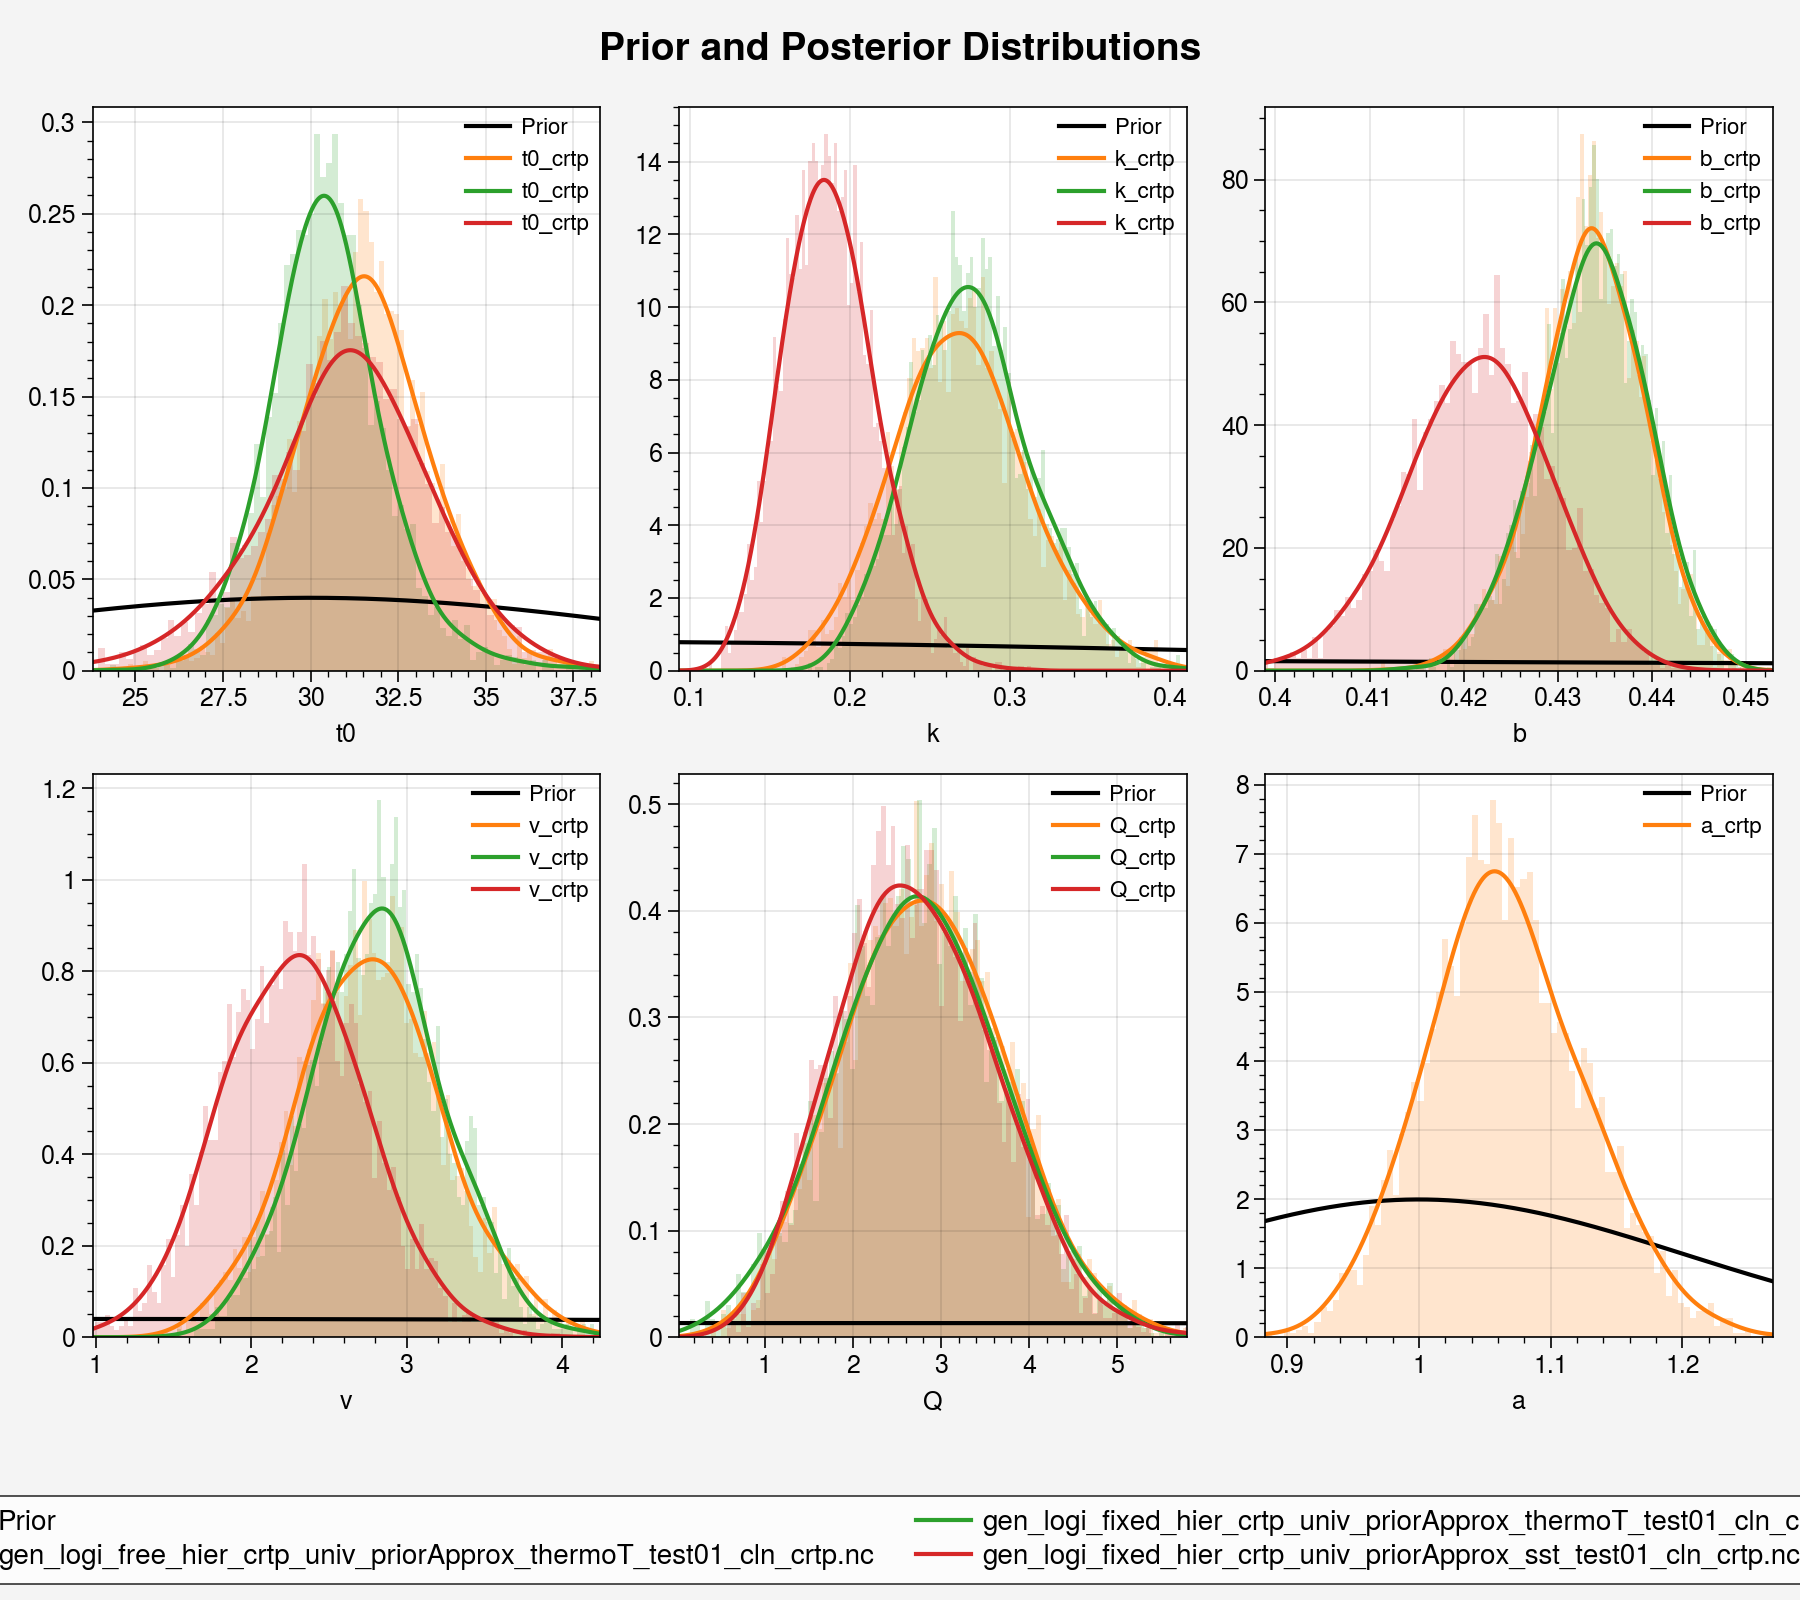

In [47]:
plot_prior_distributions(
    priors_list=gen_logi_free_cul_meso_post_ds.attrs['priors'],
    posterior_datasets=[
        gen_logi_free_cul_meso_post_ds,
        gen_logi_free_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst,
        ],
    set_leg_max_ncol=2,
    set_fig_height_factor=4,
    suffix_include="crtp"
)

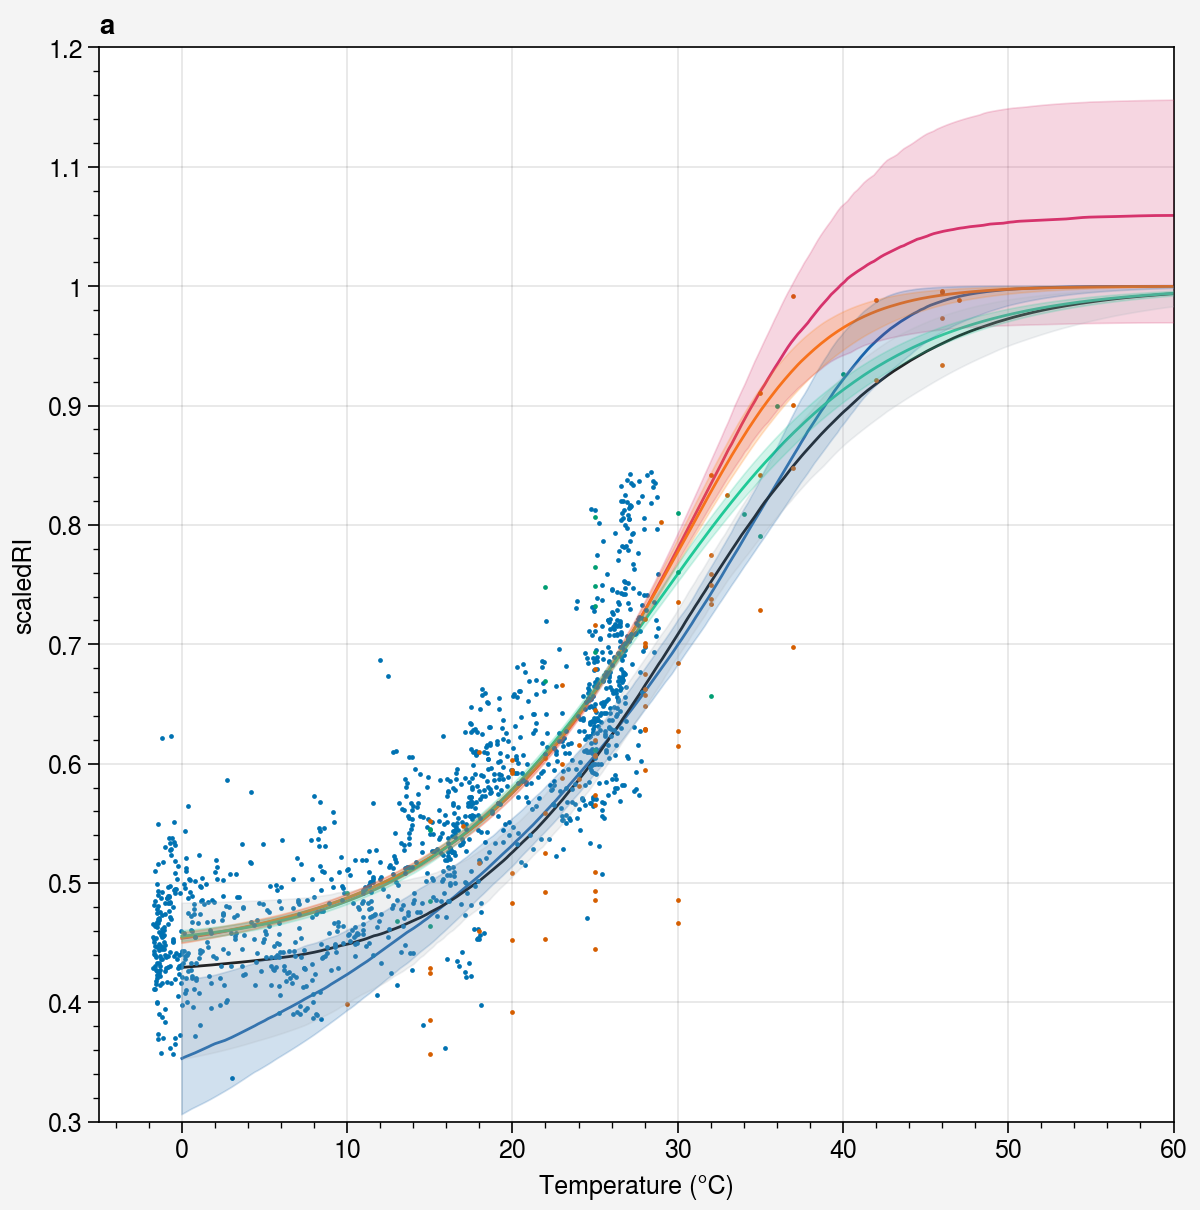

In [48]:
# Create 1000 ensemble members of S-curve from the posterior samples


# Plot
fig, axs = plot.subplots(width=6)

axs[0].plot(x_vals, median_curve_free_crtp, color='pink7', lw=1, label='Fitted model (free upper limit)')
axs[0].fill_between(x_vals, lower_bound_free_crtp, upper_bound_free_crtp,
                   color='pink7', alpha=0.2, label='95% CI (free upper limit)',
                   zorder=5)

axs[0].plot(x_vals, median_curve, color='blue9', lw=1, label='Fitted model')
axs[0].fill_between(x_vals, lower_bound, upper_bound, 
                   color='blue9', alpha=0.2, label='95% CI',
                   zorder=5)

axs[0].plot(x_vals, median_curve_jnt, color='k', lw=1, label='Joint model')
axs[0].fill_between(x_vals, lower_bound_jnt, upper_bound_jnt, 
                   color='gray5', alpha=0.2, label='95% CI (joint model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_gen_logi_crtp, color='tab:orange', lw=1, label='Hierarchical model (univariate prior approx.)')
axs[0].fill_between(x_vals, lower_bound_gen_logi_crtp, upper_bound_gen_logi_crtp, 
                   color='tab:orange', alpha=0.2, label='95% CI (hierarchical model)',
                   zorder=5)

axs[0].plot(x_vals, median_curve_hier_crtp_priorApprox, color='teal5', lw=1, label='Hierarchical model (univariate prior approx. SST)')
axs[0].fill_between(x_vals, lower_bound_hier_crtp_priorApprox, upper_bound_hier_crtp_priorApprox, 
                   color='teal5', alpha=0.2, label='95% CI (hierarchical model SST)',
                   zorder=5)

axs[0].set_xlabel('Temperature (°C)')

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    axs[0].scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
                   m='.', s=5, zorder=3)
    
# y_linear_schouten02 = predictTEXfromSST(x_vals, method_name='schouten02')
# y_kim10 = predictTEXfromSST(x_vals,method_name='kim2010_tex86H')

# ax = axs[0]
# ax.plot(x_vals, y_linear_schouten02, color='red9', lw=1, label='Schouten et al. (2002) linear fit')
# ax.plot(x_vals, y_kim10, color='green9', lw=1, label='Kim et al. (2010) linear fit')

axs.format(
    ylim=(0.3, 1.2),
    xlim=(-5, 60)
)

### 2.2 Fully joint cul-meso-coretop

In [49]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_post_ds, diag = get_posterior(data=data, 
                                                       stan_file=stan_file_name,
                                                       temptype='thermoT')
display(jnt_cul_meso_crtp_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_post_ds,filename_suffix="test01_cln_crtp")

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'jnt_cul_meso_crtp'
jnt_cul_meso_crtp_sst_post_ds, diag = get_posterior(data=data, 
                                                    stan_file=stan_file_name,
                                                    temptype='sst')
display(jnt_cul_meso_crtp_sst_post_ds)

# Save posteriors
save_posterior(jnt_cul_meso_crtp_sst_post_ds,filename_suffix="test01_cln_crtp")


00:11:49 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: jnt_cul_meso_crtp.stan
✅ Compiled: jnt_cul_meso_crtp.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

00:11:53 - cmdstanpy - INFO - CmdStan done processing.
00:11:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: beta_lpdf: Random variable is 3.99313, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'jnt_cul_meso_crtp.stan', line 42, column 2 to column 65)
Exception: beta_lpdf: Random variable is 3.25794, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.39111, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.54016, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.51299, but must be in the interval [0, 1] (in 'jnt_cul_meso_crtp.stan', line 29, column 2 to column 35)
	Exception

<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_culmesocore       (chain, draw) float64 29.94 29.81 29.69 ... 29.96 29.7
    k_culmesocore        (chain, draw) float64 0.1322 0.1277 ... 0.1283 0.1301
    b_culmesocore        (chain, draw) float64 0.4477 0.4433 ... 0.4418 0.441
    sigma_scaledRI_cul   (chain, draw) float64 0.07878 0.0797 ... 0.0887 0.07489
    sigma_scaledRI_meso  (chain, draw) float64 0.0754 0.08151 ... 0.07554 0.1085
    sigma_scaledRI_crtp  (chain, draw) float64 0.05454 0.05433 ... 0.05381
Attributes: (12/42)
    stan_version:                 2.36.0
    model:                        jnt_cul_meso_crtp_model
    num_draws_sampling:           1000
    stan_model_name:              jnt_cul_meso_crtp
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00192
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1774.89
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/jnt_cul_meso_crtp_sst_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/jnt_cul_meso_crtp_sst_test01_cln_crtp.nc')

In [50]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'gen_logi_fixed_culmesocore'
gen_logi_fixed_culmesocore_post_ds, diag = get_posterior(data=data, 
                                                       stan_file=stan_file_name,
                                                       temptype='thermoT')
display(gen_logi_fixed_culmesocore_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_culmesocore_post_ds,filename_suffix="test01_cln_crtp")

##########################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
}
stan_file_name = 'gen_logi_fixed_culmesocore'
gen_logi_fixed_culmesocore_sst_post_ds, diag = get_posterior(data=data, 
                                                           stan_file=stan_file_name,
                                                           temptype='sst')
display(gen_logi_fixed_culmesocore_sst_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_culmesocore_sst_post_ds,filename_suffix="test01_cln_crtp")


00:11:53 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: gen_logi_fixed_culmesocore.stan
✅ Compiled: gen_logi_fixed_culmesocore.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

00:14:21 - cmdstanpy - INFO - CmdStan done processing.
00:14:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_culmesocore.stan', line 50, column 2 to column 63)
Exception: beta_lpdf: Random variable is 3.25794, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.51299, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to column 35)
	Exception: beta_lpdf: Random variable is 1.50402, but must be in the interval [0, 1] (in 'gen_logi_fixed_culmesocore.stan', line 33, column 2 to c

<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_culmesocore       (chain, draw) float64 39.52 13.32 34.97 ... 9.516 11.35
    k_culmesocore        (chain, draw) float64 0.1858 0.1845 ... 0.1285 0.1321
    Q_culmesocore        (chain, draw) float64 0.4913 57.14 ... 15.61 16.33
    v_culmesocore        (chain, draw) float64 2.015 2.0 5.137 ... 1.109 1.291
    b_culmesocore        (chain, draw) float64 0.432 0.4319 ... 0.4388 0.4325
    sigma_scaledRI_cul   (chain, draw) float64 0.08406 0.09399 ... 0.08642
    sigma_scaledRI_meso  (chain, draw) float64 0.1026 0.06955 ... 0.08067
    sigma_scaledRI_crtp  (chain, draw) float64 0.05375 0.05525 ... 0.05433
    inflection_point     (chain, draw) float64 43.29 17.08 39.34 ... 10.32 13.29
Attributes: (12/42)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_culmesocore_model
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_culmesocore
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.0062
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       947.185
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmesocore_sst_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmesocore_sst_test01_cln_crtp.nc')

### 2.3 Joint cul-meso --> hier coretop

In [51]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()


### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'hier_crtp_univ'
hier_crtp_post_ds, diag = get_posterior(data=data, 
                                                stan_file=stan_file_name,
                                                temptype='thermoT',)
display(hier_crtp_post_ds)
# Save posteriors
save_posterior(hier_crtp_post_ds,filename_suffix="test01_cln_crtp")

###########################################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,

}
stan_file_name = 'hier_crtp_univ'
hier_crtp_sst_post_ds, diag = get_posterior(data=data, 
                                                    stan_file=stan_file_name,
                                                    temptype='sst',)
display(hier_crtp_sst_post_ds)
# Save posteriors
save_posterior(hier_crtp_sst_post_ds,filename_suffix="test01_cln_crtp")

00:14:21 - cmdstanpy - INFO - CmdStan start processing


🔧 Compiling Stan model: hier_crtp_univ.stan
✅ Compiled: hier_crtp_univ.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

00:14:35 - cmdstanpy - INFO - CmdStan done processing.
00:14:35 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 68, column 2 to column 48)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 62, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_univ.stan', line 63, column 4 

<xarray.Dataset>
Dimensions:              (draw: 1000, chain: 4)
Coordinates:
  * chain                (chain) int64 1 2 3 4
  * draw                 (draw) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
Data variables:
    t0_culmeso           (chain, draw) float64 29.61 30.98 30.14 ... 30.7 28.59
    k_culmeso            (chain, draw) float64 0.1583 0.138 ... 0.1744 0.1202
    b_culmeso            (chain, draw) float64 0.4193 0.4298 ... 0.454 0.3749
    t0_crtp              (chain, draw) float64 29.47 30.11 30.01 ... 29.88 29.8
    k_crtp               (chain, draw) float64 0.1246 0.1163 ... 0.1194 0.1221
    b_crtp               (chain, draw) float64 0.4368 0.4374 ... 0.4377 0.4387
    sigma_t0_culmeso     (chain, draw) float64 2.756 0.8405 ... 0.4568 1.824
    sigma_k_culmeso      (chain, draw) float64 0.3898 0.01616 ... 0.1071 0.0739
    sigma_b_culmeso      (chain, draw) float64 0.1241 0.05248 ... 0.0639 0.03583
    sigma_scaledRI_cul   (chain, draw) float64 0.07696 0.07544 ... 0.06966
    sigma_scaledRI_meso  (chain, draw) float64 0.1098 0.08713 ... 0.104 0.08911
    sigma_scaledRI_crtp  (chain, draw) float64 0.05467 0.05446 ... 0.05503
Attributes: (12/42)
    stan_version:                 2.36.0
    model:                        hier_crtp_univ_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_univ
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.06258
    stan_diag_n_high_rhat:        10
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       52.6157
    stan_diag_ess_status:         FAIL
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_univ_sst_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_univ_sst_test01_cln_crtp.nc')

Grouped param names: {'t0': ['t0_culmeso', 't0_culmesocore', 't0_crtp'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_culmesocore', 'v_crtp'], 'Q': ['Q_culmesocore', 'Q_crtp', 'Q_culmeso'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmeso', 't0_culmesocore', 't0_crtp'], 'k': ['k_crtp', 'k_culmeso', 'k_culmesocore'], 'b': ['b_culmesocore', 'b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_culmesocore', 'v_crtp'], 'Q': ['Q_culmesocore', 'Q_crtp', 'Q_culmeso'], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b', 'v', 'Q']
figure nrows, ncols: 2, 3


(<Figure size 900x800 with 6 Axes>,
 array([[<AxesSubplot:xlabel='t0'>, <AxesSubplot:xlabel='k'>,
         <AxesSubplot:xlabel='b'>],
        [<AxesSubplot:xlabel='v'>, <AxesSubplot:xlabel='Q'>,
         <AxesSubplot:>]], dtype=object))

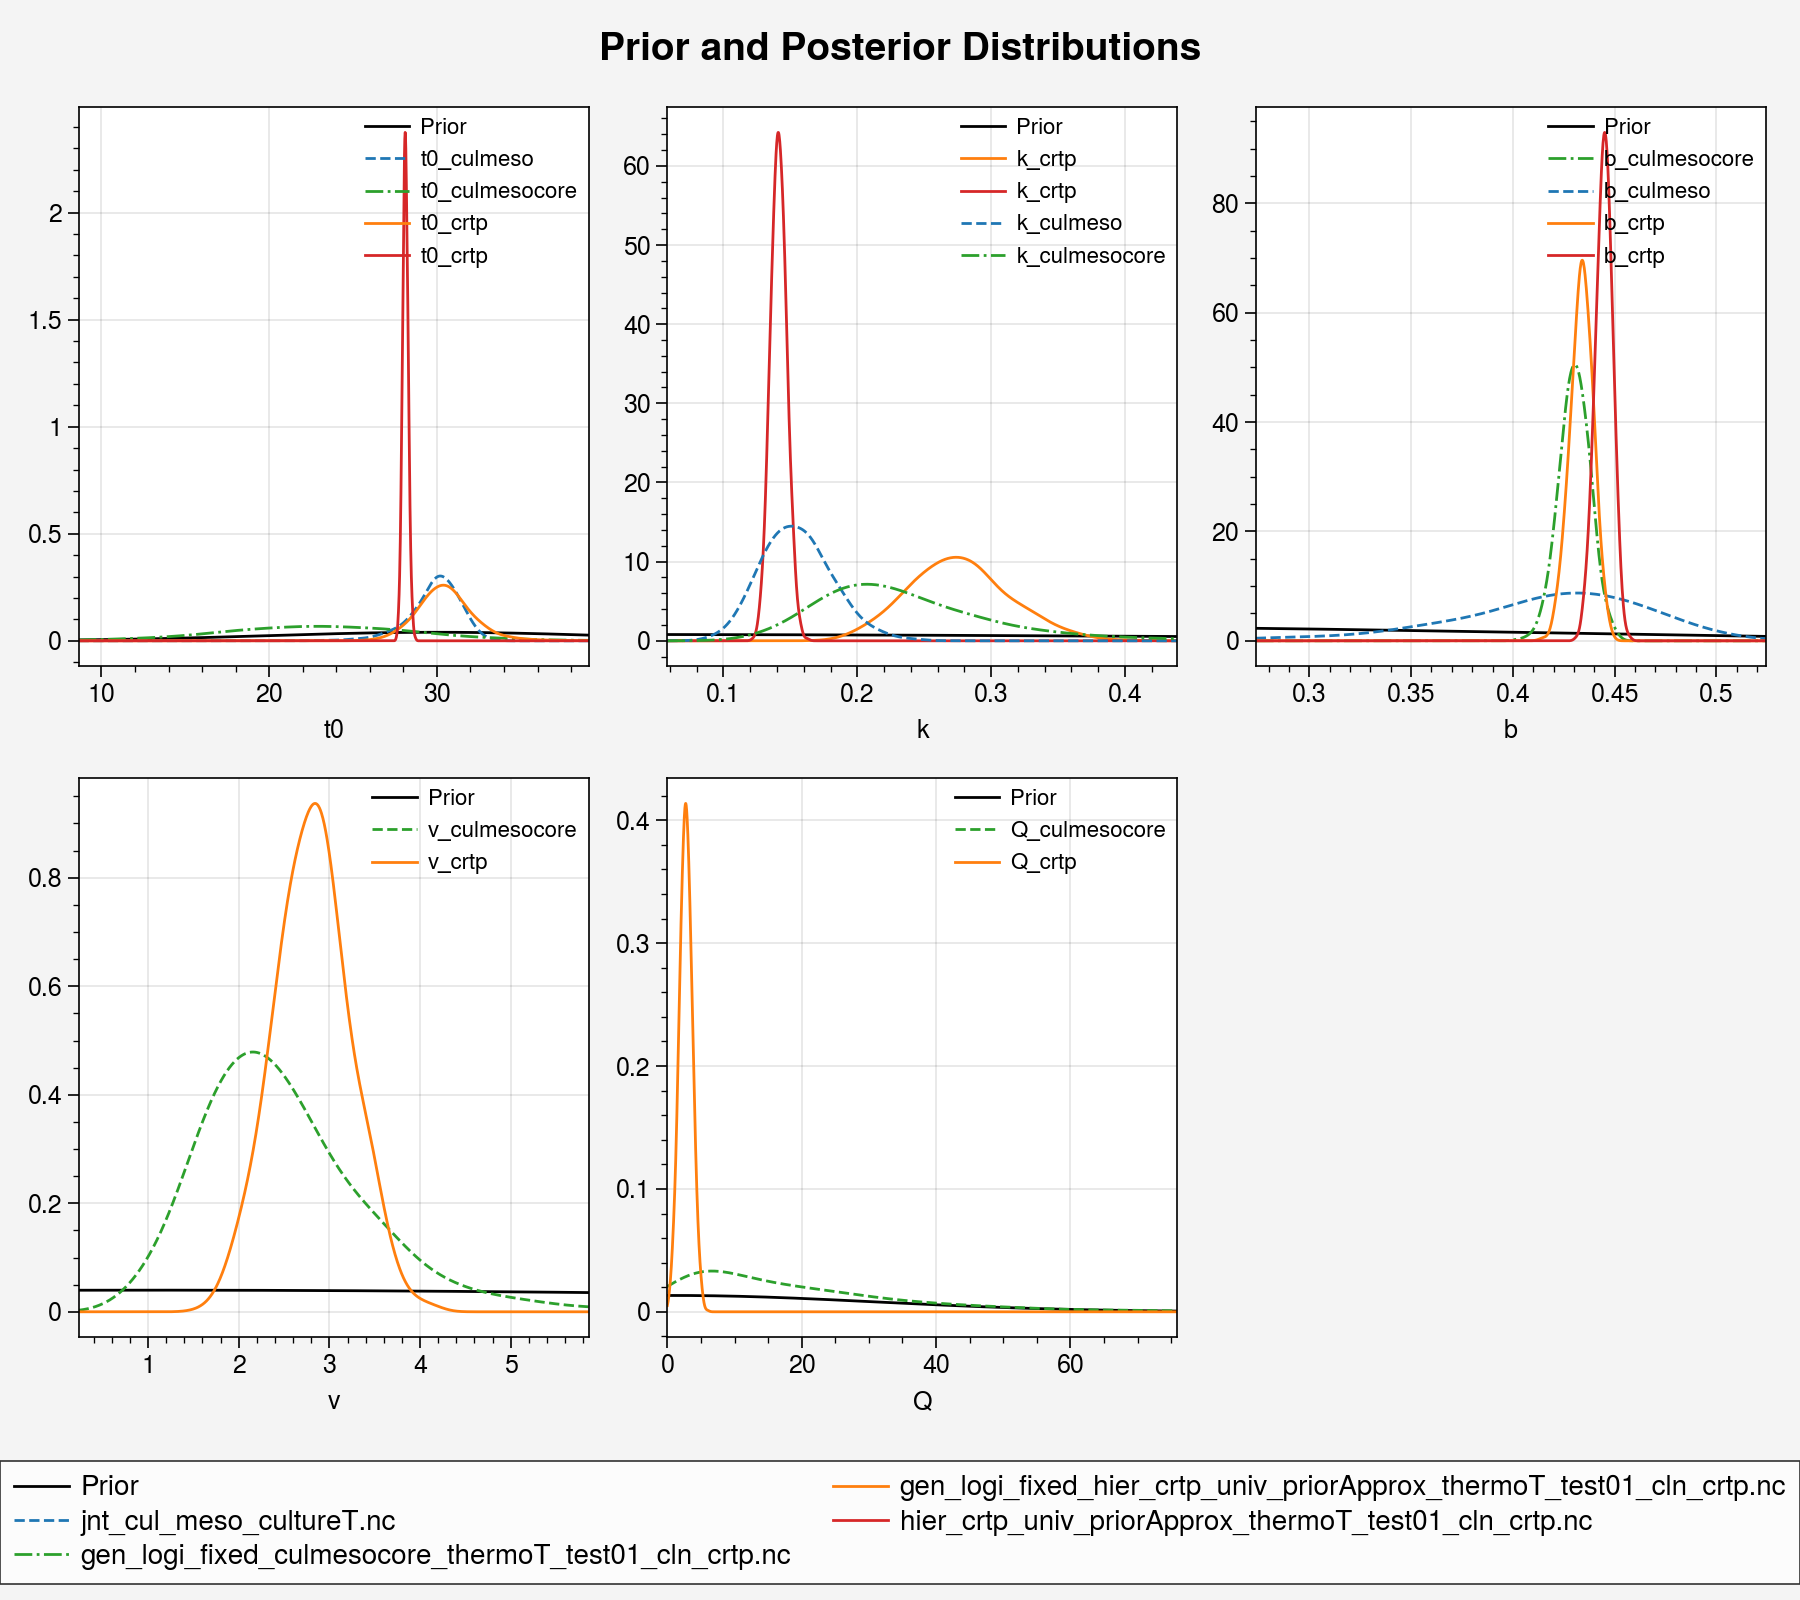

In [52]:
priors = gen_logi_fixed_cul_meso_post_ds.attrs['priors']
plot_prior_distributions(priors,
                            posterior_datasets=[
                                jnt_cul_meso_post_ds,
                                # gen_logi_fixed_cul_meso_post_ds,
                                # jnt_cul_meso_crtp_post_ds,
                                gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
                                # jnt_cul_meso_crtp_sst_post_ds,
                                gen_logi_fixed_culmesocore_post_ds,
                                # hier_crtp_post_ds,
                                # hier_crtp_sst_post_ds,
                                # hier_crtp_univ_prior_logmixture_post_ds,
                                hier_crtp_univ_prior_approx_post_ds,
                                # hier_crtp_sst_univ_prior_logmixture_post_ds,
                                # hier_crtp_sst_univ_prior_approx_post_ds
                                ],
                            use_linestyle_by_param=True,
                            show_histogram=False,
                            set_linewidth=1,
                            set_fig_height_factor=4,
                            set_leg_max_ncol=2,
                            )

In [53]:
x_vals = np.linspace(0, 100, 500)

## CASE 1: Generalized logistic model with free upper limit for coretop
post_ds = gen_logi_fixed_culmesocore_post_ds
n_draws = 500
posterior_df = post_ds[['t0_culmesocore', 'b_culmesocore', 'k_culmesocore', 'v_culmesocore', 'Q_culmesocore']].to_dataframe().reset_index()
sampled_draws = posterior_df.sample(n=n_draws, replace=False, random_state=42).reset_index(drop=True)
ensemble_fixed_culmesocore = np.zeros((n_draws, len(x_vals)))

for i in range(n_draws):
    row = sampled_draws.loc[i]
    ensemble_fixed_culmesocore[i, :] = generalized_logistic_model_fixed_upper(
        x_vals,
        x0=row['t0_culmesocore'],
        b=row['b_culmesocore'],
        k=row['k_culmesocore'],
        v=row['v_culmesocore'],
        Q=row['Q_culmesocore']
    )
    
median_curve_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 50, axis=0)
lower_bound_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 5, axis=0)
upper_bound_fixed_culmesocore = np.percentile(ensemble_fixed_culmesocore, 95, axis=0)

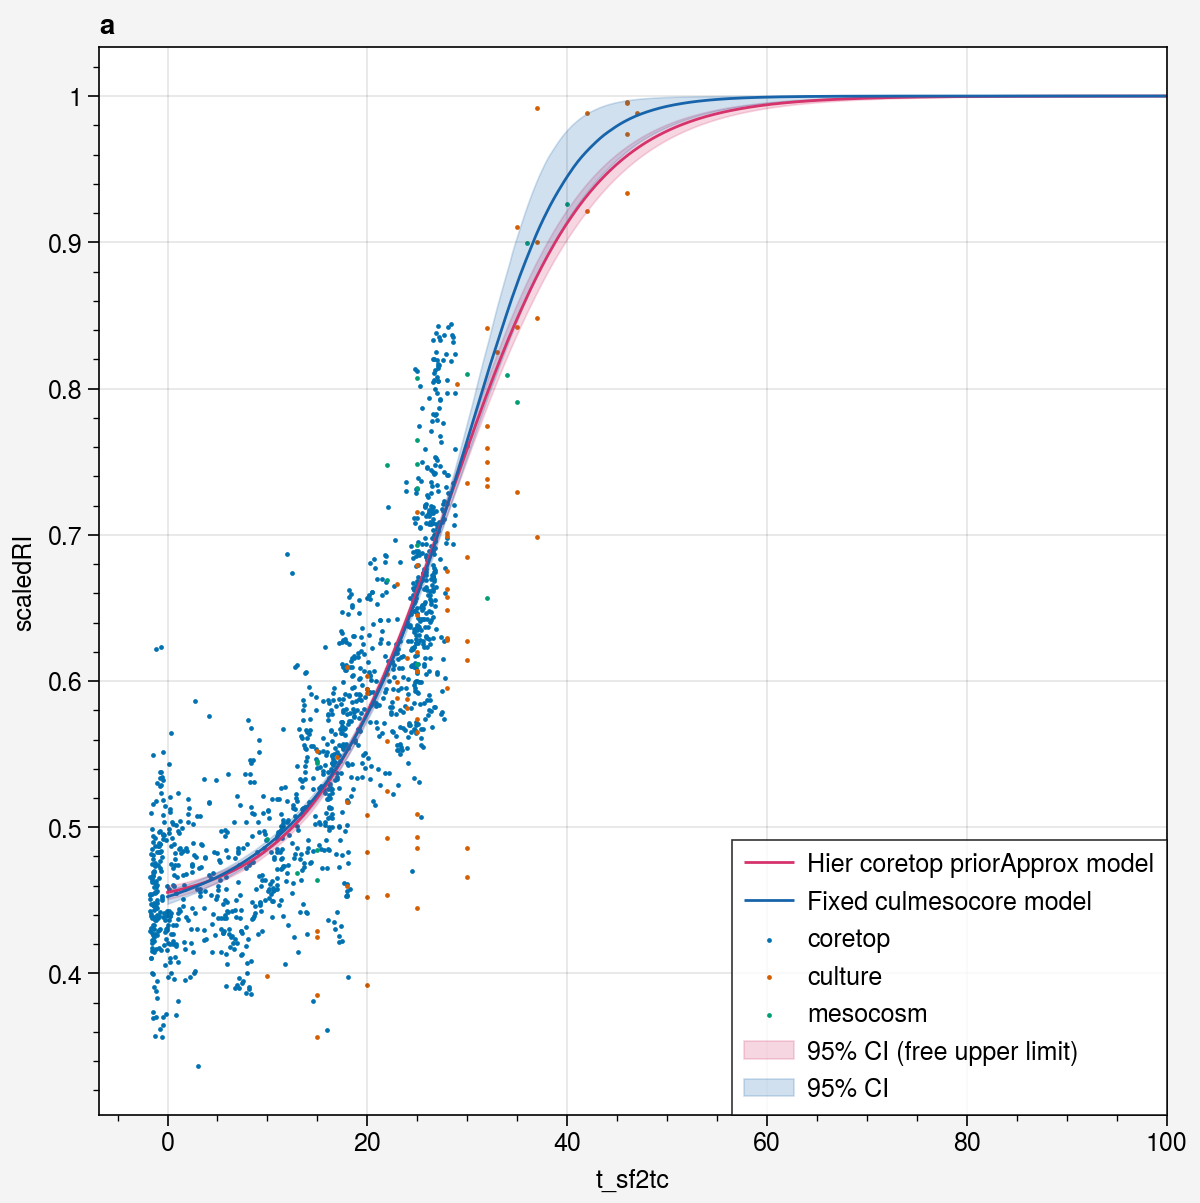

In [54]:
fig, axs = plot.subplots(width=6)

ax = axs[0]
grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['t_sf2tc'], group['scaledRI'], label=name, 
               m='.', s=5)

### fully joint coretop model
ax.plot(x_vals, median_curve_hier_crtp_priorApprox, color='pink7', lw=1, label='Hier coretop priorApprox model')
ax.fill_between(x_vals, lower_bound_hier_crtp_priorApprox, upper_bound_hier_crtp_priorApprox,
               color='pink7', alpha=0.2, label='95% CI (free upper limit)')

### fixed culmesocore model
ax.plot(x_vals, median_curve_fixed_culmesocore, color='blue9', lw=1, label='Fixed culmesocore model')
ax.fill_between(x_vals, lower_bound_fixed_culmesocore, upper_bound_fixed_culmesocore, 
               color='blue9', alpha=0.2, label='95% CI')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='lr',ncols=1)

### 2.4 Joint cul-meso --> hier coretop - Multivariate

#### 2.4.1 fit with T and gdgt23ratio

##### Prior Approximation

In [ ]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(
    data=data, stan_file=stan_file_name,temptype='thermoT')

display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

00:57:12 - cmdstanpy - INFO - CmdStan start processing


No no3 data passing for multivariate model.
🔍 Predictor auto-detection:
   GDGT23 keys: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys: [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:57:50 - cmdstanpy - INFO - CmdStan done processing.
00:57:50 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 30.49 31.7 ... 29.64 28.57
    k_crtp                  (chain, draw) float64 0.3152 0.2998 ... 0.2486
    b_crtp                  (chain, draw) float64 0.4546 0.4467 ... 0.4485
    Q_crtp                  (chain, draw) float64 2.562 1.935 ... 3.262 4.126
    v_crtp                  (chain, draw) float64 3.335 3.402 ... 2.904 2.918
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.004672 ... -0.004906
    beta0_no3_crtp          (chain, draw) float64 -0.04421 -0.06097 ... -0.05044
    sigma_scaledRI_crtp     (chain, draw) float64 0.04944 0.05151 ... 0.04914
    inflection_point        (chain, draw) float64 34.31 35.79 ... 34.1 32.88
Attributes: (12/36)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00395
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1497.03
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp.nc')

In [91]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
    "prior_mean_Q": prior_mean_Q,
    "prior_sd_Q": prior_sd_Q,
    "prior_mean_v": prior_mean_v,
    "prior_sd_v": prior_sd_v,
}

stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='sst')
display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

00:58:17 - cmdstanpy - INFO - CmdStan start processing


No no3 data passing for multivariate model.
🔍 Predictor auto-detection:
   GDGT23 keys: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys: [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:59:05 - cmdstanpy - INFO - CmdStan done processing.
00:59:05 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crt

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 25.32 21.67 ... 31.16 31.05
    k_crtp                  (chain, draw) float64 0.1312 0.1366 ... 0.1512
    b_crtp                  (chain, draw) float64 0.4435 0.4547 ... 0.4382
    Q_crtp                  (chain, draw) float64 2.074 3.517 ... 1.604 1.623
    v_crtp                  (chain, draw) float64 1.358 1.271 ... 1.916 1.925
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.005659 ... -0.006468
    beta0_no3_crtp          (chain, draw) float64 -0.02588 -0.0673 ... -0.02111
    sigma_scaledRI_crtp     (chain, draw) float64 0.05028 0.04992 ... 0.0496
    inflection_point        (chain, draw) float64 27.66 23.43 ... 35.54 35.38
Attributes: (12/36)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00213
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1359.26
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc')

In [92]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_multiv_priorApprox'
hier_crtp_priorApprox_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(hier_crtp_priorApprox_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_priorApprox_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

00:59:06 - cmdstanpy - INFO - CmdStan start processing


No no3 data passing for multivariate model.
🔍 Predictor auto-detection:
   GDGT23 keys: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys: [] → use_no3 = 0
🔧 Compiling Stan model: hier_crtp_multiv_priorApprox.stan
✅ Compiled: hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:59:10 - cmdstanpy - INFO - CmdStan done processing.
00:59:10 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scal

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 27.26 26.81 ... 27.22 27.27
    k_crtp                  (chain, draw) float64 0.1477 0.1246 ... 0.1431
    b_crtp                  (chain, draw) float64 0.4712 0.4586 ... 0.4706
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.00465 ... -0.005604
    beta0_no3_crtp          (chain, draw) float64 -0.006101 ... -0.02899
    sigma_scaledRI_crtp     (chain, draw) float64 0.04932 0.04933 ... 0.0499
Attributes: (12/36)
    stan_version:                 2.36.0
    model:                        hier_crtp_multiv_priorApprox_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00468
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1750.9
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp.nc')

In [93]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()


prior_mean_t0 = jnt_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = jnt_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = jnt_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = jnt_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = jnt_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = jnt_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

data = {
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
    "prior_mean_t0": prior_mean_t0,
    "prior_sd_t0": prior_sd_t0,
    "prior_mean_k": prior_mean_k,
    "prior_sd_k": prior_sd_k,
    "prior_mean_b": prior_mean_b,
    "prior_sd_b": prior_sd_b,
}

stan_file_name = 'hier_crtp_multiv_priorApprox'
hier_crtp_priorApprox_multiv_sst_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='sst')
display(hier_crtp_priorApprox_multiv_sst_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_priorApprox_multiv_sst_g23r_post_ds,filename_suffix="test01_cln_crtp")

No no3 data passing for multivariate model.
🔍 Predictor auto-detection:
   GDGT23 keys: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys: [] → use_no3 = 0
🔧 Compiling Stan model: hier_crtp_multiv_priorApprox.stan


00:59:10 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: hier_crtp_multiv_priorApprox.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

00:59:15 - cmdstanpy - INFO - CmdStan done processing.
00:59:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv_priorApprox.stan', line 59, column 4 to column 66)
	Exception: normal_lpdf: Scal

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 28.46 28.29 28.0 ... 28.4 28.7
    k_crtp                  (chain, draw) float64 0.1163 0.1163 ... 0.1151
    b_crtp                  (chain, draw) float64 0.4555 0.4596 ... 0.4578
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.005208 ... -0.005145
    beta0_no3_crtp          (chain, draw) float64 -0.01927 ... -0.04629
    sigma_scaledRI_crtp     (chain, draw) float64 0.04926 0.05183 ... 0.05141
Attributes: (12/36)
    stan_version:                 2.36.0
    model:                        hier_crtp_multiv_priorApprox_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00142
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1747.94
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc')

##### Full Hierachical (Jnt Cul-Meso --> Hier Coretop)

In [106]:
import TEXAS
importlib.reload(TEXAS.stan.sampler)

from TEXAS.stan.sampler import get_posterior

In [105]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,
}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst',)
display(gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
save_posterior(gen_logi_fixed_hier_crtp_sst_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

01:11:51 - cmdstanpy - INFO - CmdStan start processing


No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1282)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv.stan


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

01:16:27 - cmdstanpy - INFO - CmdStan done processing.
01:16:27 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception:

<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables: (12/20)
    t0_culmeso              (chain, draw) float64 33.04 33.54 ... 33.5 39.24
    k_culmeso               (chain, draw) float64 0.3706 0.3742 ... 0.3134
    b_culmeso               (chain, draw) float64 0.275 0.352 ... 0.1605 0.1905
    Q_culmeso               (chain, draw) float64 15.53 7.083 ... 7.093 3.499
    v_culmeso               (chain, draw) float64 6.65 5.808 ... 5.849 8.851
    t0_crtp                 (chain, draw) float64 31.36 33.57 ... 32.92 36.21
    ...                      ...
    sigma_b_culmeso         (chain, draw) float64 0.21 0.1249 ... 0.2264 0.2732
    sigma_Q_culmeso         (chain, draw) float64 0.7873 0.4942 ... 0.7479
    sigma_v_culmeso         (chain, draw) float64 0.1935 0.4807 ... 0.2201
    sigma_scaledRI_cul      (chain, draw) float64 0.07955 0.07558 ... 0.07963
    sigma_scaledRI_meso     (chain, draw) float64 0.08355 0.0704 ... 0.1153
    sigma_scaledRI_crtp     (chain, draw) float64 0.05141 0.05194 ... 0.05241
Attributes: (12/48)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_model
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.01584
    stan_diag_n_high_rhat:        4
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       354.185
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc')

In [107]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
save_posterior(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

01:23:28 - cmdstanpy - INFO - Chain [1] start processing
01:23:28 - cmdstanpy - INFO - Chain [2] start processing
01:23:28 - cmdstanpy - INFO - Chain [3] start processing
01:23:28 - cmdstanpy - INFO - Chain [4] start processing


No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1282)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (De

01:25:03 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 44.573 seconds (Warm-up)
Chain [4] 50.811 seconds (Sampling)
Chain [4] 95.384 seconds (Total)
Chain [4] 
Chain [4] 


01:25:04 - cmdstanpy - INFO - Chain [2] done processing


...

01:25:17 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 55.535 seconds (Warm-up)
Chain [1] 53.171 seconds (Sampling)
Chain [1] 108.706 seconds (Total)
Chain [1] 
Chain [1] 


01:25:19 - cmdstanpy - INFO - Chain [3] done processing
01:25:19 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 58.703 seconds (Warm-up)
Chain [3] 52.059 seconds (Sampling)
Chain [3] 110.762 seconds (Total)
Chain [3] 
Chain [3] 
Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp.nc')

In [108]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,

}
stan_file_name = 'gen_logi_fixed_hier_crtp_multiv'
gen_logi_fixed_hier_crtp_multiv_g23r_post_ds2, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
save_posterior(gen_logi_fixed_hier_crtp_multiv_g23r_post_ds2,filename_suffix="test01_cln_crtp")

01:25:19 - cmdstanpy - INFO - Chain [1] start processing
01:25:19 - cmdstanpy - INFO - Chain [2] start processing
01:25:19 - cmdstanpy - INFO - Chain [3] start processing
01:25:19 - cmdstanpy - INFO - Chain [4] start processing


No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1282)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (De

01:26:58 - cmdstanpy - INFO - Chain [2] done processing
01:26:59 - cmdstanpy - INFO - Chain [4] done processing


Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 52.91 seconds (Warm-up)
Chain [2] 46.19 seconds (Sampling)
Chain [2] 99.1 seconds (Total)
Chain [2] 
Chain [2] 
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 48.037 seconds (Warm-up)
Chain [4] 51.178 seconds (Sampling)
Chain [4] 99.215 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [3] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1800 / 2000 [ 90%]  (Sampling)


01:27:11 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 59.131 seconds (Warm-up)
Chain [1] 52.288 seconds (Sampling)
Chain [1] 111.419 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)


01:27:16 - cmdstanpy - INFO - Chain [3] done processing
01:27:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 110, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv.stan', line 82, column 4 to column 63)
Exception

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 63.838 seconds (Warm-up)
Chain [3] 52.738 seconds (Sampling)
Chain [3] 116.576 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp.nc')

In [109]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()

### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(t_crtp),
    "t_crtp": t_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,

}
stan_file_name = 'hier_crtp_multiv'
hier_crtp_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                            stan_file=stan_file_name,
                                                            temptype='thermoT')
display(hier_crtp_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

#####################################################
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_crtp": len(sst_crtp),
    "t_crtp": sst_crtp,
    "scaledRI_crtp": scaledRI_crtp,
    "gdgt23ratio_crtp": gdgt23ratio_crtp,

}
stan_file_name = 'hier_crtp_multiv'
hier_crtp_sst_multiv_g23r_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst',)
display(hier_crtp_sst_multiv_g23r_post_ds)

# Save posteriors
save_posterior(hier_crtp_sst_multiv_g23r_post_ds,filename_suffix="test01_cln_crtp")

01:27:16 - cmdstanpy - INFO - Chain [1] start processing
01:27:16 - cmdstanpy - INFO - Chain [2] start processing
01:27:16 - cmdstanpy - INFO - Chain [3] start processing
01:27:16 - cmdstanpy - INFO - Chain [4] start processing


No no3 data passing for multivariate model; injecting zeros.
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1282)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    [] → use_no3 = 0
🔧 Compiling Stan model: hier_crtp_multiv.stan
✅ Compiled: hier_crtp_multiv.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag

01:27:24 - cmdstanpy - INFO - Chain [2] done processing


Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [4] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 5.428 seconds (Warm-up)
Chain [2] 2.552 seconds (Sampling)
Chain [2] 7.98 seconds (Total)
Chain [2] 
Chain [2] 


01:27:24 - cmdstanpy - INFO - Chain [3] done processing


...

01:27:34 - cmdstanpy - INFO - Chain [2] done processing
01:27:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', lin

Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 5.634 seconds (Warm-up)
Chain [2] 2.759 seconds (Sampling)
Chain [2] 8.393 seconds (Total)
Chain [2] 
Chain [2] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables: (12/14)
    t0_culmeso              (chain, draw) float64 28.35 28.76 ... 30.16 32.08
    k_culmeso               (chain, draw) float64 0.1189 0.1468 ... 0.1663
    b_culmeso               (chain, draw) float64 0.3715 0.37 ... 0.4497 0.4806
    t0_crtp                 (chain, draw) float64 28.3 28.46 ... 28.15 28.42
    k_crtp                  (chain, draw) float64 0.106 0.113 ... 0.1104 0.1097
    b_crtp                  (chain, draw) float64 0.444 0.4505 ... 0.4459 0.4516
    ...                      ...
    sigma_t0_culmeso        (chain, draw) float64 0.3292 8.427 ... 8.5 3.032
    sigma_k_culmeso         (chain, draw) float64 0.164 0.09571 ... 0.07521
    sigma_b_culmeso         (chain, draw) float64 0.08322 0.1876 ... 0.2274
    sigma_scaledRI_cul      (chain, draw) float64 0.07604 0.07207 ... 0.07737
    sigma_scaledRI_meso     (chain, draw) float64 0.09111 0.09762 ... 0.08763
    sigma_scaledRI_crtp     (chain, draw) float64 0.0517 0.0512 ... 0.05153
Attributes: (12/48)
    stan_version:                 2.36.0
    model:                        hier_crtp_multiv_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.01426
    stan_diag_n_high_rhat:        3
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       275.097
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc


PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc')

#### 2.4.2 fit the data with T, gdgt23ratio, and no3

##### Prior Approximation

In [110]:

# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff_values = [
    # 1, 
    1.5, 
    # 2, 2.5, 2.7,
    # 5, 10, 15,100
    ]
for no3_cutoff in no3_cutoff_values:
    print(no3_cutoff)
    data = {
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

        "prior_mean_t0": prior_mean_t0,
        "prior_sd_t0": prior_sd_t0,
        "prior_mean_k": prior_mean_k,
        "prior_sd_k": prior_sd_k,
        "prior_mean_b": prior_mean_b,
        "prior_sd_b": prior_sd_b,
        "prior_mean_Q": prior_mean_Q,
        "prior_sd_Q": prior_sd_Q,
        "prior_mean_v": prior_mean_v,
        "prior_sd_v": prior_sd_v,
    }
    

    stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='thermoT')
    display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds,filename_suffix="test01_cln_crtp")

01:27:35 - cmdstanpy - INFO - Chain [1] start processing
01:27:35 - cmdstanpy - INFO - Chain [2] start processing
01:27:35 - cmdstanpy - INFO - Chain [3] start processing
01:27:35 - cmdstanpy - INFO - Chain [4] start processing


1.5
🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1232)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 1000 (Default)
Chain [2] save_warmup = false (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.8 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Ch

01:28:24 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 23.63 seconds (Warm-up)
Chain [1] 25.812 seconds (Sampling)
Chain [1] 49.442 seconds (Total)
Chain [1] 
Chain [1] 


01:28:25 - cmdstanpy - INFO - Chain [4] done processing


...

Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 25.709 seconds (Warm-up)
Chain [2] 24.817 seconds (Sampling)
Chain [2] 50.526 seconds (Total)
Chain [2] 
Chain [2] 


01:28:26 - cmdstanpy - INFO - Chain [3] done processing
01:28:26 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)


Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 25.269 seconds (Warm-up)
Chain [3] 26.469 seconds (Sampling)
Chain [3] 51.738 seconds (Total)
Chain [3] 
Chain [3] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 30.84 32.26 ... 30.87 31.15
    k_crtp                  (chain, draw) float64 0.2562 0.2449 ... 0.1842 0.198
    b_crtp                  (chain, draw) float64 0.4381 0.4427 ... 0.4374
    Q_crtp                  (chain, draw) float64 3.446 2.29 ... 2.284 2.315
    v_crtp                  (chain, draw) float64 3.19 2.988 ... 2.375 2.495
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.004631 ... -0.004949
    beta0_no3_crtp          (chain, draw) float64 -0.03325 -0.03775 ... -0.03853
    sigma_scaledRI_crtp     (chain, draw) float64 0.04432 0.04675 ... 0.04652
    inflection_point        (chain, draw) float64 35.37 36.73 ... 35.57 35.77
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.0025
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1576.12
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp.nc


In [111]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

prior_mean_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_t0 = gen_logi_fixed_cul_meso_post_ds["t0_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_k = gen_logi_fixed_cul_meso_post_ds["k_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].mean(dim=["draw","chain"]).item()
prior_sd_b = gen_logi_fixed_cul_meso_post_ds["b_culmeso"].std(dim=["draw","chain"]).item()

prior_mean_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_Q = np.log(gen_logi_fixed_cul_meso_post_ds["Q_culmeso"]).std(dim=["draw","chain"]).item()

prior_mean_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).mean(dim=["draw","chain"]).item()
prior_sd_v = np.log(gen_logi_fixed_cul_meso_post_ds["v_culmeso"]).std(dim=["draw","chain"]).item()

no3_cutoff_values = [
    # 1, 
    1.5, 
    # 2, 2.5, 2.7,
    # 5, 10, 15,100
    ]
for no3_cutoff in no3_cutoff_values:
    data = {
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff, ## set to -1 to not use no3

        "prior_mean_t0": prior_mean_t0,
        "prior_sd_t0": prior_sd_t0,
        "prior_mean_k": prior_mean_k,
        "prior_sd_k": prior_sd_k,
        "prior_mean_b": prior_mean_b,
        "prior_sd_b": prior_sd_b,
        "prior_mean_Q": prior_mean_Q,
        "prior_sd_Q": prior_sd_Q,
        "prior_mean_v": prior_mean_v,
        "prior_sd_v": prior_sd_v,
    }

    stan_file_name = 'gen_logi_fixed_hier_crtp_multiv_priorApprox'
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                stan_file=stan_file_name,
                                                                temptype='sst')
    display(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_no3_post_ds,filename_suffix="test01_cln_crtp")

01:28:27 - cmdstanpy - INFO - Chain [1] start processing
01:28:27 - cmdstanpy - INFO - Chain [2] start processing
01:28:27 - cmdstanpy - INFO - Chain [3] start processing
01:28:27 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1232)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
✅ Compiled: gen_logi_fixed_hier_crtp_multiv_priorApprox.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain 

01:29:18 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 24.634 seconds (Warm-up)
Chain [2] 26.566 seconds (Sampling)
Chain [2] 51.2 seconds (Total)
Chain [2] 
Chain [2] 


01:29:19 - cmdstanpy - INFO - Chain [1] done processing
01:29:19 - cmdstanpy - INFO - Chain [3] done processing


Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 25.24 seconds (Warm-up)
Chain [1] 26.79 seconds (Sampling)
Chain [1] 52.03 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 25.678 seconds (Warm-up)
Chain [3] 26.511 seconds (Sampling)
Chain [3] 52.189 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)


01:29:23 - cmdstanpy - INFO - Chain [4] done processing
01:29:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'gen_logi_fixed_hier_crtp_multiv_priorApprox.stan', line 69, column 4 to column 66)


Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 24.271 seconds (Warm-up)
Chain [4] 31.643 seconds (Sampling)
Chain [4] 55.914 seconds (Total)
Chain [4] 
Chain [4] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 33.89 33.54 ... 29.55 29.78
    k_crtp                  (chain, draw) float64 0.1395 0.141 ... 0.1683 0.1557
    b_crtp                  (chain, draw) float64 0.4629 0.4508 ... 0.4348
    Q_crtp                  (chain, draw) float64 0.9064 1.149 ... 3.318 3.24
    v_crtp                  (chain, draw) float64 1.338 1.536 ... 2.056 2.088
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.005112 ... -0.004932
    beta0_no3_crtp          (chain, draw) float64 -0.04296 -0.04502 ... -0.04538
    sigma_scaledRI_crtp     (chain, draw) float64 0.04672 0.04598 ... 0.04744
    inflection_point        (chain, draw) float64 35.98 36.58 ... 33.84 34.51
Attributes: (12/43)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00507
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1352.19
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc


In [112]:
# dropna for coretop dataset
reg_data = coretop_df[['t_sf2tc_avg', 'scaledRI_median', 'gdgt23ratio_median','no3_sf2tc_avg']].dropna()
t_crtp = reg_data['t_sf2tc_avg'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [
    # 1, 
    1.5, 
    # 2, 2.5, 2.7,
    # 5, 10, 15, 100
    ]
for no3_cutoff in no3_cutoff_values:
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(t_crtp),
        "t_crtp": t_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'hier_crtp_multiv'
    hier_crtp_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                    stan_file=stan_file_name,
                                                                    temptype='thermoT',
                                                                    )
    display(hier_crtp_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(hier_crtp_multiv_g23r_no3_post_ds,filename_suffix="test01_cln_crtp")

01:29:23 - cmdstanpy - INFO - Chain [1] start processing
01:29:23 - cmdstanpy - INFO - Chain [2] start processing
01:29:23 - cmdstanpy - INFO - Chain [3] start processing
01:29:23 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1232)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: hier_crtp_multiv.stan
✅ Compiled: hier_crtp_multiv.stan
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warm

01:29:32 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 5.724 seconds (Warm-up)
Chain [4] 2.658 seconds (Sampling)
Chain [4] 8.382 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [1] Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain [2] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [3] Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain [1] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1500 / 2000 [ 75%]  (Sampling)


01:29:33 - cmdstanpy - INFO - Chain [2] done processing


...

Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 7.469 seconds (Warm-up)
Chain [1] 2.524 seconds (Sampling)
Chain [1] 9.993 seconds (Total)
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)


01:29:34 - cmdstanpy - INFO - Chain [3] done processing
01:29:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', lin

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 7.335 seconds (Warm-up)
Chain [3] 2.991 seconds (Sampling)
Chain [3] 10.326 seconds (Total)
Chain [3] 
Chain [3] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables: (12/14)
    t0_culmeso              (chain, draw) float64 31.42 26.12 ... 29.36 29.98
    k_culmeso               (chain, draw) float64 0.2184 0.1102 ... 0.1737
    b_culmeso               (chain, draw) float64 0.4639 0.2943 ... 0.4317
    t0_crtp                 (chain, draw) float64 28.34 27.82 ... 28.24 28.19
    k_crtp                  (chain, draw) float64 0.1193 0.124 ... 0.1291 0.1353
    b_crtp                  (chain, draw) float64 0.4603 0.4604 ... 0.4647
    ...                      ...
    sigma_t0_culmeso        (chain, draw) float64 7.348 3.307 ... 2.986 0.7859
    sigma_k_culmeso         (chain, draw) float64 0.1278 0.01388 ... 0.1441
    sigma_b_culmeso         (chain, draw) float64 0.02994 0.147 ... 0.2536
    sigma_scaledRI_cul      (chain, draw) float64 0.08893 0.09248 ... 0.06988
    sigma_scaledRI_meso     (chain, draw) float64 0.1375 0.1217 ... 0.1075
    sigma_scaledRI_crtp     (chain, draw) float64 0.04741 0.04679 ... 0.04538
Attributes: (12/55)
    stan_version:                 2.36.0
    model:                        hier_crtp_multiv_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.0059
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       858.043
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp.nc


In [113]:
# dropna for coretop dataset
reg_data = coretop_df[['sst', 'scaledRI_median', 'gdgt23ratio_median', 'no3_sf2tc_avg']].dropna()
sst_crtp = reg_data['sst'].astype(float).tolist()
scaledRI_crtp = reg_data['scaledRI_median'].astype(float).tolist()
gdgt23ratio_crtp = reg_data['gdgt23ratio_median'].astype(float).tolist()
no3_crtp = reg_data['no3_sf2tc_avg'].astype(float).tolist()

no3_cutoff_values = [
    # 1, 
    1.5, 
    # 2, 2.5, 2.7,
    # 5, 10, 15, 100
    ]
for no3_cutoff in no3_cutoff_values:
    
    ### cul + meso + coretop
    data = {
        "N_cul": len(culture_data_full),
        "t_cul": t_cul,
        "scaledRI_cul": scaledRI_cul,
        "N_meso": len(meso_data_full),
        "t_meso": t_meso,
        "scaledRI_meso": scaledRI_meso,
        "N_crtp": len(sst_crtp),
        "t_crtp": sst_crtp,
        "scaledRI_crtp": scaledRI_crtp,
        "gdgt23ratio_crtp": gdgt23ratio_crtp,
        "no3_crtp": no3_crtp,
        "no3_cutoff": no3_cutoff,  # Set a cutoff for NO3

    }
    stan_file_name = 'hier_crtp_multiv'
    hier_crtp_sst_multiv_g23r_no3_post_ds, diag = get_posterior(data=data, 
                                                                                    stan_file=stan_file_name,
                                                                                    temptype='sst',
                                                                                    )
    display(hier_crtp_sst_multiv_g23r_no3_post_ds)

    # Save posteriors
    save_posterior(hier_crtp_sst_multiv_g23r_no3_post_ds,filename_suffix="test01_cln_crtp")

01:29:34 - cmdstanpy - INFO - Chain [1] start processing
01:29:34 - cmdstanpy - INFO - Chain [2] start processing
01:29:34 - cmdstanpy - INFO - Chain [3] start processing
01:29:34 - cmdstanpy - INFO - Chain [4] start processing


🔍 Predictor auto-detection:
   Chosen group: crtp (from N_crtp, N=1232)
   GDGT23 keys in data: ['gdgt23ratio_crtp'] → use_gdgt23ratio = 1
   NO3 keys in data:    ['no3_crtp', 'no3_cutoff'] → use_no3 = 1
🔧 Compiling Stan model: hier_crtp_multiv.stan
✅ Compiled: hier_crtp_multiv.stan
Chain [3] method = sample (Default)
Chain [3] sample
Chain [3] num_samples = 1000 (Default)
Chain [3] num_warmup = 1000 (Default)
Chain [3] save_warmup = false (Default)
Chain [3] thin = 1 (Default)
Chain [3] adapt
Chain [3] engaged = true (Default)
Chain [3] gamma = 0.05 (Default)
Chain [3] delta = 0.8 (Default)
Chain [3] kappa = 0.75 (Default)
Chain [3] t0 = 10 (Default)
Chain [3] init_buffer = 75 (Default)
Chain [3] term_buffer = 50 (Default)
Chain [3] window = 25 (Default)
Chain [3] save_metric = false (Default)
Chain [3] algorithm = hmc (Default)
Chain [3] hmc
Chain [3] engine = nuts (Default)
Chain [3] nuts
Chain [3] max_depth = 10 (Default)
Chain [3] metric = diag_e (Default)
Chain [3] metric_file = 

01:29:43 - cmdstanpy - INFO - Chain [4] done processing


Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 5.716 seconds (Warm-up)
Chain [4] 3.244 seconds (Sampling)
Chain [4] 8.96 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [2] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [3] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [2] Iteration: 2000 / 2000 [100%]  (Sampling)


01:29:44 - cmdstanpy - INFO - Chain [2] done processing
01:29:44 - cmdstanpy - INFO - Chain [1] done processing


Chain [2] 
Chain [2] Elapsed Time: 5.697 seconds (Warm-up)
Chain [2] 3.806 seconds (Sampling)
Chain [2] 9.503 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [1] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 6.203 seconds (Warm-up)
Chain [1] 3.456 seconds (Sampling)
Chain [1] 9.659 seconds (Total)
Chain [1] 
Chain [1] 


01:29:44 - cmdstanpy - INFO - Chain [3] done processing
01:29:44 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 69, column 4 to column 63)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hier_crtp_multiv.stan', lin

Chain [3] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 6.613 seconds (Warm-up)
Chain [3] 3.316 seconds (Sampling)
Chain [3] 9.929 seconds (Total)
Chain [3] 
Chain [3] 


<xarray.Dataset>
Dimensions:                 (draw: 1000, chain: 4)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables: (12/14)
    t0_culmeso              (chain, draw) float64 30.4 30.4 30.56 ... 29.1 28.98
    k_culmeso               (chain, draw) float64 0.1835 0.1835 ... 0.1551
    b_culmeso               (chain, draw) float64 0.4478 0.4478 ... 0.4248
    t0_crtp                 (chain, draw) float64 30.35 30.35 ... 29.66 30.1
    k_crtp                  (chain, draw) float64 0.1163 0.1163 ... 0.109 0.1119
    b_crtp                  (chain, draw) float64 0.46 0.46 ... 0.4512 0.456
    ...                      ...
    sigma_t0_culmeso        (chain, draw) float64 0.08266 0.08266 ... 1.806
    sigma_k_culmeso         (chain, draw) float64 0.2152 0.2152 ... 0.05991
    sigma_b_culmeso         (chain, draw) float64 0.08558 0.08558 ... 0.02894
    sigma_scaledRI_cul      (chain, draw) float64 0.06445 0.06445 ... 0.07742
    sigma_scaledRI_meso     (chain, draw) float64 0.1012 0.1012 ... 0.09663
    sigma_scaledRI_crtp     (chain, draw) float64 0.04723 0.04723 ... 0.04676
Attributes: (12/55)
    stan_version:                 2.36.0
    model:                        hier_crtp_multiv_model
    num_draws_sampling:           1000
    stan_model_name:              hier_crtp_multiv
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_max_rhat:           1.00248
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1106.67
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL

Saved forward posterior to /home/micromamba/app/data/cache/TEXAS_posterior_cache/hier_crtp_multiv_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc


# Posterior plots --- QC

### 1. Joint culture-mesocosm

Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmeso'], 'k': ['k_culmeso'], 'b': ['b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b']
figure nrows, ncols: 1, 3


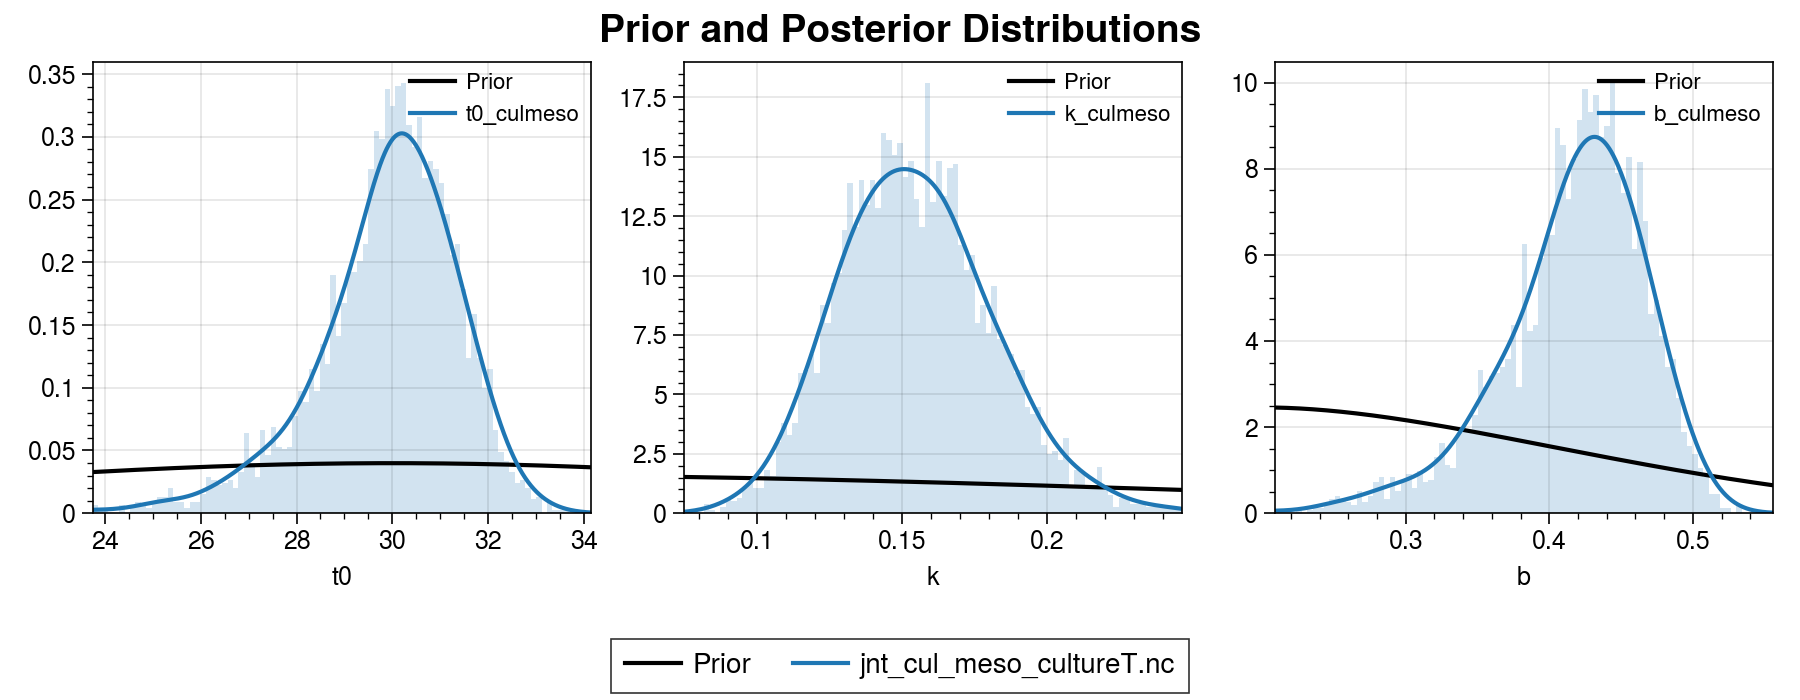

In [114]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[jnt_cul_meso_post_ds]
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 2. Joint  culture-mesocosm vs culture-mesocosm-coretop

Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b']
figure nrows, ncols: 1, 3


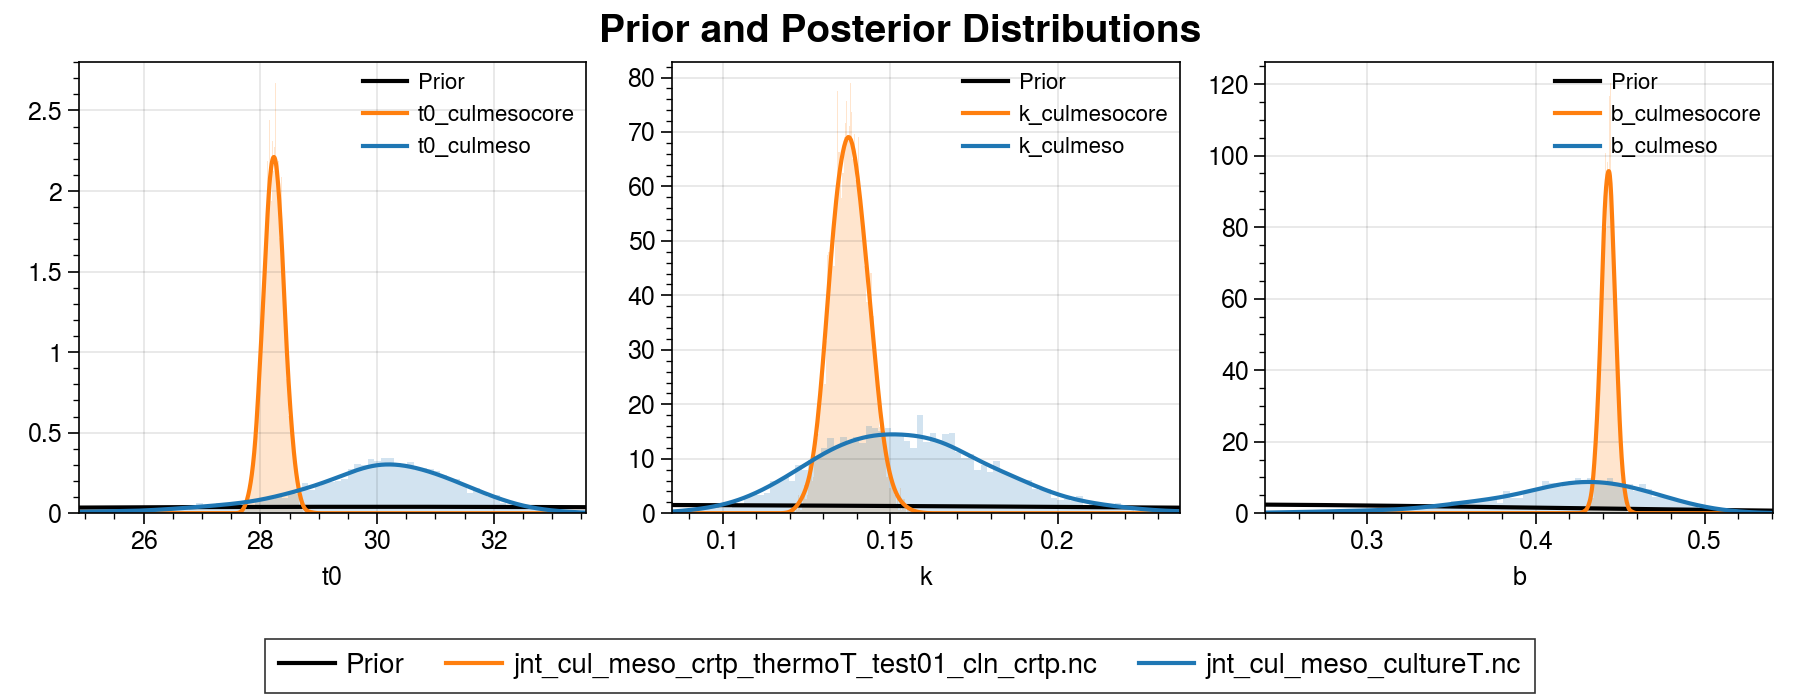

In [115]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        jnt_cul_meso_crtp_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


### 3. jnt-culture-mesocosm vs jnt-culture-mesocosm-coretop vs jnt-culmeso-hier-crtp

Grouped param names: {'t0': ['t0_culmesocore', 't0_crtp', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_crtp', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b']
figure nrows, ncols: 1, 3


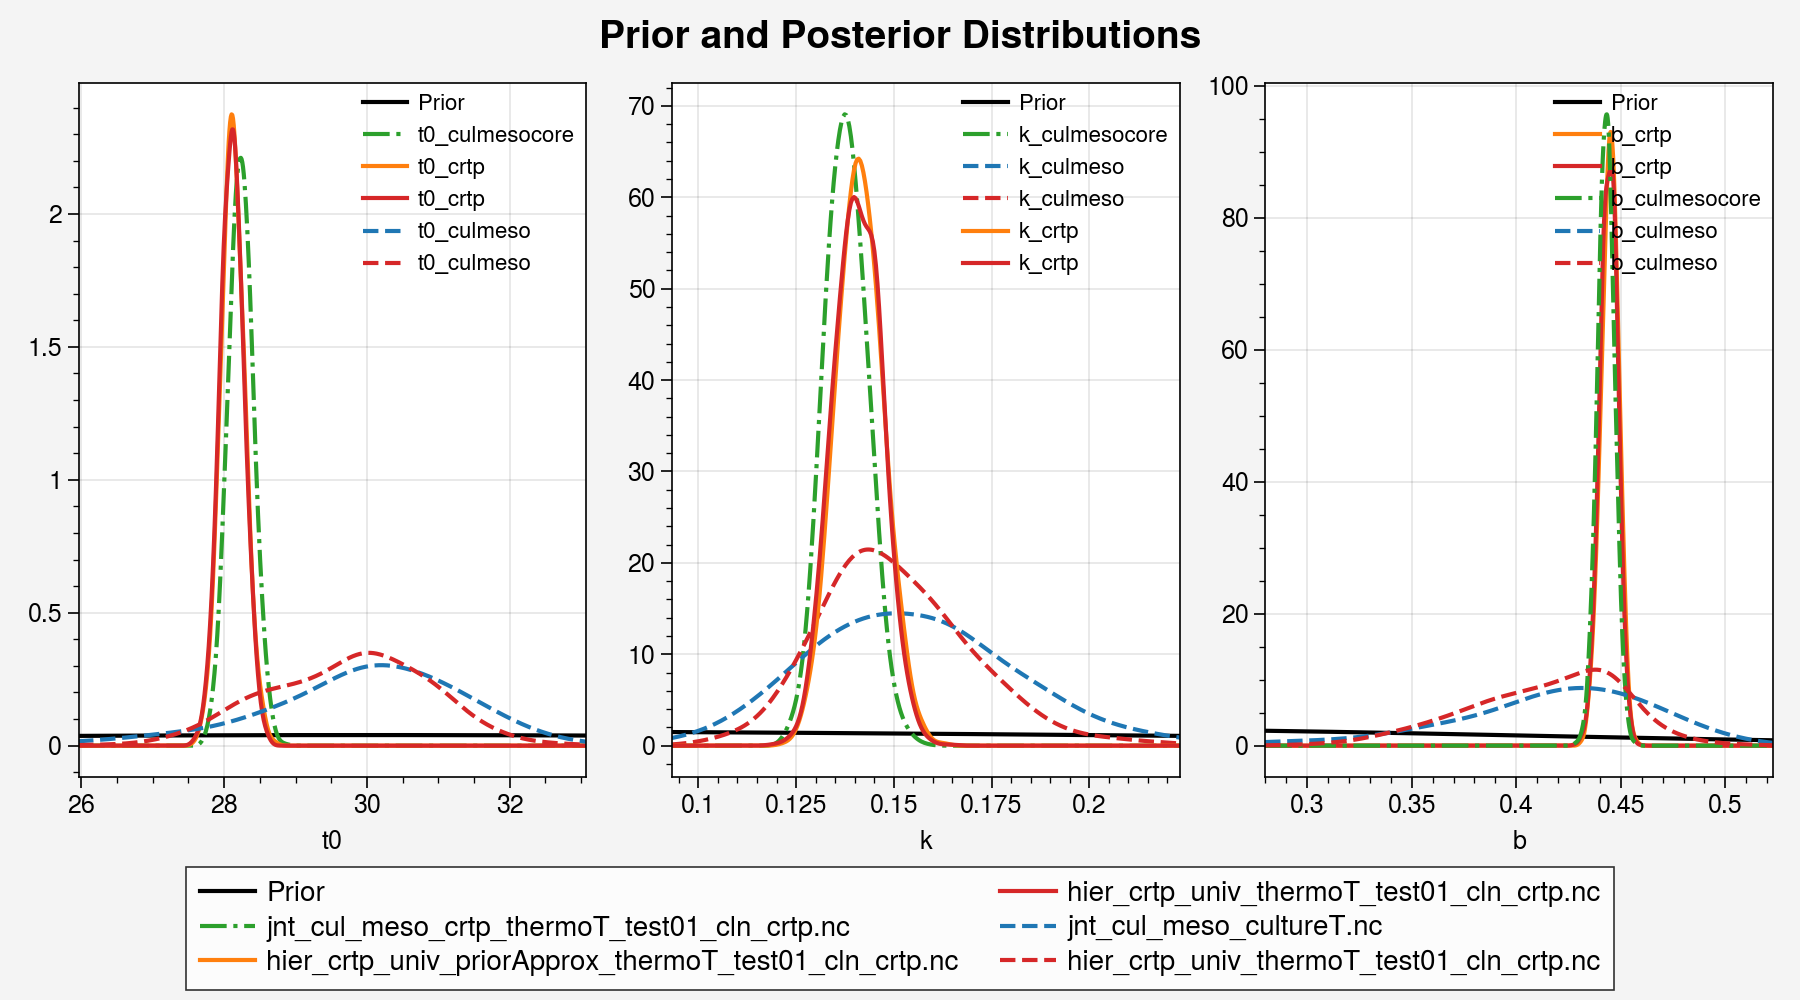

In [116]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_post_ds,
        hier_crtp_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


Grouped param names: {'t0': ['t0_culmesocore', 't0_crtp', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_crtp', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso', 'k_crtp'], 'b': ['b_crtp', 'b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b']
figure nrows, ncols: 1, 3


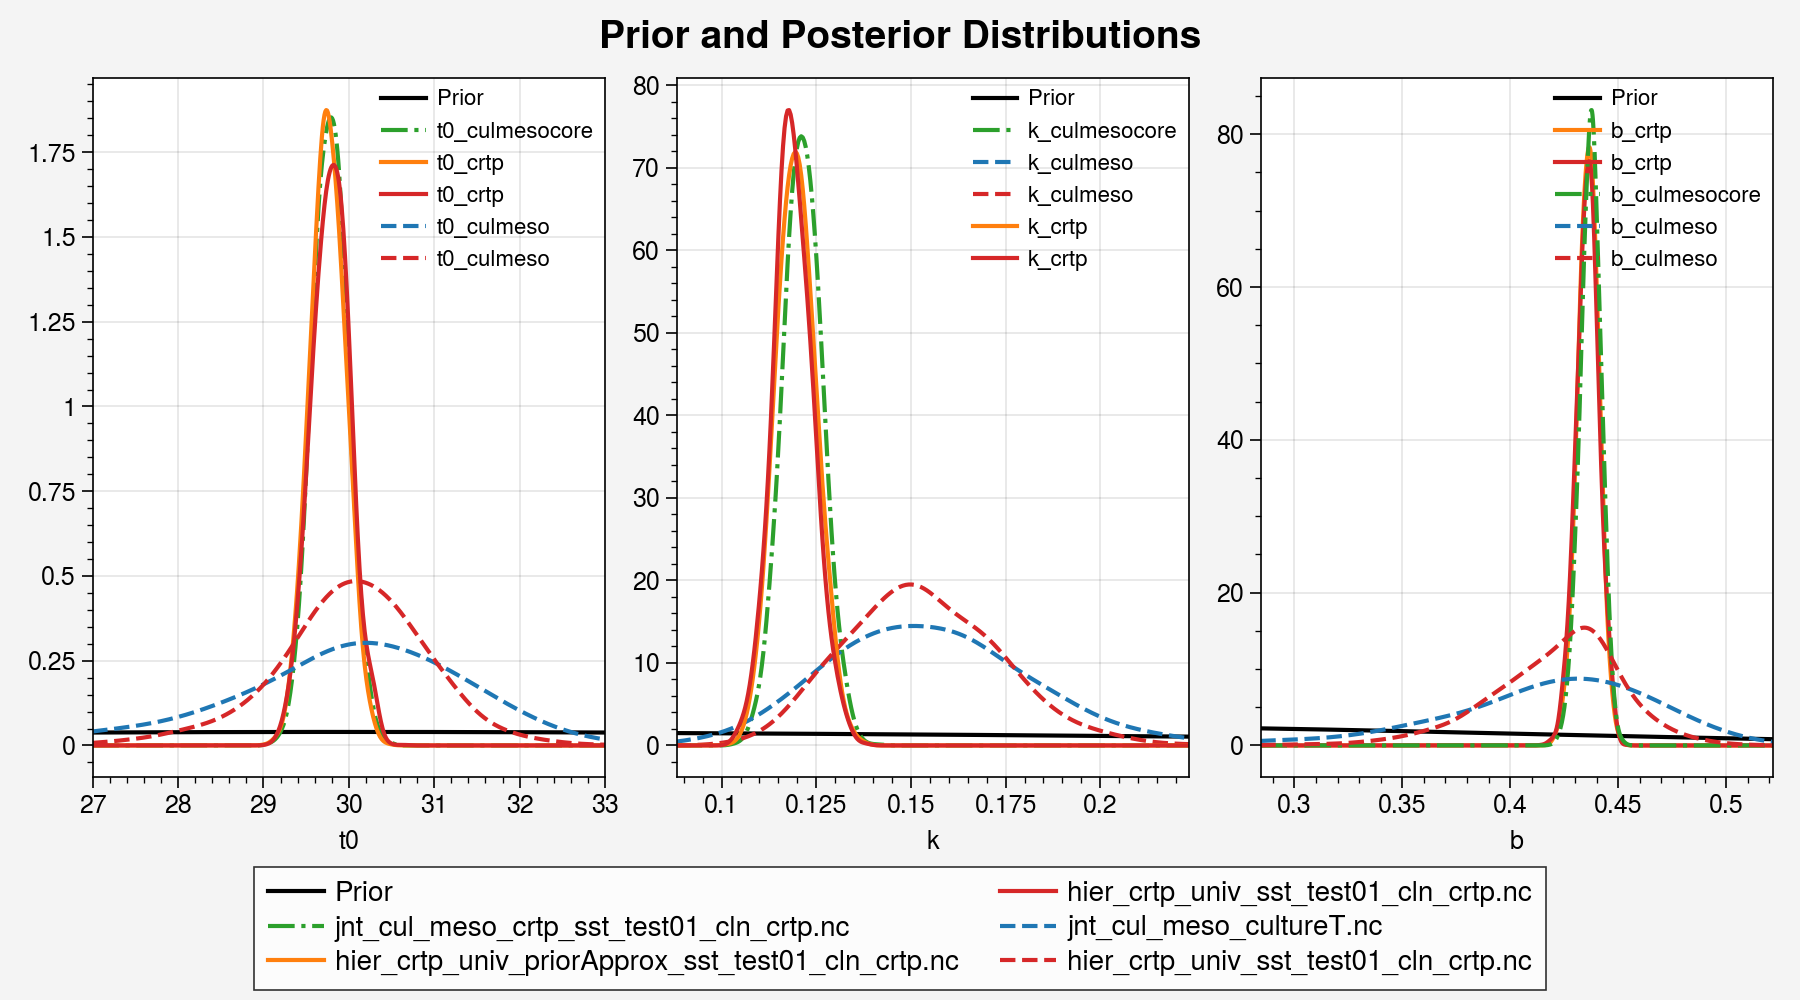

In [117]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_post_ds,
        # hier_crtp_univ_prior_logmixture_post_ds,
        hier_crtp_sst_univ_prior_approx_post_ds,
        jnt_cul_meso_crtp_sst_post_ds,
        hier_crtp_sst_post_ds
        ],
    use_linestyle_by_param=True,
    show_histogram=False,
    set_fig_height_factor=5,
    set_leg_max_ncol=2
)
axes[0][0].set_xlim(27,33)
# Later in notebook
fig.savefig("posterior_check.png", dpi=300)


Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Grouped param names: {'t0': ['t0_culmesocore', 't0_culmeso'], 'k': ['k_culmesocore', 'k_culmeso'], 'b': ['b_culmesocore', 'b_culmeso'], 'v': [], 'Q': [], 'a': [], 'beta0_gdgt23ratio': [], 'beta0_no3': []}
Param groups:  ['t0', 'k', 'b']
figure nrows, ncols: 1, 3


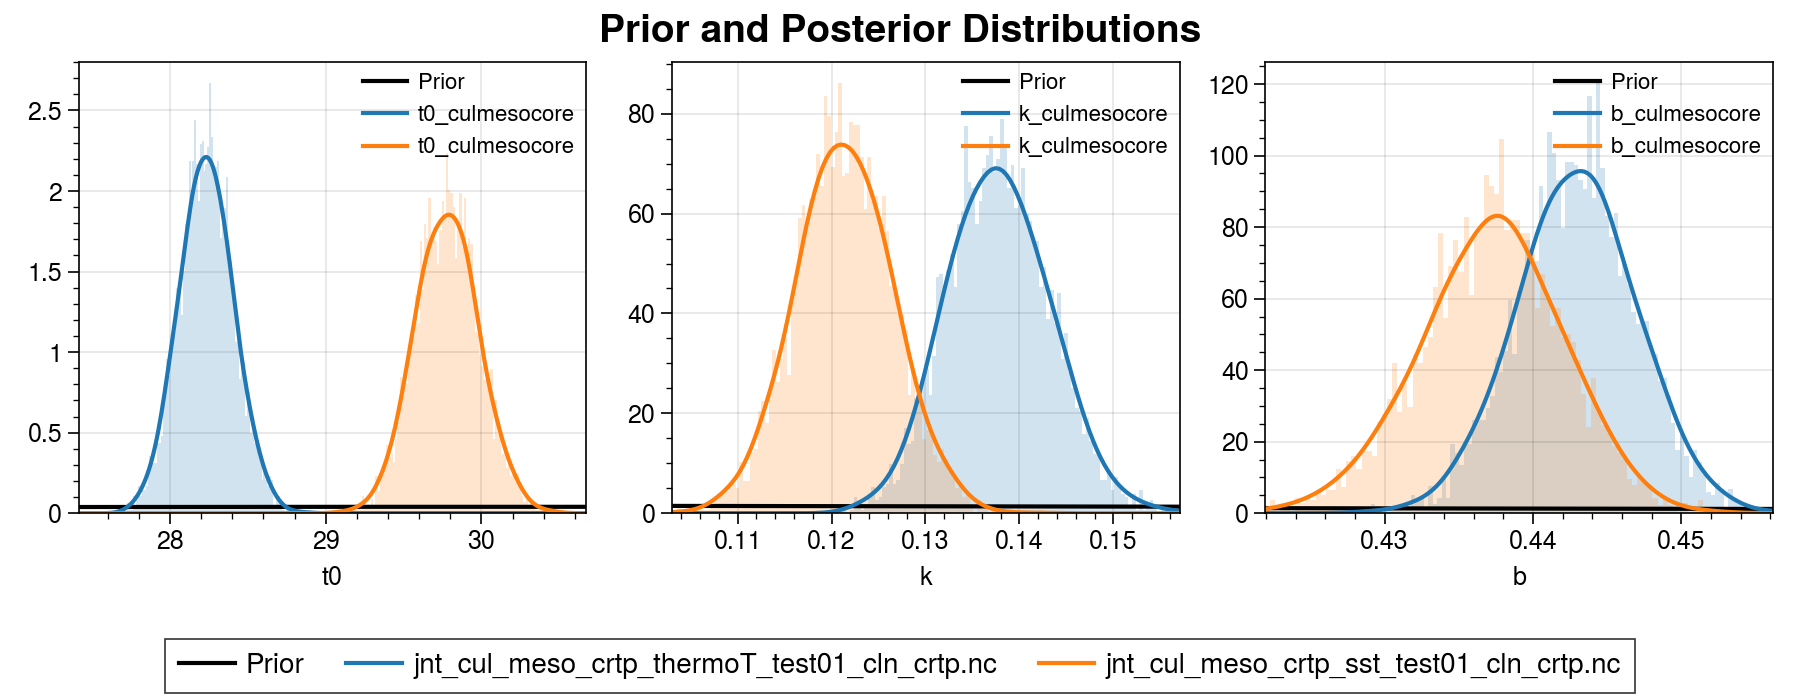

In [118]:
priors = jnt_cul_meso_post_ds.attrs["priors"]

fig, axes = plot_prior_distributions(
    priors,
    posterior_datasets=[
        jnt_cul_meso_crtp_post_ds,
        jnt_cul_meso_crtp_sst_post_ds
        ],

)

# Later in notebook
fig.savefig("posterior_check.png", dpi=300)
fig.set_facecolor("white")  # or whatever you want


In [119]:
jnt_cul_meso_post_ds.attrs.get('use_gdgt23ratio',0)

0

In [120]:
# ## load the posterior datasets
# hier_crtp_multiv_no3_post_ds = load_posterior('hier_crtp_multiv_thermoT_no3_1.0')
# hier_crtp_multiv_g23r_no3_post_ds = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.0')
# priors = hier_crtp_multiv_g23r_no3_post_ds.attrs['priors']

# fig, axes = plot_prior_distributions(
#                 priors,
#                 posterior_datasets=[
#                     jnt_cul_meso_post_ds,
#                     jnt_cul_meso_crtp_post_ds,
#                     hier_crtp_post_ds,
#                     hier_crtp_univ_prior_approx_post_ds,
#                     hier_crtp_multiv_g23r_post_ds,
#                     hier_crtp_multiv_no3_post_ds,
#                     hier_crtp_multiv_g23r_no3_post_ds,
#                     ],

#                 # focus_on_posterior=False,
#                 use_linestyle_by_param=True,
#                 show_histogram=False,
#                 set_leg_max_ncol=2,
#                 set_fig_height_factor=4.5,
#                 # suffix_include=["crtp","culmesocore"]
#                 )

# axes[1][0].set_xlim(-0.025,0)
# axes[0][0].set_xlim(25,35)

In [121]:
# coretop_df['new_deltaRI'].hist()

In [122]:
# fig,  axs = plot.subplots(ncols=2,width=10)
# plot_data = coretop_df_temp
# ax = axs[0]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['scaledRI_median']
# plot_c = plot_data['gdgt23ratio_median']
# m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
# ax.colorbar(m, loc='r')

# plot_data = coretop_df
# ax = axs[1]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['scaledRI_median']
# plot_c = plot_data['gdgt23ratio_median']
# m = ax.scatter(plot_x, plot_y, s=10, c=plot_c, mec='k', cmap='blues', levels=[0,5,10,15], label='Core-top data')
# ax.colorbar(m, loc='r')

DEBUG: use_gdgt23ratio detected
DEBUG: use_gdgt23ratio detected
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_crtp', 'k_culmeso'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_culmeso', 'a_crtp'], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Grouped param names: {'t0': ['t0_culmeso', 't0_crtp'], 'k': ['k_crtp', 'k_culmeso'], 'b': ['b_culmeso', 'b_crtp'], 'v': ['v_culmeso', 'v_crtp'], 'Q': ['Q_crtp', 'Q_culmeso'], 'a': ['a_culmeso', 'a_crtp'], 'beta0_gdgt23ratio': ['beta0_gdgt23ratio_crtp'], 'beta0_no3': ['beta0_no3_crtp']}
Param groups:  ['t0', 'k', 'b', 'v', 'Q', 'a', 'beta0_gdgt23ratio', 'beta0_no3']
figure nrows, ncols: 3, 3


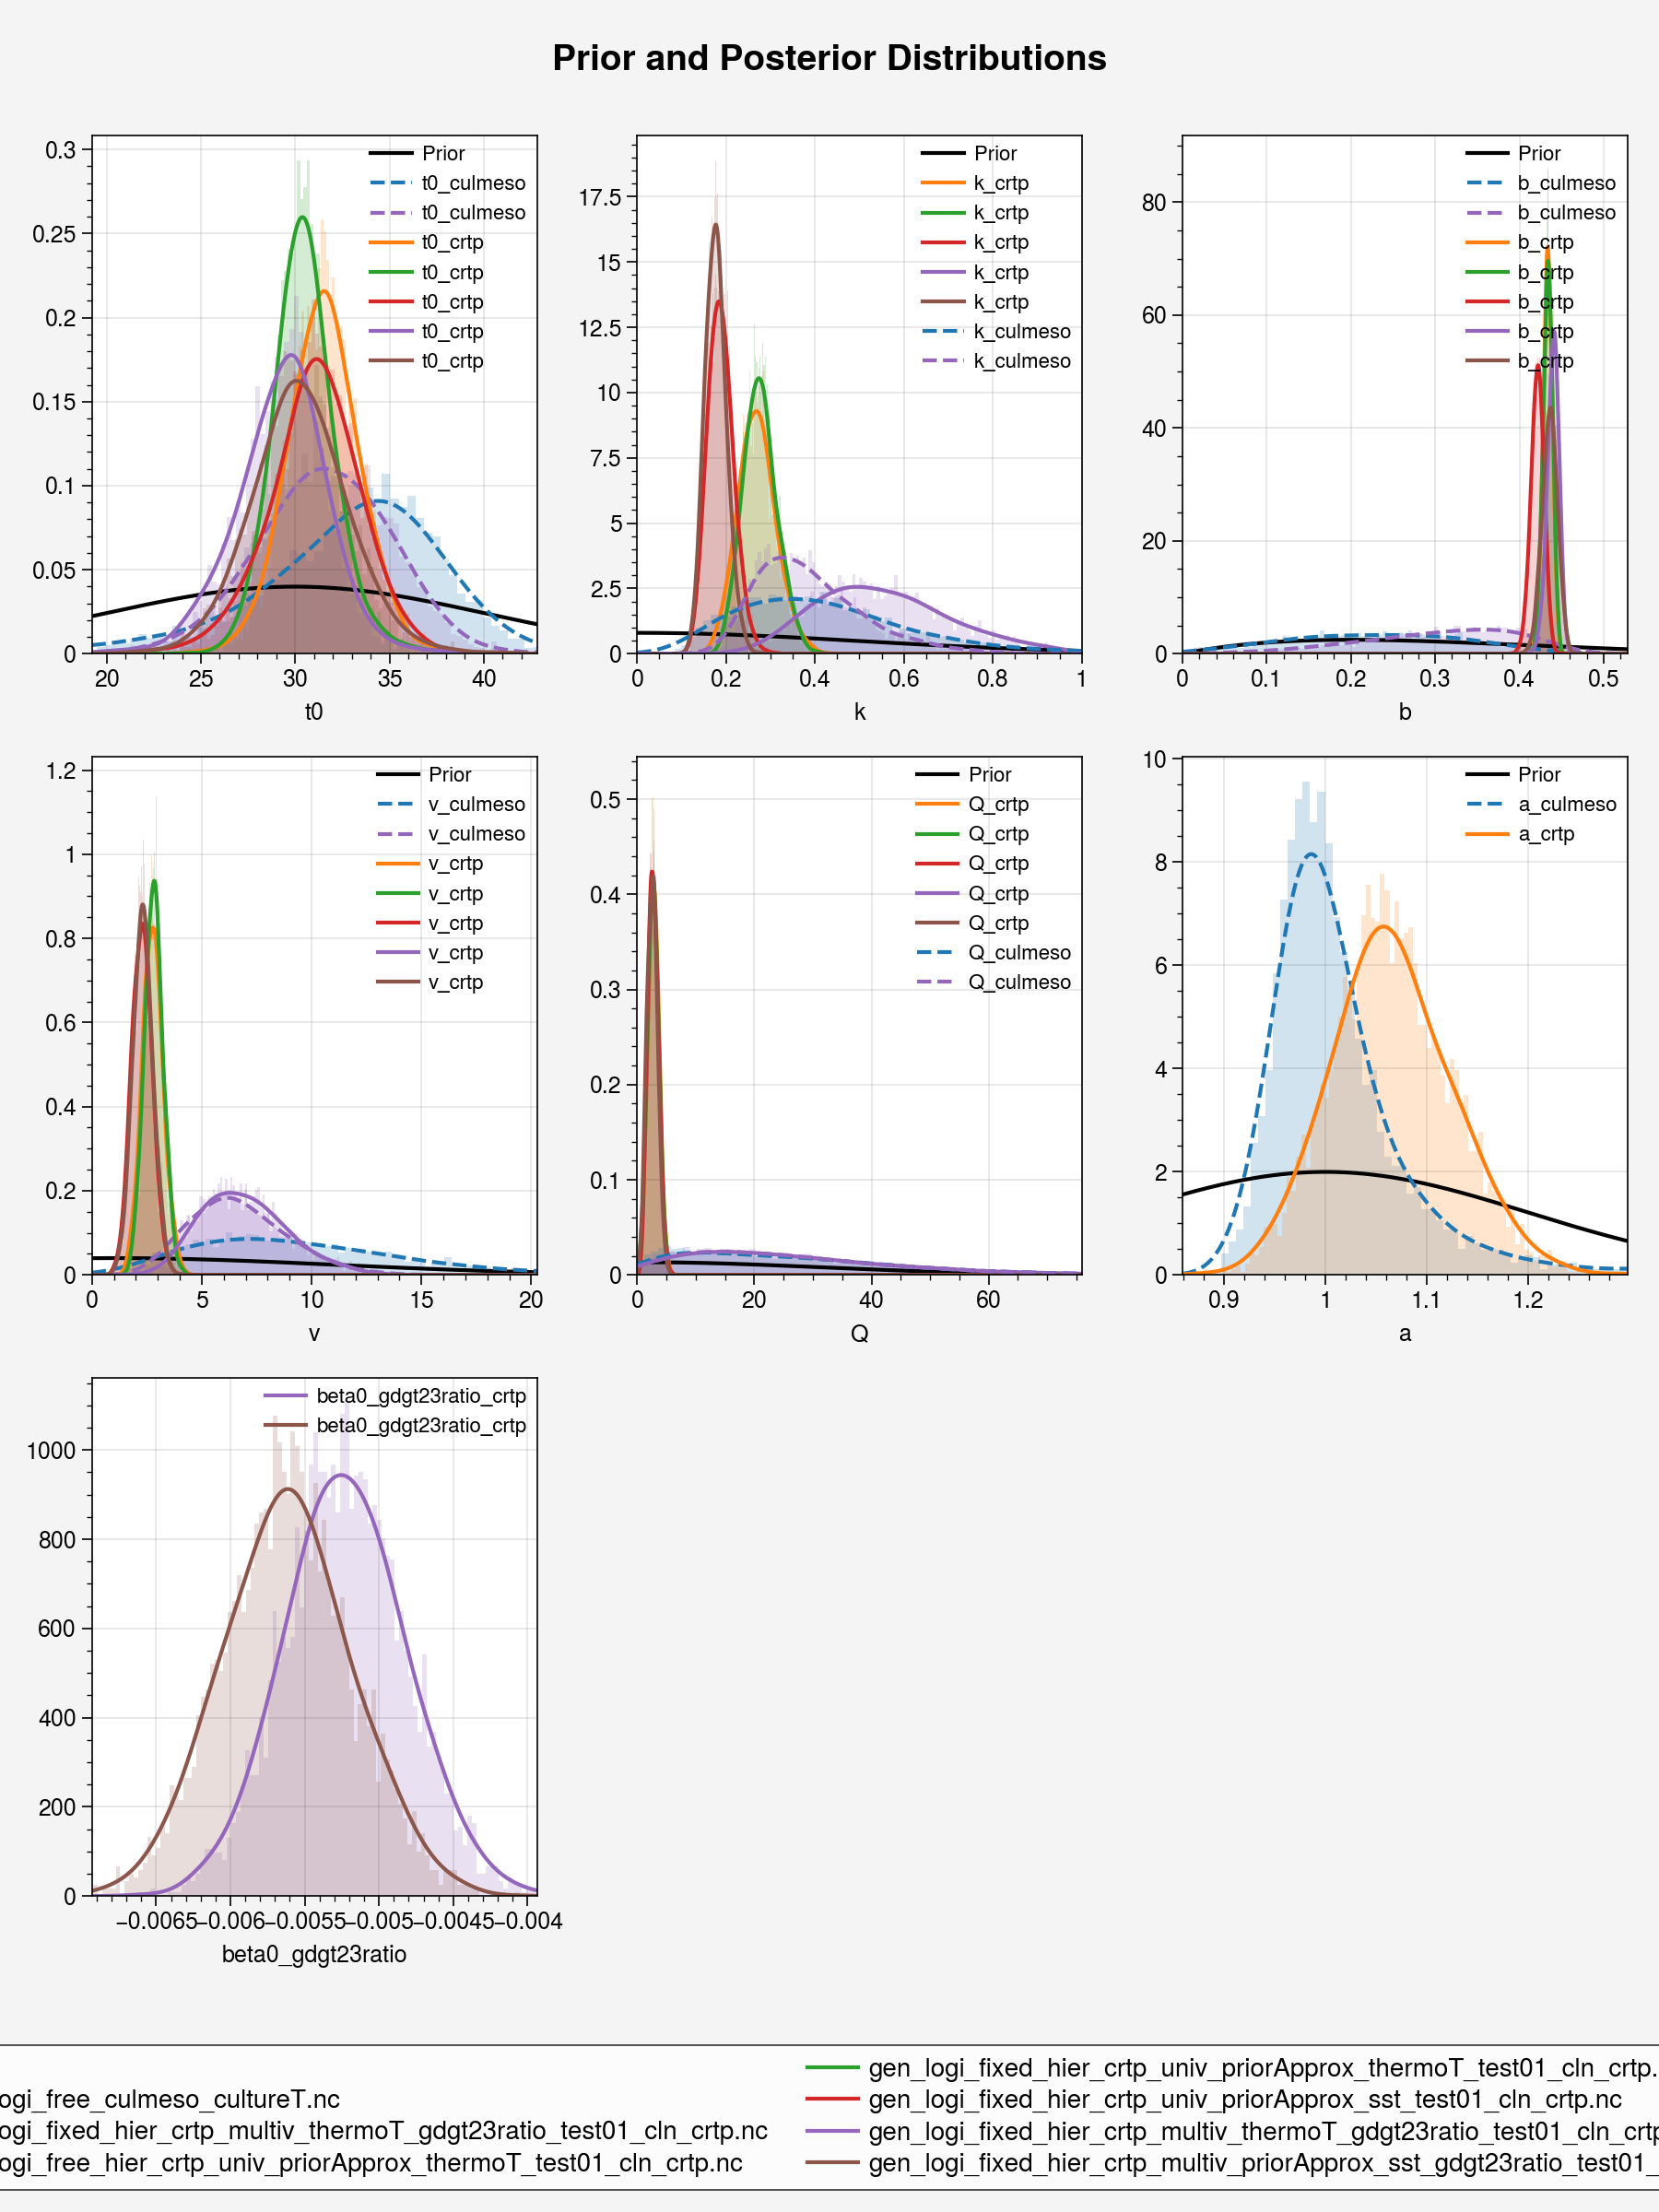

In [123]:
# Reload the dataviz_utils module to get the latest changes
import importlib
import TEXAS.dataviz_utils as dv
importlib.reload(dv)

# Test the plotting function with the updated code
fig, axes = plot_prior_distributions(
    priors_list=gen_logi_free_cul_meso_post_ds.attrs['priors'],
    posterior_datasets=[
        gen_logi_free_cul_meso_post_ds,
        gen_logi_free_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
        gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds_sst,
        gen_logi_fixed_hier_crtp_multiv_g23r_post_ds,
        gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds
        ],
    set_leg_max_ncol=2,
    set_fig_height_factor=4,
    use_linestyle_by_param=True,  # Enable different linestyles for different parameter suffixes
    # zoomin_dataset_idx=4
)

In [124]:
import importlib, TEXAS.ensemble.generator as G
import TEXAS.ensemble.detection as D
importlib.reload(D)
importlib.reload(G)


<module 'TEXAS.ensemble.generator' from '/home/micromamba/app/src/TEXAS/ensemble/generator.py'>

In [125]:
import sys, importlib

# 1) Verify you’re importing the edited code (not a site-packages shadow)
import TEXAS
print(TEXAS.__file__)  # confirm path is your working tree

import TEXAS.ensemble.detection as detection
import TEXAS.ensemble.generator as generator

# 2) Reload bottom-up (deps first)
importlib.reload(detection)
importlib.reload(generator)

# 3) Rebind any symbols you previously imported directly
from TEXAS.ensemble.detection import detect_model_and_params
from TEXAS.ensemble.generator import generate_ensemble, generate_ensemble_auto




/home/micromamba/app/src/TEXAS/__init__.py


In [126]:
import TEXAS.ensemble.detection as detection
from TEXAS.ensemble.detection import detect_model_and_params

In [127]:
post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio')
det = detect_model_and_params(post_ds)
det

{'model_function': <function TEXAS.models.multivariate.generalized_logistic_fixed_upper_multivariate(x: numpy.ndarray, t0: float = None, x0: float = None, b: float = None, k: float = None, v: float = None, Q: float = None, beta0_gdgt23ratio: float = None, gdgt23ratio: numpy.ndarray = None, beta0_no3: float = None, no3: numpy.ndarray = None, no3_cutoff: float = 50.0) -> numpy.ndarray>,
 'param_names': ['t0', 'b', 'k', 'v', 'Q', 'beta0_gdgt23ratio'],
 'suffix': 'crtp',
 'is_multivariate': True,
 'use_gdgt23ratio': True,
 'use_no3': False,
 'no3_cutoff': 0.0}

In [128]:
det.get("use_no3")

False

In [129]:
print("det.use_no3:", det.get("use_no3"))
print("det.no3_cutoff:", det.get("no3_cutoff"))
print("attrs.use_no3:", post_ds.attrs.get("use_no3"))
print("attrs.no3_cutoff:", post_ds.attrs.get("no3_cutoff"))
print("has beta0_no3 vars:", [v for v in post_ds.data_vars if v.startswith("beta0_no3")])


det.use_no3: False
det.no3_cutoff: 0.0
attrs.use_no3: None
attrs.no3_cutoff: None
has beta0_no3 vars: ['beta0_no3_crtp']


Text(0, 0.5, 'Scaled RI')

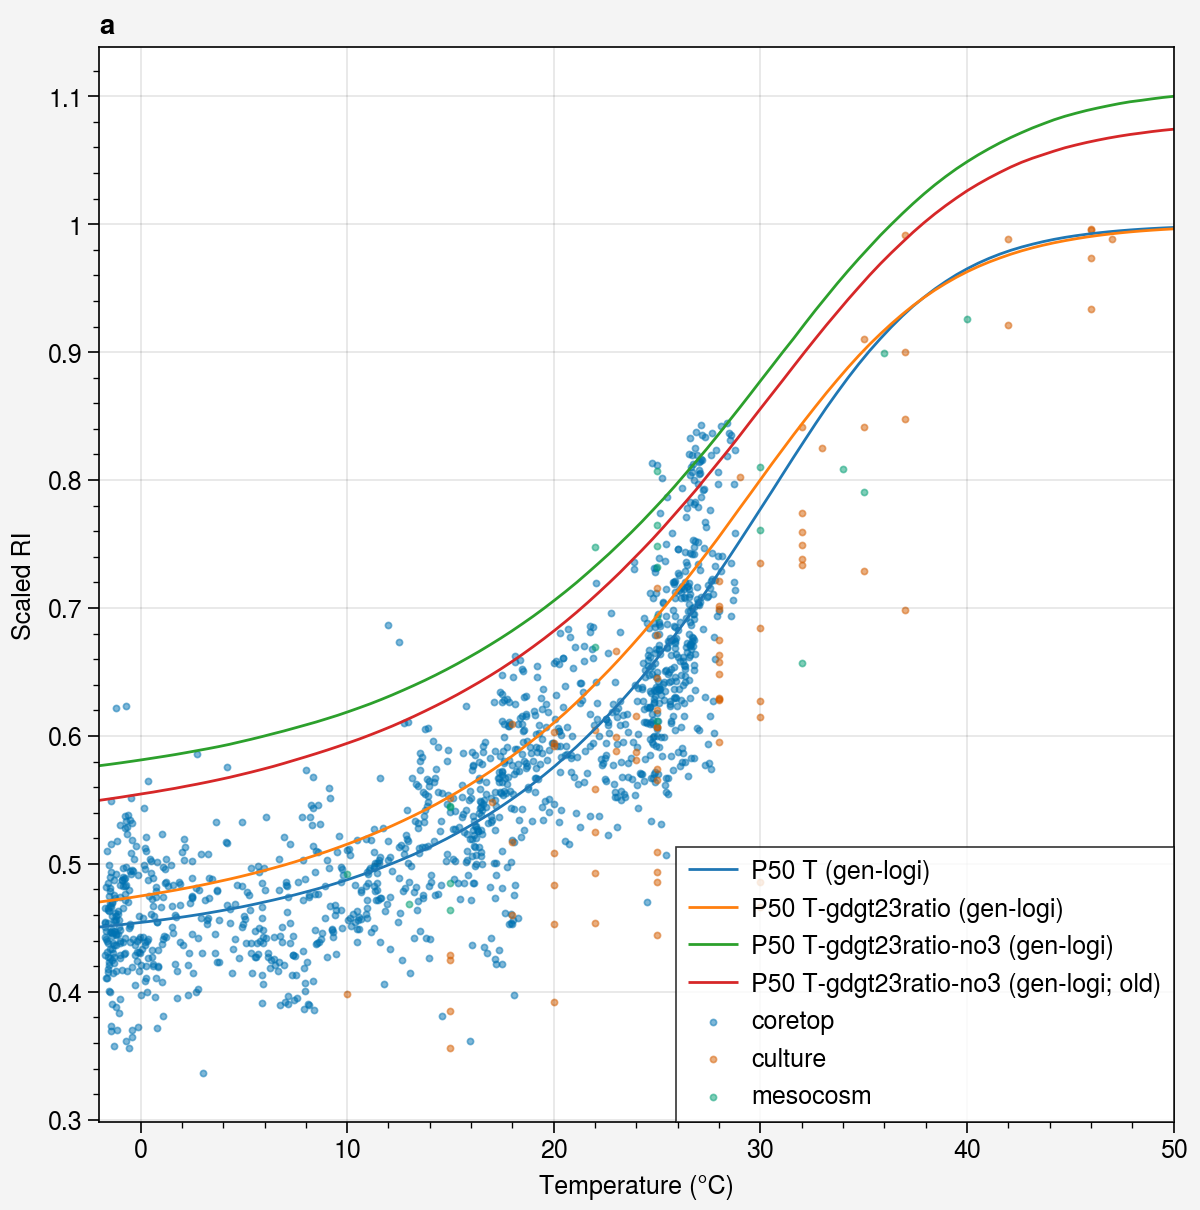

In [130]:
from TEXAS.ensemble import generate_ensemble_auto
fig, ax = plot.subplots(width=6)

grouped = combined_df.groupby('datatype')
for name, group in grouped:
    ax.scatter(group['t_sf2tc'], group['scaledRI'], 
               s=5, label=name, alpha=0.5)

gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds = load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp')
gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp')
gen_logi_multiv_gdgt23ratio_no3 = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp')
gen_logi_multiv_gdgt23ratio_no3_old = load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5')
# jnt_cul_meso_crtp_post_ds = load_posterior('gen_logi_fixed_culmesocore_thermoT')
# hier_crtp_multiv_g23r_post_ds = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_test01_cln_crtp')
# hier_crtp_multiv_gdgt23ratio_no3 = load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp')

post_ds_list = [
    # gen_logi_fixed_cul_meso_post_ds,
    gen_logi_fixed_hier_crtp_univ_prior_approx_post_ds,
    gen_logi_fixed_hier_crtp_priorApprox_multiv_g23r_post_ds,
    gen_logi_multiv_gdgt23ratio_no3,
    gen_logi_multiv_gdgt23ratio_no3_old,
    # jnt_cul_meso_post_ds,
    # jnt_cul_meso_crtp_post_ds,
    # hier_crtp_multiv_g23r_post_ds,
    # hier_crtp_multiv_gdgt23ratio_no3,
]
ds_labels = [
    'T (gen-logi)',
    'T-gdgt23ratio (gen-logi)',
    'T-gdgt23ratio-no3 (gen-logi)',
    'T-gdgt23ratio-no3 (gen-logi; old)',
    # 'T (simple-logi)',
    # 'T-gdgt23ratio (simple-logi)',
    # 'T-gdgt23ratio-no3 (simple-logi)',
]
temperature_range = np.linspace(-2, 50, 100)
gdgt23_ratio = np.full(100, 0)  # Constant GDGT-2/3 ratio
no3_vals = np.full(100, 1e-3)  # No NO3 values used
colors = plot.get_colors('tab10',N=len(post_ds_list))
for i, sel_post_ds in enumerate(post_ds_list):
    # Generate ensemble (auto-detection)
    results = generate_ensemble_auto(
        post_ds=sel_post_ds,
        x_vals=temperature_range,
        gdgt23ratio=gdgt23_ratio,  # Required for multivariate models
        no3=no3_vals,
        n_draws=500,
        seed=42,
        return_full_ensemble=True
    )
    
    # display(results)

    # Access results
    median_pred = results['p50']        # Median prediction
    lower_bound = results['p5']         # 5th percentile
    upper_bound = results['p95']        # 95th percentile

    ax.plot(temperature_range, median_pred, lw=1, 
            c=colors[i],
            label=f'P50 {ds_labels[i]}',)
    # ax.fill_between(temperature_range, lower_bound, upper_bound,
    #                 c=colors[i],alpha=0.2, 
    #                 # label=f'95% CI {sel_post_ds.attrs["filename"]}'
    #                 )

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='lr', ncols=1)

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Scaled RI')

In [131]:
results

{'x_vals': array([-2.        , -1.47474747, -0.94949495, -0.42424242,  0.1010101 ,
         0.62626263,  1.15151515,  1.67676768,  2.2020202 ,  2.72727273,
         3.25252525,  3.77777778,  4.3030303 ,  4.82828283,  5.35353535,
         5.87878788,  6.4040404 ,  6.92929293,  7.45454545,  7.97979798,
         8.50505051,  9.03030303,  9.55555556, 10.08080808, 10.60606061,
        11.13131313, 11.65656566, 12.18181818, 12.70707071, 13.23232323,
        13.75757576, 14.28282828, 14.80808081, 15.33333333, 15.85858586,
        16.38383838, 16.90909091, 17.43434343, 17.95959596, 18.48484848,
        19.01010101, 19.53535354, 20.06060606, 20.58585859, 21.11111111,
        21.63636364, 22.16161616, 22.68686869, 23.21212121, 23.73737374,
        24.26262626, 24.78787879, 25.31313131, 25.83838384, 26.36363636,
        26.88888889, 27.41414141, 27.93939394, 28.46464646, 28.98989899,
        29.51515152, 30.04040404, 30.56565657, 31.09090909, 31.61616162,
        32.14141414, 32.66666667, 33.1919